In [1]:
import os
os.environ["OMP_NUM_THREADS"] = "6"

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.lines as mlines

from sklearn.decomposition import PCA

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_samples, silhouette_score

from collections import Counter
from scipy.stats import chi2_contingency

from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()


#für Hierarchisches Clustering
from scipy.cluster.hierarchy import linkage, dendrogram
import matplotlib.pyplot as plt

In [2]:
#angepasst auf finale datei
df = pd.read_csv("naiver_ansatz/ab_ag_canonical_forms.csv")
regions = ['SEQ_H1', 'SEQ_H2', 'SEQ_L1', 'SEQ_L2', 'SEQ_L3']
antigen_labels = df["antigen_name"].tolist()

In [ ]:
def residue_percentage(sequence):
    """
    Berechnet den prozentualen Anteil jeder Aminosäure in der gegebenen Sequenz und gibt eine Liste seq_residues zurück,
    die jede Aminosäure als Tupel (residue, percentage) enthält.
    sequence: list, die eine CDR-Sequenz repäsentiert, und deren Einträge aus einem String pro Aminosäure besteht, z.B. ['A', 'R', 'N', ...]
    """
    residues = ["A", "C", "D", "E", "F", "G", "H", "I", "K", "L", "M", "N", "P", "Q", "R", "S", "T", "V", "W", "Y"]
    seq_residues = []
    for residue in residues:
        percentage = sequence.count(residue) / len(sequence)
        seq_residues.append((residue, percentage))
    return seq_residues


def show_feature_space(feature_space, CDR_region, antigen_labels):#zusätzliches Argument für color-coding: antigen
    """
    Visualisiert den Feature-Space der CDR-Sequenzen mittels PCA in 3D.
    feature_space: pd.DataFrame, der die PDB-IDs in einer Spalte "pdb" und die prozentualen Anteile der Aminosäuren in den entsprechenden CDR-Sequenzen
    in je einer Spalte pro Aminosäure enthält.
    """
    X = feature_space.drop(columns=["pdb"])
    coords = PCA(n_components=2).fit_transform(X)
    
    #### Farbzuordnung vorbereiten
    unique_antigens = sorted(list(set(antigen_labels)))
    color_map = plt.get_cmap('gist_rainbow_r', len(unique_antigens))
    color_dict = {antigen: color_map(i) for i, antigen in enumerate(unique_antigens)}
    colors = [color_dict[a] for a in antigen_labels]
   

    # Plotten der PCA-Koordinaten in 2D
    fig, (ax_scatter, ax_legend) = plt.subplots(2, 1, figsize=(10,10), gridspec_kw={'height_ratios': [4,1]})
    ax_scatter.scatter(coords[:, 0], coords[:, 1], c=colors, s=20, alpha=0.7)#zusätzliche Argumente für color-coding: c=color_codes, cmap='tab20', 
    ax_scatter.set_xlabel("PCA 1")
    ax_scatter.set_ylabel("PCA 2")
    ax_scatter.set_title(f"PCA of {CDR_region} Sequences")


    # 2. Legende als eigene Figure
    legend_fig, legend_ax = plt.subplots(figsize=(12, 12))  # Größe anpassen je nach Anzahl Antigene
    legend_ax.axis('off')  # Keine Achsen

    # Erstelle Handles
    handles = [mlines.Line2D([], [], color=color_dict[ant], marker='o', linestyle='None',
                             markersize=8, label=ant)
               for ant in unique_antigens]

    # Erzeuge Legende
    legend = legend_ax.legend(handles=handles, loc='center', ncol=1, fontsize='small')  # ncol=1 → alle untereinander

    legend_fig.tight_layout()
    plt.show()

In [ ]:
feature_spaces = {}
for region in regions: 
    fs_rows = []
    for df_row in df.itertuples():
        # Metadaten der PDB-Einträge
        pdb = df_row.pdb
        antigen_name = df_row.antigen_name
        antigen_species = df_row.antigen_species

        # AS-Häufigkeiten-Koordinaten der PDB-Einträge
        seq_as_str = getattr(df_row, region)
        seq_as_list = list(seq_as_str)
        residues_percentages = residue_percentage(seq_as_list)
        percentages = [pair[1] for pair in residues_percentages]

        # Längen-Koordinate der PDB-Einträge    
        seq_length = getattr(df_row, f"{region}_length")

        # Erstellen und Anhängen der Zeile eines PDB-Eintrages für den Feature-Space
        fs_row = [pdb] + [antigen_name] + [antigen_species] + [seq_length] + percentages
        fs_rows.append(fs_row)

    # Umwandeln des Feature-Space von einer Liste in einen DataFrame
    feature_space = pd.DataFrame(fs_rows, columns=["pdb"] + ["antigen_name"] + ["antigen_species"] + ["seq_length"] + residues)
    
    # Z-Transformation der Sequenzlängen und der AS-Häufigkeiten
    columns_to_scale = ["seq_length"] + residues
    feature_space_z = feature_space.copy()
    feature_space_z[columns_to_scale] = scaler.fit_transform(feature_space[columns_to_scale])
    feature_spaces[region] = feature_space_z


In [ ]:

for region in regions: 
    feature_space_visualize = feature_spaces[region].drop(columns=["antigen_name", "antigen_species"])
    show_feature_space(feature_space_visualize, region, antigen_labels)


#Überprüfung ob alle punkte mit gleichem antigen-name die gleiche farbe haben am bsp influenza a virus
idx_influenzaavirus = [i for i, a in enumerate(antigen_labels) if a == "influenza a virus"]
set([colors[i] for i in idx_influenzaavirus])

#alle farben pro antigen tabellarisch
for ant in set(antigen_labels):
    print(f"{ant}: {color_dict[ant]}")

In [ ]:
#elbow method 
#der erste teil ist wieder nur wdh weil der sonst die variabeln nicht findet

for region in regions:
    feature_space_elbow = feature_spaces[region].drop(columns=["antigen_name", "antigen_species"])

    #berücksichtigt nur top 10 aufgrund wie feature space definiert wurde
    X = feature_space_elbow.drop(columns=["pdb"])
    coords = PCA(n_components=2).fit_transform(X)

    #elbow method
    #inertia => Summe der quadrierten Abstände der Punkte zum jeweiligen Cluster-Zentrum => je kleiner, desto besser

    # Range of cluster numbers to try
    cluster_range = range(1, 11)  # Teste 1-10 Cluster

    # Hier Inertia-Werte speichern, [] für liste
    inertia_values = []

    # Berechne KMeans für jede Cluster-Anzahl
    for n_clusters in cluster_range:
        kmeans = KMeans(n_clusters=n_clusters, random_state=42)
        kmeans.fit(coords)  # fit passt daten an modell an => kmeans bekommt daten (coords der antikörper punkte) und initialisiert Cluster Zentren und macht dann iterative optimierung 
        # also weist punkte dem nächsten cluster zentrum zu, bei den gebildeten cluster wenn neue zentren berechnet und die punkte werden neu zugeordnet
        inertia_values.append(kmeans.inertia_)

    # Plot der Elbow-Kurve
    plt.figure(figsize=(8, 5))
    plt.plot(cluster_range, inertia_values, marker='o')
    plt.xlabel('Anzahl der Cluster (n_clusters)')
    plt.ylabel('Inertia (Summe der quadrierten Abstände)')
    plt.title(f'Elbow-Methode zur Bestimmung optimaler Clusterzahl ({region})')
    plt.xticks(cluster_range) #x achse werden dann anzhal cluster gezeigt
    plt.grid(True) #gitternetzlinien im plot
    plt.tight_layout()
    plt.show()


In [ ]:
# Clustering auf basis der PCA
#kmeans mit 3 => laut elbow method am sinnvollsten

 # Schleife über die CDR-Regionen, um den Feature-Space für jede CDR-Sequenz zu erstellen:
for region in regions:
    feature_space_kmeans = feature_spaces[region].drop(columns=["antigen_name", "antigen_species"])
    
    #berücksichtigt nur top 10 aufgrund wie feature space definiert wurde
    X = feature_space_kmeans.drop(columns=["pdb"])
    coords = PCA(n_components=2).fit_transform(X)

    # n_clusters frei wählbar
    kmeans = KMeans(n_clusters=3, random_state=42) #random state wichtig damit auch bei jeden durchlauf gleiche cluster entstehen
    cluster_labels = kmeans.fit_predict(coords) #fit predict führt clustering im 2d pca space durch

    # Plot => Cluster einfärben
    plt.figure(figsize=(10, 8))
    plt.scatter(coords[:, 0], coords[:, 1], c=cluster_labels, cmap='tab10', s=20, alpha=0.7) #c=cöuster labels färbt die punkte nach cluster; tab10 => 10 farben, alpha => tranparenz damit überlappungen sichtbar, s => punktgröße
    plt.xlabel("PCA 1")
    plt.ylabel("PCA 2")
    plt.title(f"PCA + KMeans Clustering ({region})")
    plt.colorbar(label='Cluster Label')
    plt.tight_layout()
    plt.show()

    #antigen names häufigkeiten in den clustern

    # Erzeuge Mapping: cluster_label → liste von antigen names
    # Dictionary ({} => speichert key => value paare) bauen, in dem für jedes Cluster die Liste der zugehörigen Antigen-Namen gespeichert wird
    cluster_antigen_mapping = {}

    # Gehe alle Punkte durch (alle Antikörper im PCA/Feature-Space)
    # → zip(cluster_labels, antigen_labels) gibt für jeden Punkt: cluster_label: die Cluster-Nummer (z.B. 0, 1, 2, ...) & antigen_name: der Antigen-Name dieses Antikörpers
    for cluster_label, antigen_name in zip(cluster_labels, antigen_labels):

        # Wenn dieses Cluster-Label noch nicht im Dictionary ist => leeres Array initialisieren
        if cluster_label not in cluster_antigen_mapping:
            cluster_antigen_mapping[cluster_label] = []

        # Füge den Antigen-Namen zur Liste für dieses Cluster hinzu
        cluster_antigen_mapping[cluster_label].append(antigen_name)

    #jetzt haben wir für jedes cluster eine liste mit den vorkommenden antigen names

    #für häufigkeiten:
    #header damit klar für welche cdr region
    print(f"\n Antigen Häufigkeiten pro Cluster für {region} ")
    # alle Cluster-Labels sortiert durchgehen
    for cluster_label in sorted(cluster_antigen_mapping.keys()):

        # Drucke Cluster-Header
        print(f"\nCluster {cluster_label}:")

        # wie oft jeder Antigen-Name in diesem Cluster vorkommt
        counter = Counter(cluster_antigen_mapping[cluster_label])

        # Antigen-Namen + Anzahl sortiert nach Häufigkeit aus geben
        for antigen, count in counter.most_common():
            print(f"  {antigen}: {count}x")


In [ ]:

#Proportionstest => testen, ob die Antigen-Namen systematisch unterschiedlich auf die Cluster verteilt sind

#nullhypothese (H0): Verteilung der Antigen-Namen auf die Cluster ist zufällig
#H1: Verteilung der Antigen-Namen auf die Cluster ist nicht zufällig

for region in regions:

    # Kontingenztabelle (Antigen x Cluster) erzeugen

    # automatische Zählung und erstellen von dataframe über crosstab
    contingency_table = pd.crosstab(pd.Series(antigen_labels, name='Antigen'), pd.Series(cluster_labels, name='Cluster'))

    #kontingenztabelle printen
    print(f"\n Kontingenztabelle für {region}")
    print(contingency_table)

    #chi-quadrat-test
    chi2, p, dof, expected = chi2_contingency(contingency_table)
    #chi2=maß für wie stark die beobachteten häufigkeiten von den erwarteten abweichen (je größer, desto größer abweichung)
    #p-Wert=Wahrscheinlichkeit, bei zufälliger Verteilung eine Abweichung mindestens so groß wie chi2 zu beobachten
    #dof=degrees of freedom (#zeilen-1 * #spalten-1)
    #expected=tabelle mit erwarteten häufigkeiten unter nullhypothese

    #print ergebnisse
    print(f"\n Chi-Quadrat-Test Ergebnis für {region}")
    print(f"Chi2-Wert: {chi2:.4f}") #4f für 4 nachkommSTELLEN
    print(f"p-Wert:    {p:.4e}")  # 4e für exponentielle darstellung mit 4 nachkommastellen
    print(f"Freiheitsgrade: {dof}")

    #print die expected werte zum vergleich
    expected_df = pd.DataFrame(expected, index=contingency_table.index, columns=contingency_table.columns)
    print(f"\nErwartete Häufigkeiten (unter Nullhypothese):")
    print(expected_df.round(2)) #auf 2 nachkommastellen runden

    #die tatsache dass die antigen_name häufigkeiten sehr unterschiedlich sind wird hier automatisch berücksichtigt: 
    #expected-Array wird aus den Randhäufigkeiten berechnet => randhäufigkeiten für antigen =  Summe pro Zeile => wie oft kommt jedes Antigen insgesamt im ganzen Datensatz vor?
    #randhäufigkeiten für cluster=Summe pro Spalte => wie groß ist jedes Cluster insgesamt?

    #wenn p < 0.05 => signifikant also die verteilung unterschiedet sich signifikant von zufall => N0 hypothese muss verworfen werden denn die unterschiede in der verteilung sind nicht durch zufall zu erklären


✅ TSV geschrieben: cdr_cluster_HC_length_tsvs/clusters_SEQ_H1_len7.tsv


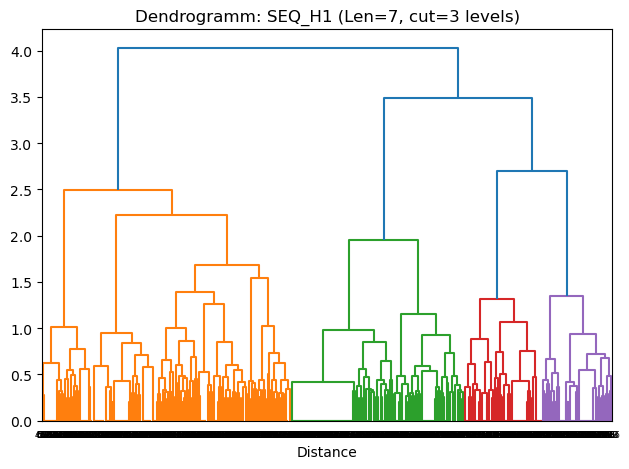


SEQ_H1, Länge 7 → 4 Subgruppen:
  Cluster 1:
    Antigen-Verteilung:
      spike glycoprotein: 77x
      spike protein s1: 53x
      neuraminidase: 12x
      hemagglutinin: 12x
      envelope glycoprotein e2: 9x
      envelope glycoprotein gp160: 8x
      fusion glycoprotein f0: 7x
      gametocyte surface protein p230: 7x
      ch848.10.17 gp120: 7x
      surface glycoprotein: 6x
      clade a/e 93th057 hiv-1 gp120 core: 6x
      leukocyte surface antigen cd47: 6x
      receptor tyrosine-protein kinase erbb-2: 6x
      envelope glycoprotein b: 5x
      envelope glycoprotein gp120: 4x
      tumor necrosis factor receptor superfamily member 5: 4x
      hemagglutinin ha1: 4x
      ch848.10.17.sosip gp120: 4x
      envelope protein: 4x
      vascular endothelial growth factor a: 4x
      arginase-1: 3x
      spike protein s2': 3x
      t-cell immunoreceptor with ig and itim domains: 3x
      spike glycoprotein,fibritin: 3x
      programmed cell death protein 1: 3x
      25 kda ookinete s

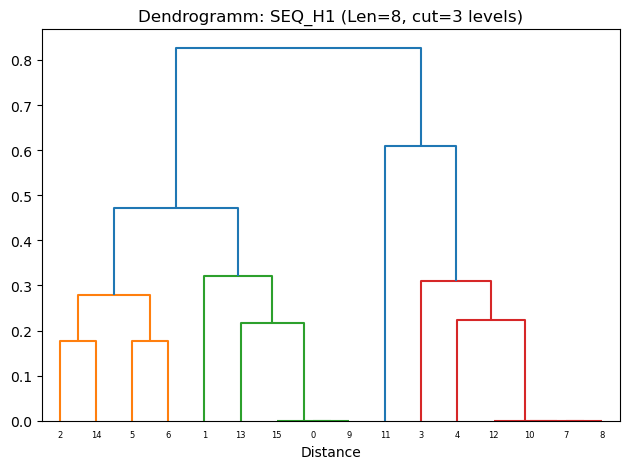


SEQ_H1, Länge 8 → 4 Subgruppen:
  Cluster 1:
    Antigen-Verteilung:
      25 kda ookinete surface antigen: 1x
      hemagglutinin: 1x
      spike protein s1: 1x
      hemagglutinin ha1 chain: 1x
    PDB_IDs:
      8ezk
      4xnm
      8dcc
      4m5z
    Sequenzen:
      GFSISSSY
      GGSISSSY
      GYSISSGY
      GYSISSNY
  Cluster 2:
    Antigen-Verteilung:
      spike protein s1: 2x
      envelope glycoprotein gp160: 1x
      glutamate receptor ionotropic, nmda 1: 1x
      genome polyprotein: 1x
    PDB_IDs:
      8x0y
      7wph
      6dfh
      8vuj
      5gzo
    Sequenzen:
      GASISSGD
      GGSISSNN
      GGSISSSN
      GGSISSSN
      GGSISSSN
  Cluster 3:
    Antigen-Verteilung:
      envelope glycoprotein gp120: 1x
    PDB_IDs:
      7kde
    Sequenzen:
      GYNIRSNN
  Cluster 4:
    Antigen-Verteilung:
      ige fc: 3x
      spike glycoprotein: 1x
      gametocyte surface protein p230: 1x
      neuraminidase: 1x
    PDB_IDs:
      7xdl
      7uvq
      7shz
      6pzy

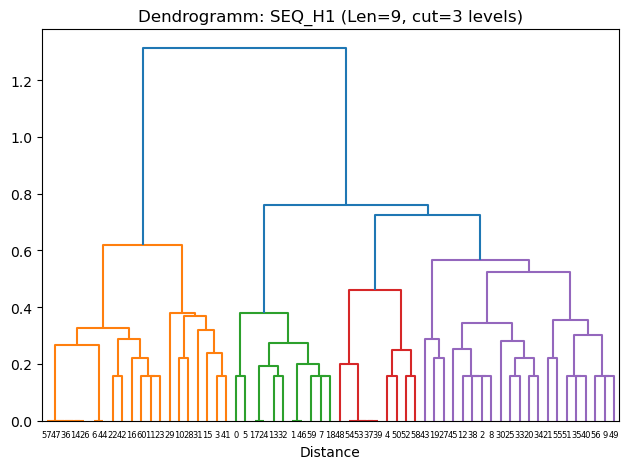


SEQ_H1, Länge 9 → 4 Subgruppen:
  Cluster 1:
    Antigen-Verteilung:
      spike glycoprotein: 11x
      spike protein s1: 4x
      hemagglutinin: 2x
      spike protein s2': 1x
      envelope glycoprotein b: 1x
      fusion glycoprotein f0: 1x
    PDB_IDs:
      7lss
      7cm4
      7d0d
      8hp9
      7xsa
      8rgz
      6urm
      7yve
      7mmo
      7ycy
      7t01
      8gdr
      7yvk
      7wrj
      8vye
      8erq
      8cw9
      8tma
      9bdf
      7wee
    Sequenzen:
      GFSLSTSGV
      GFSLSTSGV
      GFSLSTSGV
      GFSLSTSGV
      GFSLSTSGV
      GFSLSTSGM
      GFSLSTSGM
      GFSLINSGV
      GFSLSISGV
      GFSLSTPGG
      GFSLSTIGV
      GFSLSTYGV
      GFSLSTGGV
      GFSLKKNGV
      GFSVNTGGV
      GFSVTTSGV
      GFALTTSGM
      GGSFATENY
      GGFVTRNSY
      GFSLNTYGV
  Cluster 2:
    Antigen-Verteilung:
      hemagglutinin: 4x
      spike glycoprotein: 2x
      spike protein s1: 2x
      pre-glycoprotein polyprotein gp complex: 1x
      clade a/e 93t

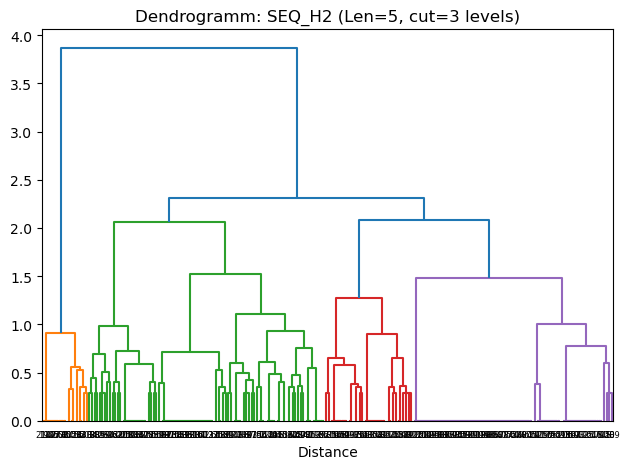


SEQ_H2, Länge 5 → 4 Subgruppen:
  Cluster 1:
    Antigen-Verteilung:
      spike glycoprotein: 10x
      spike protein s1: 3x
      fusion glycoprotein f0: 1x
      hemagglutinin: 1x
      envelope glycoprotein b: 1x
      spike protein s2': 1x
      cytotoxic t-lymphocyte protein 4: 1x
    PDB_IDs:
      7t01
      7lss
      7mmo
      7d0d
      8erq
      7xsa
      7yvk
      7yve
      8gdr
      7ycy
      8cw9
      6urm
      7cm4
      8rgz
      8vye
      8hp9
      7wee
      6xy2
    Sequenzen:
      YWDDD
      YWDDD
      YWDDD
      YWDDD
      YWDDD
      YWDDD
      YWDDD
      YWDDD
      YWDDD
      YWDDD
      DWEDN
      DWDDN
      DWDDN
      WWNND
      YWNDD
      YWDND
      YWDGD
      WYDGN
  Cluster 2:
    Antigen-Verteilung:
      spike protein s1: 18x
      spike glycoprotein: 17x
      hemagglutinin: 13x
      surface glycoprotein: 7x
      neuraminidase: 6x
      fusion glycoprotein f0: 4x
      epidermal growth factor receptor: 3x
      nucleoprotei

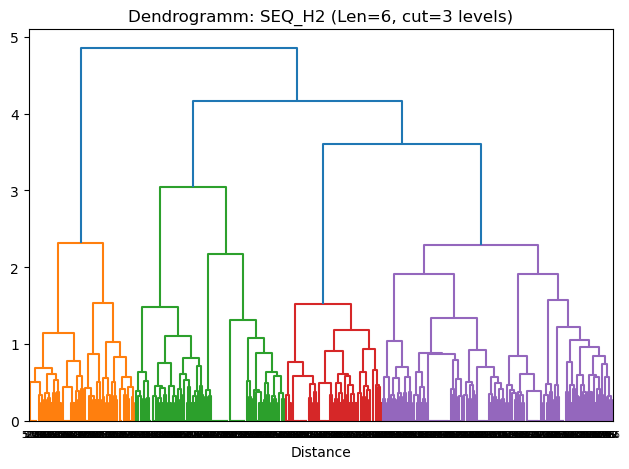


SEQ_H2, Länge 6 → 4 Subgruppen:
  Cluster 1:
    Antigen-Verteilung:
      spike glycoprotein: 28x
      spike protein s1: 15x
      neuraminidase: 7x
      ch848.10.17 gp120: 7x
      envelope glycoprotein e2: 6x
      hemagglutinin: 4x
      spike glycoprotein,fibritin: 4x
      ch848.10.17.sosip gp120: 3x
      spike protein: 2x
      envelope glycoprotein gp120: 2x
      envelope glycoprotein gp160: 2x
      e2 glycoprotein: 2x
      fusion glycoprotein f0: 2x
      envelope protein: 1x
      programmed cell death 1 ligand 1: 1x
      clade a/e 93th057 hiv-1 gp120 core: 1x
      nucleoprotein: 1x
      reticulocyte-binding protein homolog 5: 1x
      transforming growth factor beta-2: 1x
      reticulocyte binding protein 2b: 1x
      interleukin-17a: 1x
      vascular endothelial growth factor a: 1x
      hemagglutinin ha1: 1x
      gametocyte surface protein p230: 1x
      tumor necrosis factor ligand superfamily member 13b: 1x
      surface glycoprotein: 1x
      envelope glyco

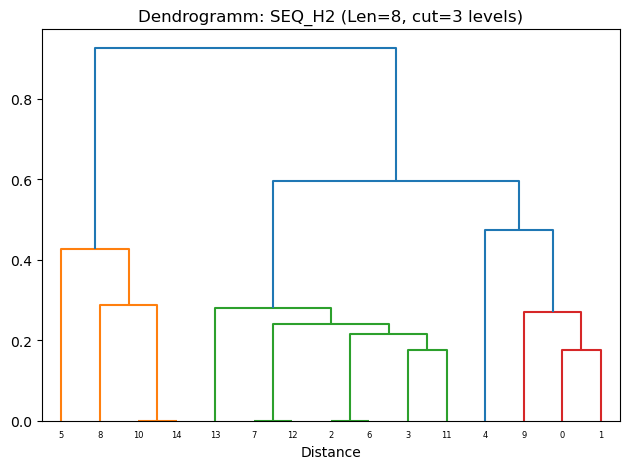


SEQ_H2, Länge 8 → 4 Subgruppen:
  Cluster 1:
    Antigen-Verteilung:
      spike glycoprotein: 2x
      spike protein s1: 1x
      envelope glycoprotein h: 1x
    PDB_IDs:
      8sdg
      7s07
      7ls9
      7kzb
    Sequenzen:
      SSNVNNDA
      RNKENSFT
      RNKANSYT
      RNKANSYT
  Cluster 2:
    Antigen-Verteilung:
      spike glycoprotein: 4x
      spike protein s1: 2x
      spike protein s2': 1x
    PDB_IDs:
      7ey5
      7x8y
      7jx3
      8suo
      8ekd
      8r8k
      7mzj
    Sequenzen:
      KSKADGQT
      KSKTDGGT
      KSKTDGGT
      KSKIDGGT
      KSKIDGGT
      KSKADGGT
      KRKSDGGT
  Cluster 3:
    Antigen-Verteilung:
      spike glycoprotein: 1x
    PDB_IDs:
      8khc
    Sequenzen:
      SSEIGGGT
  Cluster 4:
    Antigen-Verteilung:
      circumsporozoite protein: 1x
      hemagglutinin: 1x
      spike glycoprotein: 1x
    PDB_IDs:
      6o2b
      8ghk
      8jmm
    Sequenzen:
      RSKANGGR
      RTKGNSYA
      RSKAYGGT

-------------------------

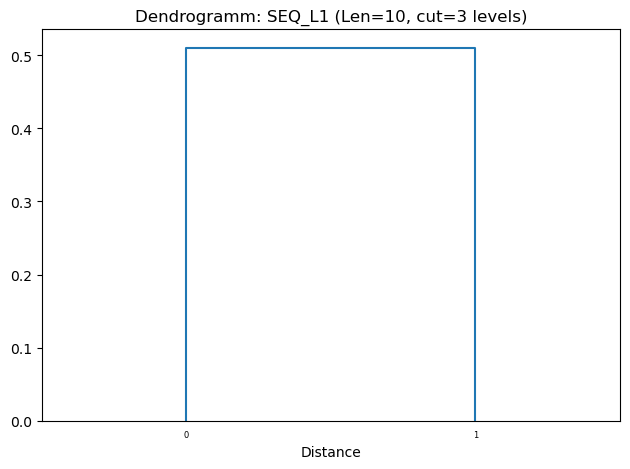


SEQ_L1, Länge 10 → 1 Subgruppen:
  Cluster 1:
    Antigen-Verteilung:
      gametocyte surface protein p230: 1x
      clade a/e 93th057 hiv-1 gp120 core: 1x
    PDB_IDs:
      7uvq
      4jb9
    Sequenzen:
      SASSSVSYMY
      RASQGGNSLN

--------------------------------------------------

✅ TSV geschrieben: cdr_cluster_HC_length_tsvs/clusters_SEQ_L1_len11.tsv


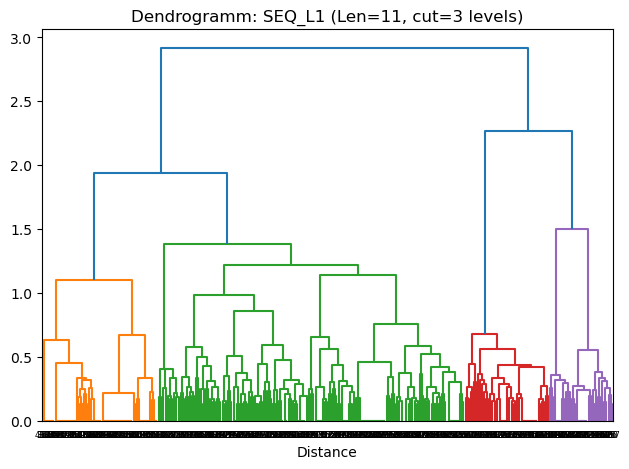


SEQ_L1, Länge 11 → 4 Subgruppen:
  Cluster 1:
    Antigen-Verteilung:
      spike glycoprotein: 23x
      spike protein s1: 19x
      hemagglutinin: 6x
      histone chaperone asf1: 4x
      programmed cell death protein 1: 3x
      neuraminidase: 3x
      gametocyte surface protein p230: 3x
      nucleoprotein: 2x
      spike protein: 2x
      circumsporozoite protein: 2x
      e2 glycoprotein: 2x
      cadmium and zinc efflux pump fief: 1x
      erythropoietin receptor: 1x
      programmed cell death 1 ligand 1: 1x
      epidermal growth factor receptor: 1x
      arginase-1: 1x
      envelope protein e: 1x
      envelope glycoprotein e2: 1x
      glutamate receptor ionotropic, nmda 1: 1x
      receptor tyrosine-protein kinase erbb-2: 1x
      tumor necrosis factor receptor superfamily member 9: 1x
      spike glycoprotein,fibritin: 1x
      leukocyte surface antigen cd47: 1x
      reticulocyte-binding protein homolog 5: 1x
      sars-cov-2 spike glycoprotein: 1x
      clade a/e 93th

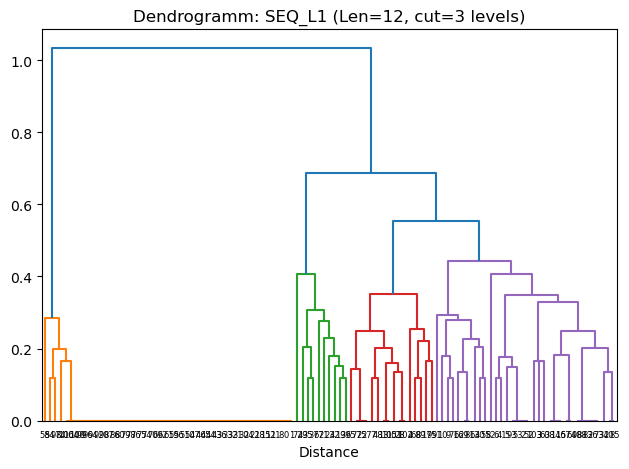


SEQ_L1, Länge 12 → 4 Subgruppen:
  Cluster 1:
    Antigen-Verteilung:
      spike protein s1: 18x
      spike glycoprotein: 17x
      surface glycoprotein: 3x
      hemagglutinin: 1x
      t-cell immunoreceptor with ig and itim domains: 1x
      sars-cov-2 spike glycoprotein: 1x
      circumsporozoite protein: 1x
      pre-glycoprotein polyprotein gp complex: 1x
      interleukin-17a: 1x
      nucleoprotein: 1x
      envelope glycoprotein e2: 1x
      spike glycoprotein,fibritin: 1x
    PDB_IDs:
      7ej4
      5ibl
      7ps1
      7coe
      7n62
      6xe1
      7mzm
      7d0c
      7lab
      7r6x
      7k8m
      7vyt
      7lrt
      7bnv
      7l2f
      7n5h
      6o25
      7n3i
      7ljr
      7l7e
      7beo
      5w1k
      7ls9
      7tcc
      7x7o
      6wir
      7orb
      7jmo
      7str
      7zbu
      8dzh
      8dlw
      8dad
      7x25
      7ul1
      7s5r
      7ru4
      7s5q
      8gsb
      8bec
      8k5g
      8w0w
      8qrf
      9fgt
      8qh0
   

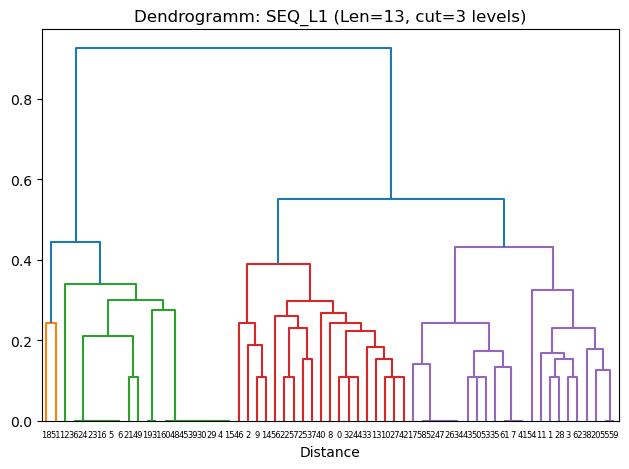


SEQ_L1, Länge 13 → 4 Subgruppen:
  Cluster 1:
    Antigen-Verteilung:
      spike protein s1: 1x
      envelope glycoprotein gp120: 1x
    PDB_IDs:
      7xsb
      7kde
    Sequenzen:
      TGSNGYIANNYVQ
      TGTSSNIENYHAF
  Cluster 2:
    Antigen-Verteilung:
      spike glycoprotein: 6x
      spike protein s1: 5x
      interleukin-17a: 2x
      hemagglutinin: 2x
      programmed cell death 1 ligand 1: 1x
      sars-cov-2 spike glycoprotein: 1x
      spike glycoprotein,fibritin,expression tag: 1x
      glutamate receptor ionotropic, nmda 1: 1x
    PDB_IDs:
      7yds
      7jva
      7ycn
      7yck
      7vzt
      8zhe
      8zho
      7u0x
      7m7b
      8dy1
      2vxs
      6ii4
      7ttx
      7jx3
      6ii8
      7wog
      7wo4
      8vuj
      8eoo
    Sequenzen:
      QSSQNVYSNNRLS
      TGSSGSIASNYVQ
      TGSSGSIASNYVQ
      TGSSGSIASNYVQ
      TGSSGSIASNYVQ
      TGSSGSIASNYVQ
      TGSSGSIASNYVQ
      TRNSGSIASNYVQ
      TGSSGNIASNYVQ
      TRSSGSLANYYVQ
      TRSS

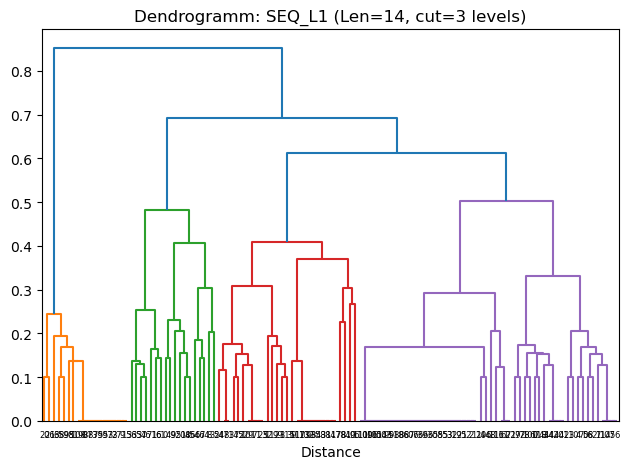


SEQ_L1, Länge 14 → 4 Subgruppen:
  Cluster 1:
    Antigen-Verteilung:
      spike protein s1: 7x
      spike glycoprotein: 6x
      fusion glycoprotein f0: 2x
      hemagglutinin: 2x
      ig epsilon chain c region: 1x
    PDB_IDs:
      8hrd
      8e2u
      8gdr
      3whe
      7m6f
      6ii9
      7wqv
      7laa
      7dx4
      5anm
      7m6h
      7cho
      7wp0
      7tjq
      8csj
      7yh6
      8zho
      8siq
    Sequenzen:
      LGGSSNIGAGYDVH
      TGSGSNLGADYGVH
      SGTSRDIGGYNYVA
      TGSSSNIGAGYAVH
      TGSSSNIGAGYYVH
      TGSSSNIGAGFDVH
      TGNSSNIGAGYDVH
      TGSSSNIGAGYDVH
      TGSSSNIGAGYDVH
      TGSSSNIGAGYDVH
      TGSSSNIGAGYDVH
      TGSSSNIGAGYDVH
      TGSSSNIGAGYDVH
      TGSSSNIGAGYDVH
      TGSSSNIGAGYDVH
      TGSSSNIGAGYDVH
      TGSSSNIGAGYDVH
      TGSSSNIGAGYDVH
  Cluster 2:
    Antigen-Verteilung:
      ch848.10.17 gp120: 4x
      spike glycoprotein: 2x
      envelope glycoprotein e: 2x
      ch848.10.17.sosip gp120: 1x
      spike pr

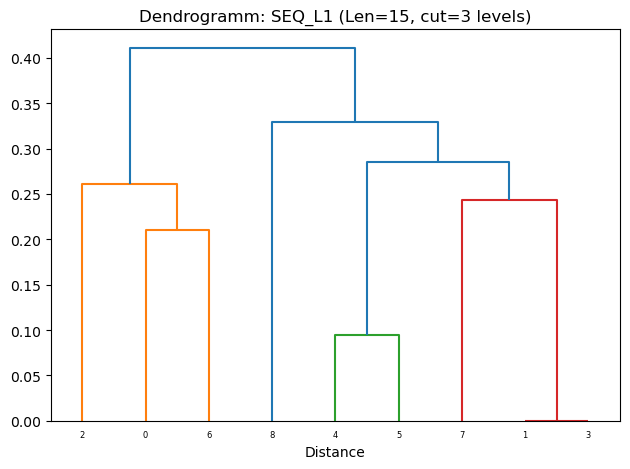


SEQ_L1, Länge 15 → 4 Subgruppen:
  Cluster 1:
    Antigen-Verteilung:
      interferon alpha-2: 1x
      spike glycoprotein: 1x
      programmed cell death protein 1: 1x
    PDB_IDs:
      4z5r
      7mw6
      5ggs
    Sequenzen:
      RASQSVSTSSYSYMH
      RASESVEYYGTSLMQ
      RASKGVSTSGYSYLH
  Cluster 2:
    Antigen-Verteilung:
      25 kda ookinete surface antigen: 1x
    PDB_IDs:
      6phc
    Sequenzen:
      RSSQSLLHNGYNYLD
  Cluster 3:
    Antigen-Verteilung:
      ige fc: 2x
    PDB_IDs:
      7shy
      7si0
    Sequenzen:
      RASQSVDYDGDSYMN
      RASQSVDSDGDSYMN
  Cluster 4:
    Antigen-Verteilung:
      spike glycoprotein: 2x
      ige fc: 1x
    PDB_IDs:
      7shz
      7mw3
      7e5s
    Sequenzen:
      RASKPVDGEGDSYLN
      RASESVDNYGISFMN
      RASESVDNYGISFMN

--------------------------------------------------

✅ TSV geschrieben: cdr_cluster_HC_length_tsvs/clusters_SEQ_L1_len16.tsv


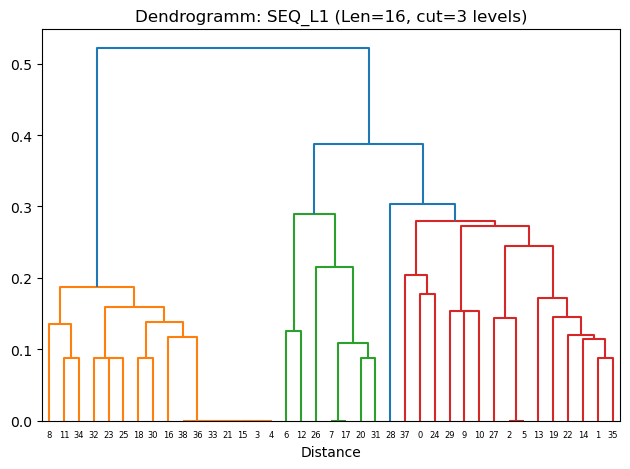


SEQ_L1, Länge 16 → 4 Subgruppen:
  Cluster 1:
    Antigen-Verteilung:
      hemagglutinin: 4x
      spike glycoprotein: 4x
      spike protein s1: 3x
      circumsporozoite protein: 1x
      envelope glycoprotein h: 1x
      spike protein: 1x
      clade a/e 93th057 hiv-1 gp120 core: 1x
      neuraminidase: 1x
    PDB_IDs:
      8tnl
      8bg1
      7rxp
      6iuv
      7e8c
      7pnm
      7t4r
      5a3i
      7wsc
      6c6z
      6oej
      7deo
      7chh
      7e9o
      8zr4
      8us0
    Sequenzen:
      NSSQSLLHSNGYAHLD
      RSSQSLLHSNGNNYLD
      RSSQSLLHSNGKNYLD
      RSSQSLLHSDGYNYLD
      RSSQSLLHSNGYLYLD
      RSSQSLLHSNGYKYLD
      RSSQSLLHTNGYNYLD
      RSSQSLLHGNGYNYLD
      RSSQSLLQSNGYNYLD
      RSSQSLLHSNGYNYLD
      RSSQSLLHSNGYNYLD
      RSSQSLLHSNGYNYLD
      RSSQSLLHSNGYNYLD
      RSSQSLLHSNGYNYLD
      RSSQSLLHSNGYNYLD
      RSSQSLLHSNGYNYLD
  Cluster 2:
    Antigen-Verteilung:
      spike glycoprotein: 3x
      reticulocyte-binding protein homolog 5: 1x


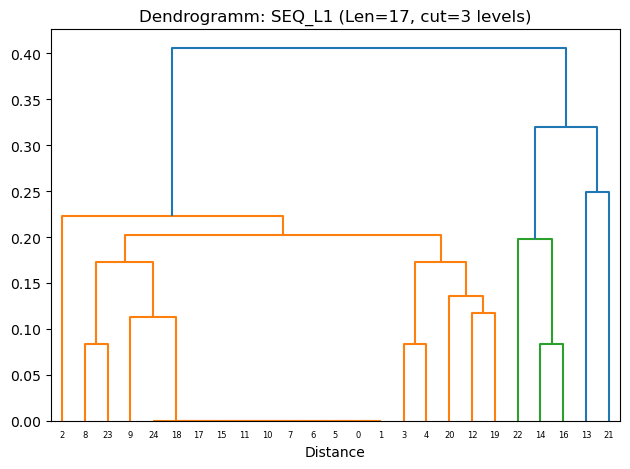


SEQ_L1, Länge 17 → 3 Subgruppen:
  Cluster 1:
    Antigen-Verteilung:
      spike glycoprotein: 8x
      spike protein s1: 5x
      surface glycoprotein: 2x
      gametocyte surface protein p230: 2x
      hemagglutinin: 2x
      spike protein s2': 1x
    PDB_IDs:
      8ekd
      8d48
      7eng
      7mzk
      7kn3
      7k9z
      7czy
      7d0d
      7ps2
      7czx
      7uvs
      7ubs
      8dnn
      8ume
      8suo
      8gf2
      8cwj
      7prz
      7fjo
      6xq4
    Sequenzen:
      KSSQSVLYAANNKNYLA
      KSSRNVLYSSNNKNYLA
      KSSQSVLYRSNNKNYLA
      KSSQSVLYSSNNKNYLG
      KSSQSVLYSSNNKNYLA
      KSSQSVLYSSNNKNYLA
      KSSQSVLYSSNNKNYLA
      KSSQSVLYSSNNKNYLA
      KSSQSVLYSSNNKNYLA
      KSSQSVLYSSNNKNYLA
      KSSQSVLYSSNNKNYLA
      KSSQSVLYSSNNKNYLA
      KSSQSVLYSSNNKNYLA
      KSSQSVLYSSNNKNYLA
      KSSQSVLYSSNNKNYLA
      KSSQSVLWSSINKNYLA
      KSSQSVLYSSINKNYLA
      KSSQSILYNSNNKTYLA
      KSSQSLLYSNNQKNYLA
      KSSQSLLYSSRNKNYLA
  Cluster 2:
    Ant

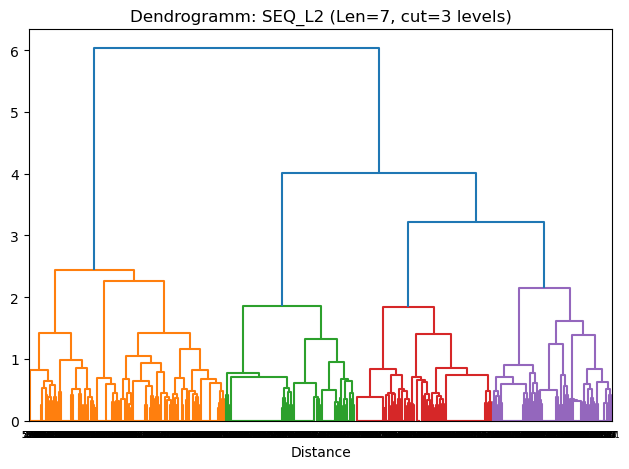


SEQ_L2, Länge 7 → 4 Subgruppen:
  Cluster 1:
    Antigen-Verteilung:
      spike glycoprotein: 70x
      spike protein s1: 59x
      hemagglutinin: 14x
      fusion glycoprotein f0: 10x
      neuraminidase: 7x
      ch848.10.17 gp120: 7x
      reticulocyte binding protein 2b: 6x
      envelope glycoprotein gp120: 6x
      envelope glycoprotein b: 5x
      surface glycoprotein: 5x
      circumsporozoite protein: 5x
      gametocyte surface protein p230: 4x
      25 kda ookinete surface antigen: 4x
      interleukin-17a: 4x
      spike glycoprotein,fibritin: 4x
      ch848.10.17.sosip gp120: 4x
      sars-cov-2 spike glycoprotein: 3x
      spike glycoprotein,fibritin,expression tag: 3x
      envelope protein: 3x
      hemagglutinin ha1 chain: 3x
      envelope glycoprotein gp160: 3x
      clade a/e 93th057 hiv-1 gp120 core: 3x
      receptor tyrosine-protein kinase erbb-2: 2x
      nucleoprotein: 2x
      reticulocyte-binding protein homolog 5: 2x
      hemagglutinin ha1: 2x
      epide

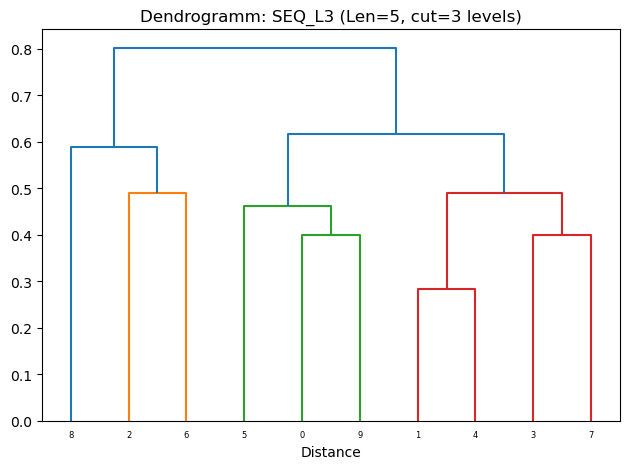


SEQ_L3, Länge 5 → 4 Subgruppen:
  Cluster 1:
    Antigen-Verteilung:
      clade a/e 93th057 hiv-1 gp120 core: 1x
    PDB_IDs:
      4jb9
    Sequenzen:
      QQFEF
  Cluster 2:
    Antigen-Verteilung:
      envelope glycoprotein gp120: 1x
      envelope glycoprotein gp160: 1x
    PDB_IDs:
      7ugq
      4ydi
    Sequenzen:
      SAFEY
      QVIES
  Cluster 3:
    Antigen-Verteilung:
      glycoprotein 120: 1x
      spike glycoprotein: 1x
      envelope glycoprotein gp160: 1x
    PDB_IDs:
      7rdw
      9cci
      4j6r
    Sequenzen:
      QHMYT
      QQYDA
      QQYET
  Cluster 4:
    Antigen-Verteilung:
      spike protein s1: 1x
      hemagglutinin: 1x
      spike glycoprotein: 1x
      clade a/e 93th057 hiv-1 gp120 core: 1x
    PDB_IDs:
      8qh0
      6e4x
      7s6j
      5te6
    Sequenzen:
      QQGVT
      QQQGT
      QQPLT
      QVLQF

--------------------------------------------------

✅ TSV geschrieben: cdr_cluster_HC_length_tsvs/clusters_SEQ_L3_len8.tsv


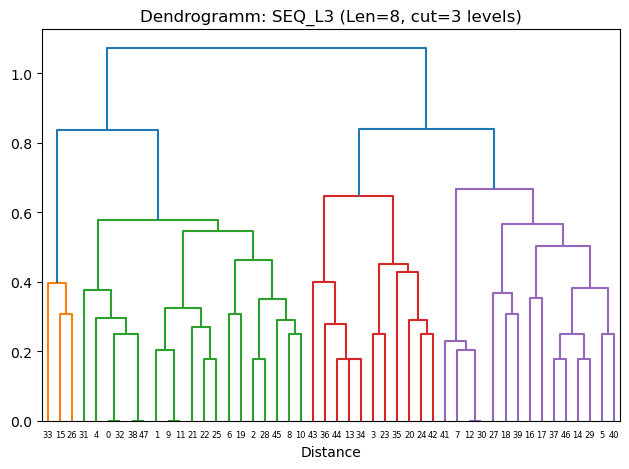


SEQ_L3, Länge 8 → 4 Subgruppen:
  Cluster 1:
    Antigen-Verteilung:
      envelope glycoprotein gp160: 1x
      fusion glycoprotein f0: 1x
      hemagglutinin ha1: 1x
    PDB_IDs:
      5t3z
      8eay
      5w08
    Sequenzen:
      YSYADGVA
      QAWDSSVV
      SSYAGSVV
  Cluster 2:
    Antigen-Verteilung:
      spike protein s1: 6x
      spike glycoprotein: 5x
      envelope glycoprotein e2: 2x
      surface glycoprotein: 1x
      envelope glycoprotein e: 1x
      spike protein s2': 1x
      reticulocyte-binding protein homolog 5: 1x
      hemagglutinin: 1x
      tumor necrosis factor receptor superfamily member 5: 1x
    PDB_IDs:
      7ljr
      8tzy
      9l6c
      6uyg
      7ps1
      7n62
      8v5q
      8suo
      8ekd
      8bbo
      7ul1
      7jmo
      8pwv
      7y6l
      8wyj
      7nx7
      5w42
      8x0y
      8yx1
    Sequenzen:
      QQYSSSRT
      QQYGGSPF
      QQYGSSPT
      QQYGSSPT
      QQYGSSPL
      QQYGSSPL
      QQSYRTLT
      QQYYSTLT
      QQYYST

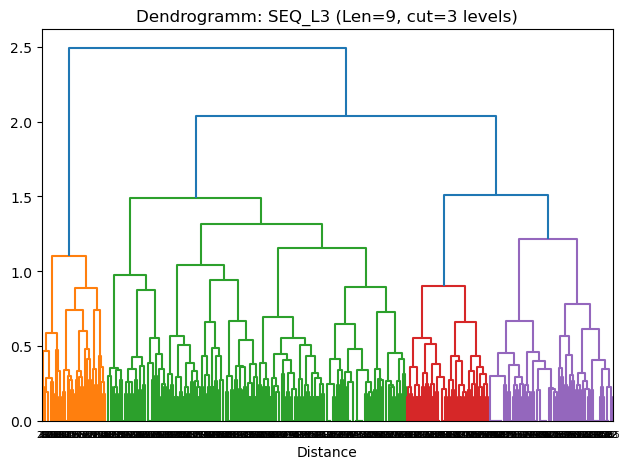


SEQ_L3, Länge 9 → 4 Subgruppen:
  Cluster 1:
    Antigen-Verteilung:
      spike glycoprotein: 17x
      spike protein s1: 7x
      hemagglutinin: 4x
      circumsporozoite protein: 3x
      spike glycoprotein,fibritin: 3x
      spike glycoprotein,fibritin,expression tag: 3x
      envelope glycoprotein b: 2x
      envelope glycoprotein e2: 2x
      genome polyprotein: 1x
      fusion glycoprotein f0: 1x
      e2 glycoprotein: 1x
      glutamate receptor ionotropic, nmda 1: 1x
      envelope glycoprotein gp160: 1x
      nucleoprotein: 1x
      erythropoietin receptor: 1x
    PDB_IDs:
      8rh0
      6urm
      8hld
      6b0s
      6kyz
      7rxl
      4xnm
      8tgv
      8dlr
      4dag
      8dwy
      8vye
      7v23
      8r1d
      7rxj
      7ttx
      7yck
      8zhe
      8eoo
      7u0x
      6ii4
      8vuj
      7jx3
      8zho
      6ii8
      8rgz
      7ycn
      7ru4
      7zr9
      8xsd
      8w0w
      8z6s
      8z6u
      8gpy
      5vn8
      8suo
      7l2c
  

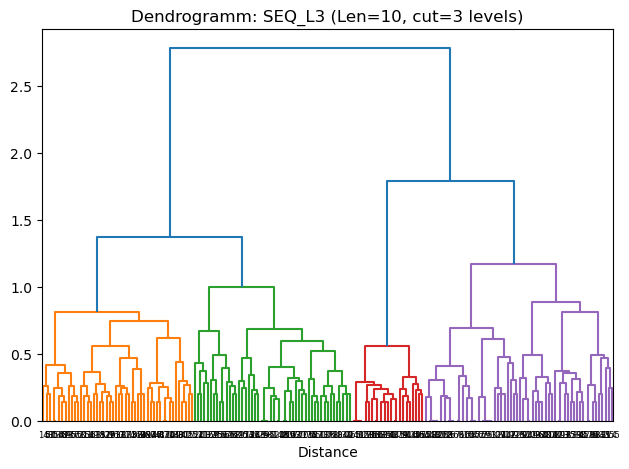


SEQ_L3, Länge 10 → 4 Subgruppen:
  Cluster 1:
    Antigen-Verteilung:
      spike glycoprotein: 11x
      spike protein s1: 9x
      neuraminidase: 7x
      gametocyte surface protein p230: 6x
      surface glycoprotein: 3x
      tyrosine-protein phosphatase non-receptor type substrate 1: 2x
      circumsporozoite protein: 2x
      leukocyte surface antigen cd47: 1x
      cadmium and zinc efflux pump fief: 1x
      25 kda ookinete surface antigen: 1x
      reticulocyte-binding protein-like protein 5: 1x
      hemagglutinin: 1x
      clade a/e 93th057 hiv-1 gp120 core: 1x
      envelope protein e: 1x
      hemagglutinin ha1: 1x
    PDB_IDs:
      8rp8
      8zr4
      7ucq
      7u9o
      7lop
      7pry
      7ui1
      7uvh
      8f6e
      7wwl
      7ua2
      7uvq
      7wnb
      7wbz
      8y4a
      8i3u
      7uow
      7neg
      8bg4
      7bz5
      6q1z
      7x91
      7b3o
      6phb
      8qkr
      6e56
      7v3l
      7czq
      8z4e
      6q20
      7qf0
      7y0w

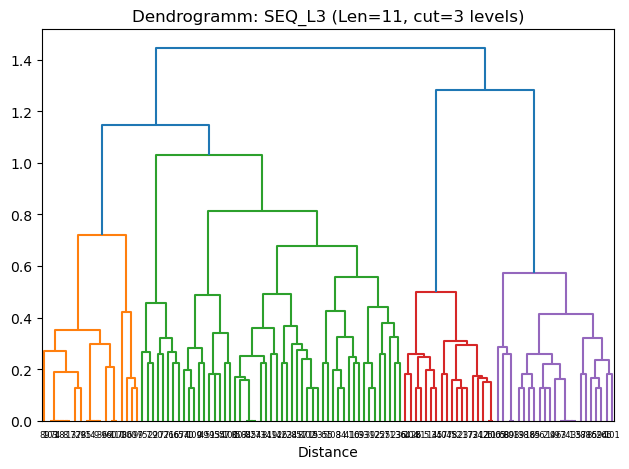


SEQ_L3, Länge 11 → 4 Subgruppen:
  Cluster 1:
    Antigen-Verteilung:
      spike glycoprotein: 10x
      spike protein s1: 6x
      hemagglutinin: 2x
      envelope glycoprotein gp120: 1x
    PDB_IDs:
      7kde
      7laa
      7m6h
      7wp0
      8y4c
      8siq
      8csj
      7m6f
      7dx4
      3whe
      8zho
      7wqv
      7cho
      6ii9
      7swp
      7wee
      7yvi
      7k8w
      7czw
    Sequenzen:
      QSYDSGLRSYI
      QSYDSSLSGWV
      QSYDSSLSGWV
      QSYDSSLSGWV
      QSYDSSLSGWV
      QSYDSSLSGWV
      QSYDSSLSGRV
      QSYDSRLSGWV
      QSYDSSLSGSV
      QSYDSSLSGSV
      QSYDSSLSGSV
      QSYDSSLSGSV
      QSCDSSLSVVV
      QSYDSSLSGVV
      QSYDSSLSGVV
      SSYTTTSTHIL
      SSYTSSSTLYV
      SSYTSSSTSVV
      SSYTSSSTLVV
  Cluster 2:
    Antigen-Verteilung:
      spike glycoprotein: 15x
      spike protein s1: 12x
      fusion glycoprotein f0: 4x
      surface glycoprotein: 2x
      envelope protein: 2x
      hemagglutinin: 2x
      glutamate recep

In [ ]:
#dendrogramm clustern
# nach längen






import csv
# Ausgabe-Ordner erstellen
os.makedirs("cdr_cluster_HC_length_tsvs", exist_ok=True)

# Parameter für Dendrogramm-Cut
levels_down = 2  # Anzahl der Ebenen für den Cut; etwa 2 = 3 Teilbäume

# Liste der 20 Standard-Aminosäuren
AA_LIST = list("ACDEFGHIKLMNPQRSTVWY")

def aa_freq_vector(seq: str) -> np.ndarray:
    """Berechnet den normierten Häufigkeitsvektor der 20 Standard-Aminosäuren."""
    counts = np.array([seq.count(aa) for aa in AA_LIST], dtype=float)
    return counts / len(seq)


# Hauptschleife: je Region und je Sequenzlänge separate Subgruppen

for region in regions:
    # Ermittle alle eindeutigen Sequenzlängen in dieser Region
    lengths = sorted(df[region].str.len().dropna().unique())

    for L in lengths:
        # Subset für die aktuelle Länge
        sub_df = df[df[region].str.len() == L].reset_index(drop=True)
        seqs = sub_df[region].tolist()
        X = np.vstack([aa_freq_vector(s) for s in seqs])

        # Hierarchisches Clustering
        Z = linkage(X, method="ward", metric="euclidean")
        threshold = Z[-levels_down, 2] if levels_down <= Z.shape[0] else 0.0

        # Dendrogrammdaten ohne Plot für Farbzuordnung
        ddata = dendrogram(
            Z,
            labels=[str(i) for i in range(len(seqs))],
            color_threshold=threshold,
            no_plot=True
        )

        # Blatt-Farben extrahieren
        leaves = ddata['leaves']
        leaf_colors = ddata['leaves_color_list']
        leaf_color_map = dict(zip(leaves, leaf_colors))

        # Eindeutige Farben in Erscheinungsreihenfolge sammeln
        unique_colors = []
        for col in leaf_colors:
            if col not in unique_colors:
                unique_colors.append(col)
        color_cluster_map = {col: idx+1 for idx, col in enumerate(unique_colors)}

        # TSV-Einträge sammeln
        entries = []
        for col in unique_colors:
            cid = color_cluster_map[col]
            leaves_in_cluster = [leaf for leaf, c in leaf_color_map.items() if c == col]
            for leaf_idx in leaves_in_cluster:
                pdb_id = sub_df.iloc[leaf_idx]['PDB_ID']
                entries.append((pdb_id, region, L, cid))

        # Schreibe TSV für Region und Länge
        tsv_file = f"cdr_cluster_HC_length_tsvs/clusters_{region}_len{L}.tsv"
        with open(tsv_file, 'w', newline='') as f:
            writer = csv.writer(f, delimiter='\t')
            writer.writerow(["PDB_ID", "CDR", "Length", "Cluster_Label"])
            writer.writerows(entries)
        print(f"✅ TSV geschrieben: {tsv_file}")

        # Plot Dendrogramm        plt.figure(figsize=(8, 6))
        dendrogram(
            Z,
            labels=[str(i) for i in range(len(seqs))],
            color_threshold=threshold,
            leaf_rotation=0,
            leaf_font_size=6
        )
        plt.title(f"Dendrogramm: {region} (Len={L}, cut={levels_down} levels)")
        plt.xlabel("Distance")
        plt.tight_layout()
        plt.show()

        # Konsolenausgabe der Cluster-Inhalte
        print(f"\n{region}, Länge {L} → {len(unique_colors)} Subgruppen:")
        for col in unique_colors:
            cid = color_cluster_map[col]
            leaves_in_cluster = [leaf for leaf, c in leaf_color_map.items() if c == col]
            antigens = sub_df.loc[leaves_in_cluster, 'antigen_name']
            pdbs = sub_df.loc[leaves_in_cluster, 'PDB_ID']
            seq_list = sub_df.loc[leaves_in_cluster, region]

            counts = Counter(antigens)
            print(f"  Cluster {cid}:")
            print("    Antigen-Verteilung:")
            for ag, cnt in counts.most_common():
                print(f"      {ag}: {cnt}x")
            print("    PDB_IDs:")
            for p in pdbs:
                print(f"      {p}")
            print("    Sequenzen:")
            for s in seq_list:
                print(f"      {s}")
        print("\n" + "-"*50 + "\n")

In [9]:
import pandas as pd
import glob
import os

# Verzeichnis mit deinen TSV-Dateien
path = "/Users/paulinekipp/Documents/GitHub/group04-team04/cdr_cluster_HC_length_tsvs"
all_files = glob.glob(os.path.join(path, "*.tsv"))
# Wir gehen die einzelnen CDRs durch
cdrs = ["H1", "H2", "L1", "L2", "L3"]

for cdr in cdrs:
    # Dateien für die aktuelle CDR sammeln
    pattern = os.path.join(path, f"*{cdr}*.tsv")
    all_files = glob.glob(pattern)

    print(f"\nFür CDR {cdr} wurden gefunden: {len(all_files)} Dateien")
    
    dfs = []
    for file in all_files:
        print(f" - {file}")
        df = pd.read_csv(file, sep="\t")
        # Cluster-Spalte bauen
        df["cluster"] = df["CDR"].astype(str) + "_" + df["Length"].astype(str) + "_" + df["Cluster_Label"].astype(str)
        # Nur PDB_ID und cluster behalten
        df = df[["PDB_ID", "cluster"]]
        dfs.append(df)

    if dfs:
        merged_df = pd.concat(dfs, ignore_index=True)
        # Speichern
        output_file = f"merged_clusters_{cdr}.csv"
        merged_df.to_csv(output_file, index=False)
        print(f"=> Datei gespeichert: {output_file} mit {len(merged_df)} Zeilen")
    else:
        print(f"=> Keine Dateien für CDR {cdr} gefunden.")



Für CDR H1 wurden gefunden: 3 Dateien
 - /Users/paulinekipp/Documents/GitHub/group04-team04/cdr_cluster_HC_length_tsvs/clusters_SEQ_H1_len9.tsv
 - /Users/paulinekipp/Documents/GitHub/group04-team04/cdr_cluster_HC_length_tsvs/clusters_SEQ_H1_len8.tsv
 - /Users/paulinekipp/Documents/GitHub/group04-team04/cdr_cluster_HC_length_tsvs/clusters_SEQ_H1_len7.tsv
=> Datei gespeichert: merged_clusters_H1.csv mit 777 Zeilen

Für CDR H2 wurden gefunden: 3 Dateien
 - /Users/paulinekipp/Documents/GitHub/group04-team04/cdr_cluster_HC_length_tsvs/clusters_SEQ_H2_len6.tsv
 - /Users/paulinekipp/Documents/GitHub/group04-team04/cdr_cluster_HC_length_tsvs/clusters_SEQ_H2_len5.tsv
 - /Users/paulinekipp/Documents/GitHub/group04-team04/cdr_cluster_HC_length_tsvs/clusters_SEQ_H2_len8.tsv
=> Datei gespeichert: merged_clusters_H2.csv mit 777 Zeilen

Für CDR L1 wurden gefunden: 8 Dateien
 - /Users/paulinekipp/Documents/GitHub/group04-team04/cdr_cluster_HC_length_tsvs/clusters_SEQ_L1_len13.tsv
 - /Users/paulinekip

In [ ]:
import pandas as pd

# Lade die Originaldatei
df = pd.read_csv("naiver_ansatz/ab_ag_canonical_forms.csv")  # oder .tsv falls notwendig

# CDR-Regionen definieren
cdrs = ["H1", "H2", "L1", "L2", "L3"]

# Mapping zwischen CF-Spalten und neuen HC-Spalten
cf_columns = [f"CF_{cdr}" for cdr in cdrs]
hc_columns = [f"HC_{cdr}" for cdr in cdrs]

# Lege neue HC-Spalten mit leeren Werten an
for hc_col in hc_columns:
    df[hc_col] = None

# Für jede CDR-Typ die passende Clusterdatei einlesen und zuordnen
for cdr in cdrs:
    cluster_df = pd.read_csv(f"cdr_cluster_HC_tsvs/clusters_SEQ_{cdr}.tsv", sep="\t")
    

    # Clusterdatei: PDB_ID | CDR | Cluster_Label
    cluster_map = dict(zip(cluster_df["PDB_ID"], cluster_df["Cluster_Label"]))

    # Neue Spalte füllen auf Basis der PDB_ID-Zuordnung
    df[f"HC_{cdr}"] = df["PDB_ID"].map(cluster_map)

# Speichern als neue Datei
df.to_csv("ab_ag_hierarchical_canonical_forms_nach_länge.csv", index=False)
print("Neue Datei erfolgreich erstellt: ab_ag_hierarchical_canonical_forms_nach_länge.csv")

In [10]:
import pandas as pd

# Lade die Originaldatei
df = pd.read_csv("naiver_ansatz/ab_ag_canonical_forms.csv")  # ggf. anpassen auf .tsv

# CDR-Regionen definieren
cdrs = ["H1", "H2", "L1", "L2", "L3"]

# Lege neue Spalten an
for cdr in cdrs:
    df[f"HC_{cdr}"] = None

# Für jede CDR die passende Clusterdatei einlesen und zuordnen
for cdr in cdrs:
    # Lade die gemergte Cluster-Datei
    cluster_df = pd.read_csv(f"merged_clusters_{cdr}.csv")
    
    # Cluster-Datei: PDB_ID | cluster
    cluster_map = dict(zip(cluster_df["PDB_ID"], cluster_df["cluster"]))
    
    # Neue Spalte füllen auf Basis von PDB_ID
    df[f"HC_{cdr}"] = df["PDB_ID"].map(cluster_map)

# Speichern
df.to_csv("ab_ag_hierarchical_canonical_forms_nach_länge.csv", index=False)
print("✅ Neue Datei erfolgreich erstellt: ab_ag_hierarchical_canonical_forms_nach_länge.csv")


✅ Neue Datei erfolgreich erstellt: ab_ag_hierarchical_canonical_forms_nach_länge.csv


3
✅ TSV geschrieben: cdr_cluster_pre_decided_HC_length_tsvs/clusters_SEQ_H1_len7.tsv


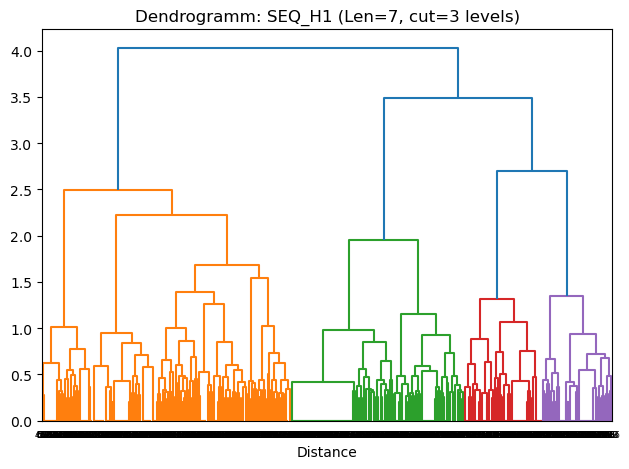


SEQ_H1, Länge 7 → 4 Subgruppen:
  Cluster 1:
    Antigen-Verteilung:
      spike glycoprotein: 77x
      spike protein s1: 53x
      neuraminidase: 12x
      hemagglutinin: 12x
      envelope glycoprotein e2: 9x
      envelope glycoprotein gp160: 8x
      fusion glycoprotein f0: 7x
      gametocyte surface protein p230: 7x
      ch848.10.17 gp120: 7x
      surface glycoprotein: 6x
      clade a/e 93th057 hiv-1 gp120 core: 6x
      leukocyte surface antigen cd47: 6x
      receptor tyrosine-protein kinase erbb-2: 6x
      envelope glycoprotein b: 5x
      envelope glycoprotein gp120: 4x
      tumor necrosis factor receptor superfamily member 5: 4x
      hemagglutinin ha1: 4x
      ch848.10.17.sosip gp120: 4x
      envelope protein: 4x
      vascular endothelial growth factor a: 4x
      arginase-1: 3x
      spike protein s2': 3x
      t-cell immunoreceptor with ig and itim domains: 3x
      spike glycoprotein,fibritin: 3x
      programmed cell death protein 1: 3x
      25 kda ookinete s

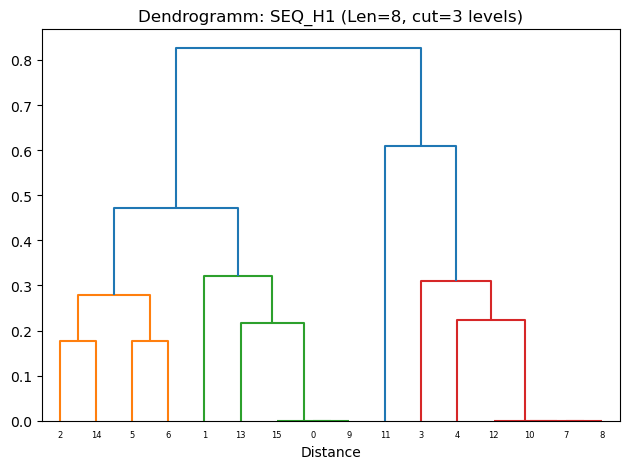


SEQ_H1, Länge 8 → 4 Subgruppen:
  Cluster 1:
    Antigen-Verteilung:
      25 kda ookinete surface antigen: 1x
      hemagglutinin: 1x
      spike protein s1: 1x
      hemagglutinin ha1 chain: 1x
    PDB_IDs:
      8ezk
      4xnm
      8dcc
      4m5z
    Sequenzen:
      GFSISSSY
      GGSISSSY
      GYSISSGY
      GYSISSNY
  Cluster 2:
    Antigen-Verteilung:
      spike protein s1: 2x
      envelope glycoprotein gp160: 1x
      glutamate receptor ionotropic, nmda 1: 1x
      genome polyprotein: 1x
    PDB_IDs:
      8x0y
      7wph
      6dfh
      8vuj
      5gzo
    Sequenzen:
      GASISSGD
      GGSISSNN
      GGSISSSN
      GGSISSSN
      GGSISSSN
  Cluster 3:
    Antigen-Verteilung:
      envelope glycoprotein gp120: 1x
    PDB_IDs:
      7kde
    Sequenzen:
      GYNIRSNN
  Cluster 4:
    Antigen-Verteilung:
      ige fc: 3x
      spike glycoprotein: 1x
      gametocyte surface protein p230: 1x
      neuraminidase: 1x
    PDB_IDs:
      7xdl
      7uvq
      7shz
      6pzy

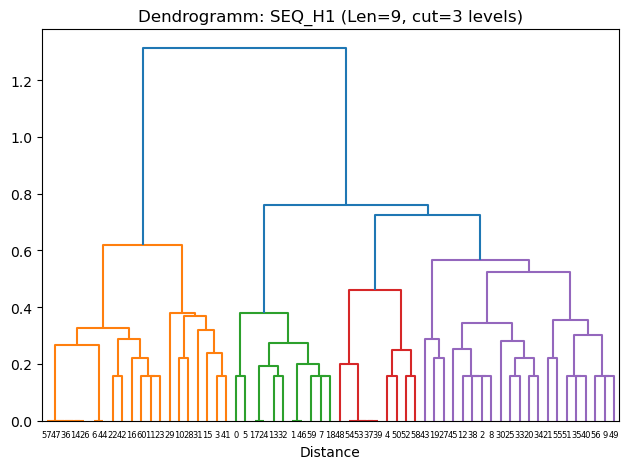


SEQ_H1, Länge 9 → 4 Subgruppen:
  Cluster 1:
    Antigen-Verteilung:
      spike glycoprotein: 11x
      spike protein s1: 4x
      hemagglutinin: 2x
      spike protein s2': 1x
      envelope glycoprotein b: 1x
      fusion glycoprotein f0: 1x
    PDB_IDs:
      7lss
      7cm4
      7d0d
      8hp9
      7xsa
      8rgz
      6urm
      7yve
      7mmo
      7ycy
      7t01
      8gdr
      7yvk
      7wrj
      8vye
      8erq
      8cw9
      8tma
      9bdf
      7wee
    Sequenzen:
      GFSLSTSGV
      GFSLSTSGV
      GFSLSTSGV
      GFSLSTSGV
      GFSLSTSGV
      GFSLSTSGM
      GFSLSTSGM
      GFSLINSGV
      GFSLSISGV
      GFSLSTPGG
      GFSLSTIGV
      GFSLSTYGV
      GFSLSTGGV
      GFSLKKNGV
      GFSVNTGGV
      GFSVTTSGV
      GFALTTSGM
      GGSFATENY
      GGFVTRNSY
      GFSLNTYGV
  Cluster 2:
    Antigen-Verteilung:
      hemagglutinin: 4x
      spike glycoprotein: 2x
      spike protein s1: 2x
      pre-glycoprotein polyprotein gp complex: 1x
      clade a/e 93t

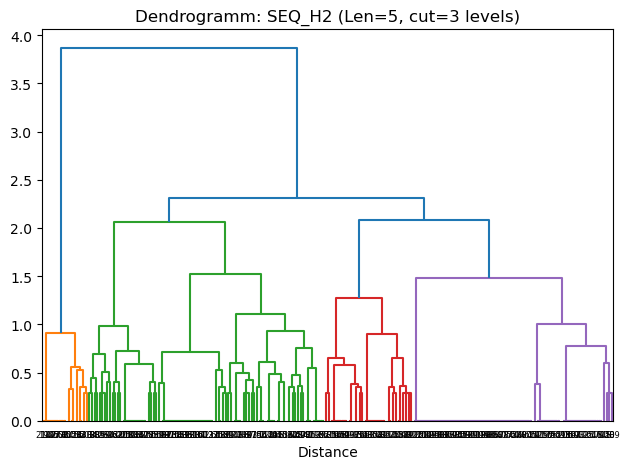


SEQ_H2, Länge 5 → 4 Subgruppen:
  Cluster 1:
    Antigen-Verteilung:
      spike glycoprotein: 10x
      spike protein s1: 3x
      fusion glycoprotein f0: 1x
      hemagglutinin: 1x
      envelope glycoprotein b: 1x
      spike protein s2': 1x
      cytotoxic t-lymphocyte protein 4: 1x
    PDB_IDs:
      7t01
      7lss
      7mmo
      7d0d
      8erq
      7xsa
      7yvk
      7yve
      8gdr
      7ycy
      8cw9
      6urm
      7cm4
      8rgz
      8vye
      8hp9
      7wee
      6xy2
    Sequenzen:
      YWDDD
      YWDDD
      YWDDD
      YWDDD
      YWDDD
      YWDDD
      YWDDD
      YWDDD
      YWDDD
      YWDDD
      DWEDN
      DWDDN
      DWDDN
      WWNND
      YWNDD
      YWDND
      YWDGD
      WYDGN
  Cluster 2:
    Antigen-Verteilung:
      spike protein s1: 18x
      spike glycoprotein: 17x
      hemagglutinin: 13x
      surface glycoprotein: 7x
      neuraminidase: 6x
      fusion glycoprotein f0: 4x
      epidermal growth factor receptor: 3x
      nucleoprotei

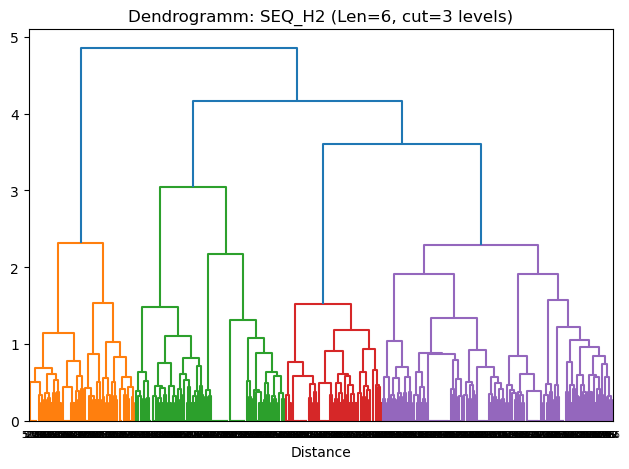


SEQ_H2, Länge 6 → 4 Subgruppen:
  Cluster 1:
    Antigen-Verteilung:
      spike glycoprotein: 28x
      spike protein s1: 15x
      neuraminidase: 7x
      ch848.10.17 gp120: 7x
      envelope glycoprotein e2: 6x
      hemagglutinin: 4x
      spike glycoprotein,fibritin: 4x
      ch848.10.17.sosip gp120: 3x
      spike protein: 2x
      envelope glycoprotein gp120: 2x
      envelope glycoprotein gp160: 2x
      e2 glycoprotein: 2x
      fusion glycoprotein f0: 2x
      envelope protein: 1x
      programmed cell death 1 ligand 1: 1x
      clade a/e 93th057 hiv-1 gp120 core: 1x
      nucleoprotein: 1x
      reticulocyte-binding protein homolog 5: 1x
      transforming growth factor beta-2: 1x
      reticulocyte binding protein 2b: 1x
      interleukin-17a: 1x
      vascular endothelial growth factor a: 1x
      hemagglutinin ha1: 1x
      gametocyte surface protein p230: 1x
      tumor necrosis factor ligand superfamily member 13b: 1x
      surface glycoprotein: 1x
      envelope glyco

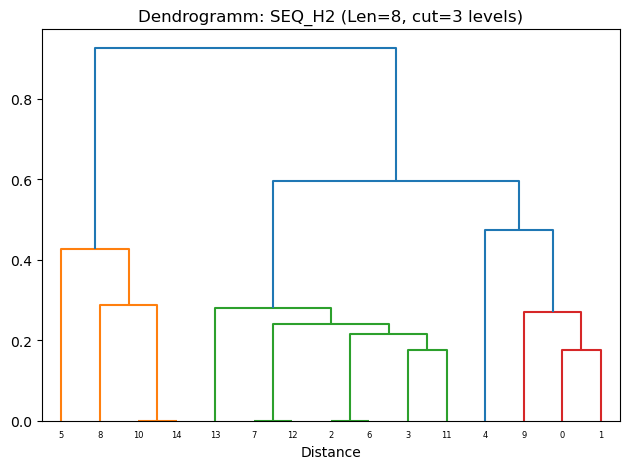


SEQ_H2, Länge 8 → 4 Subgruppen:
  Cluster 1:
    Antigen-Verteilung:
      spike glycoprotein: 2x
      spike protein s1: 1x
      envelope glycoprotein h: 1x
    PDB_IDs:
      8sdg
      7s07
      7ls9
      7kzb
    Sequenzen:
      SSNVNNDA
      RNKENSFT
      RNKANSYT
      RNKANSYT
  Cluster 2:
    Antigen-Verteilung:
      spike glycoprotein: 4x
      spike protein s1: 2x
      spike protein s2': 1x
    PDB_IDs:
      7ey5
      7x8y
      7jx3
      8suo
      8ekd
      8r8k
      7mzj
    Sequenzen:
      KSKADGQT
      KSKTDGGT
      KSKTDGGT
      KSKIDGGT
      KSKIDGGT
      KSKADGGT
      KRKSDGGT
  Cluster 3:
    Antigen-Verteilung:
      spike glycoprotein: 1x
    PDB_IDs:
      8khc
    Sequenzen:
      SSEIGGGT
  Cluster 4:
    Antigen-Verteilung:
      circumsporozoite protein: 1x
      hemagglutinin: 1x
      spike glycoprotein: 1x
    PDB_IDs:
      6o2b
      8ghk
      8jmm
    Sequenzen:
      RSKANGGR
      RTKGNSYA
      RSKAYGGT

-------------------------

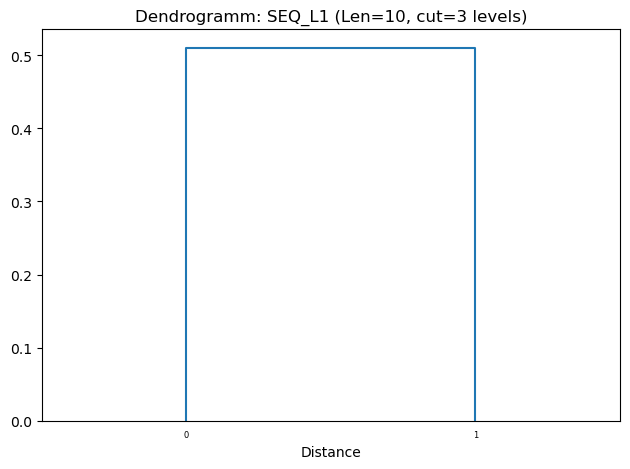


SEQ_L1, Länge 10 → 1 Subgruppen:
  Cluster 1:
    Antigen-Verteilung:
      gametocyte surface protein p230: 1x
      clade a/e 93th057 hiv-1 gp120 core: 1x
    PDB_IDs:
      7uvq
      4jb9
    Sequenzen:
      SASSSVSYMY
      RASQGGNSLN

--------------------------------------------------

✅ TSV geschrieben: cdr_cluster_pre_decided_HC_length_tsvs/clusters_SEQ_L1_len11.tsv


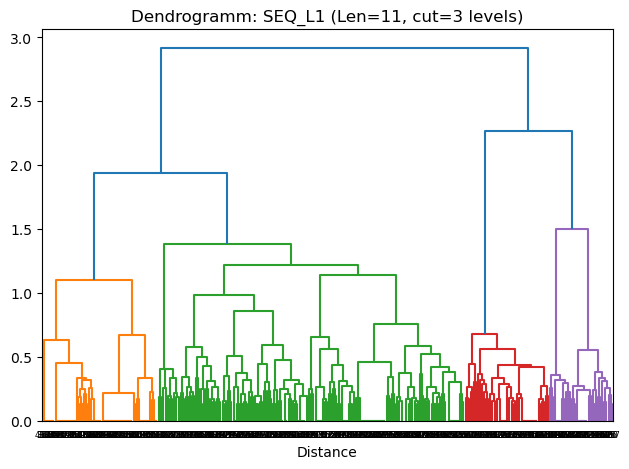


SEQ_L1, Länge 11 → 4 Subgruppen:
  Cluster 1:
    Antigen-Verteilung:
      spike glycoprotein: 23x
      spike protein s1: 19x
      hemagglutinin: 6x
      histone chaperone asf1: 4x
      programmed cell death protein 1: 3x
      neuraminidase: 3x
      gametocyte surface protein p230: 3x
      nucleoprotein: 2x
      spike protein: 2x
      circumsporozoite protein: 2x
      e2 glycoprotein: 2x
      cadmium and zinc efflux pump fief: 1x
      erythropoietin receptor: 1x
      programmed cell death 1 ligand 1: 1x
      epidermal growth factor receptor: 1x
      arginase-1: 1x
      envelope protein e: 1x
      envelope glycoprotein e2: 1x
      glutamate receptor ionotropic, nmda 1: 1x
      receptor tyrosine-protein kinase erbb-2: 1x
      tumor necrosis factor receptor superfamily member 9: 1x
      spike glycoprotein,fibritin: 1x
      leukocyte surface antigen cd47: 1x
      reticulocyte-binding protein homolog 5: 1x
      sars-cov-2 spike glycoprotein: 1x
      clade a/e 93th

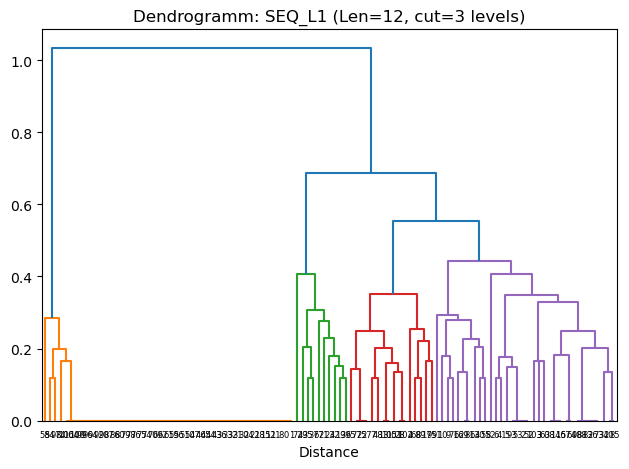


SEQ_L1, Länge 12 → 4 Subgruppen:
  Cluster 1:
    Antigen-Verteilung:
      spike protein s1: 18x
      spike glycoprotein: 17x
      surface glycoprotein: 3x
      hemagglutinin: 1x
      t-cell immunoreceptor with ig and itim domains: 1x
      sars-cov-2 spike glycoprotein: 1x
      circumsporozoite protein: 1x
      pre-glycoprotein polyprotein gp complex: 1x
      interleukin-17a: 1x
      nucleoprotein: 1x
      envelope glycoprotein e2: 1x
      spike glycoprotein,fibritin: 1x
    PDB_IDs:
      7ej4
      5ibl
      7ps1
      7coe
      7n62
      6xe1
      7mzm
      7d0c
      7lab
      7r6x
      7k8m
      7vyt
      7lrt
      7bnv
      7l2f
      7n5h
      6o25
      7n3i
      7ljr
      7l7e
      7beo
      5w1k
      7ls9
      7tcc
      7x7o
      6wir
      7orb
      7jmo
      7str
      7zbu
      8dzh
      8dlw
      8dad
      7x25
      7ul1
      7s5r
      7ru4
      7s5q
      8gsb
      8bec
      8k5g
      8w0w
      8qrf
      9fgt
      8qh0
   

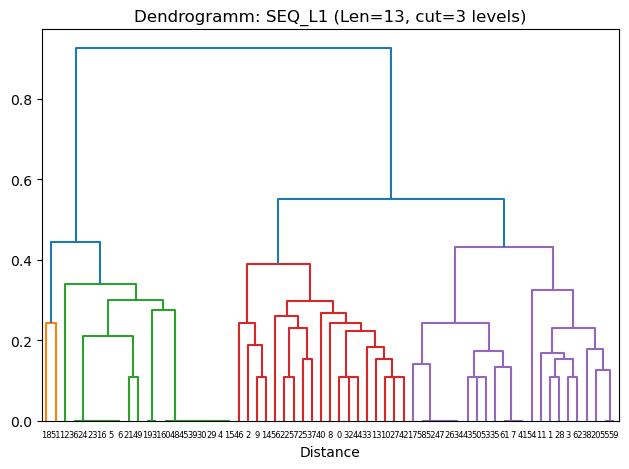


SEQ_L1, Länge 13 → 4 Subgruppen:
  Cluster 1:
    Antigen-Verteilung:
      spike protein s1: 1x
      envelope glycoprotein gp120: 1x
    PDB_IDs:
      7xsb
      7kde
    Sequenzen:
      TGSNGYIANNYVQ
      TGTSSNIENYHAF
  Cluster 2:
    Antigen-Verteilung:
      spike glycoprotein: 6x
      spike protein s1: 5x
      interleukin-17a: 2x
      hemagglutinin: 2x
      programmed cell death 1 ligand 1: 1x
      sars-cov-2 spike glycoprotein: 1x
      spike glycoprotein,fibritin,expression tag: 1x
      glutamate receptor ionotropic, nmda 1: 1x
    PDB_IDs:
      7yds
      7jva
      7ycn
      7yck
      7vzt
      8zhe
      8zho
      7u0x
      7m7b
      8dy1
      2vxs
      6ii4
      7ttx
      7jx3
      6ii8
      7wog
      7wo4
      8vuj
      8eoo
    Sequenzen:
      QSSQNVYSNNRLS
      TGSSGSIASNYVQ
      TGSSGSIASNYVQ
      TGSSGSIASNYVQ
      TGSSGSIASNYVQ
      TGSSGSIASNYVQ
      TGSSGSIASNYVQ
      TRNSGSIASNYVQ
      TGSSGNIASNYVQ
      TRSSGSLANYYVQ
      TRSS

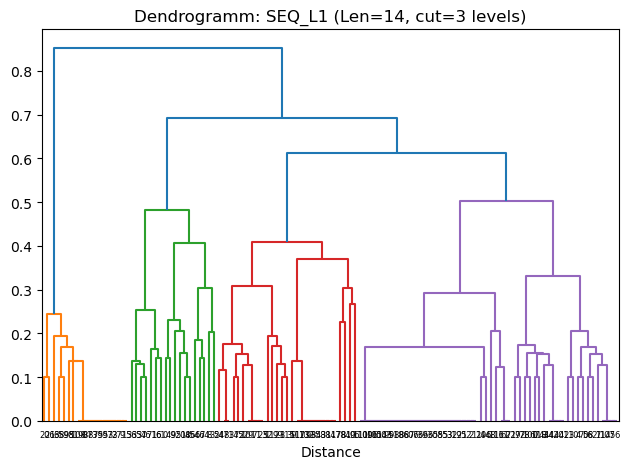


SEQ_L1, Länge 14 → 4 Subgruppen:
  Cluster 1:
    Antigen-Verteilung:
      spike protein s1: 7x
      spike glycoprotein: 6x
      fusion glycoprotein f0: 2x
      hemagglutinin: 2x
      ig epsilon chain c region: 1x
    PDB_IDs:
      8hrd
      8e2u
      8gdr
      3whe
      7m6f
      6ii9
      7wqv
      7laa
      7dx4
      5anm
      7m6h
      7cho
      7wp0
      7tjq
      8csj
      7yh6
      8zho
      8siq
    Sequenzen:
      LGGSSNIGAGYDVH
      TGSGSNLGADYGVH
      SGTSRDIGGYNYVA
      TGSSSNIGAGYAVH
      TGSSSNIGAGYYVH
      TGSSSNIGAGFDVH
      TGNSSNIGAGYDVH
      TGSSSNIGAGYDVH
      TGSSSNIGAGYDVH
      TGSSSNIGAGYDVH
      TGSSSNIGAGYDVH
      TGSSSNIGAGYDVH
      TGSSSNIGAGYDVH
      TGSSSNIGAGYDVH
      TGSSSNIGAGYDVH
      TGSSSNIGAGYDVH
      TGSSSNIGAGYDVH
      TGSSSNIGAGYDVH
  Cluster 2:
    Antigen-Verteilung:
      ch848.10.17 gp120: 4x
      spike glycoprotein: 2x
      envelope glycoprotein e: 2x
      ch848.10.17.sosip gp120: 1x
      spike pr

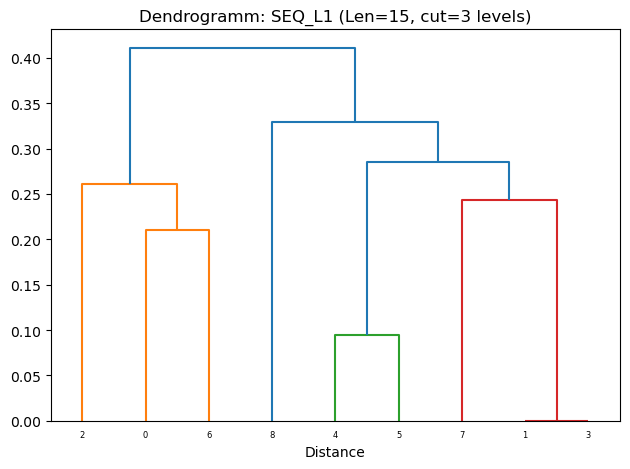


SEQ_L1, Länge 15 → 4 Subgruppen:
  Cluster 1:
    Antigen-Verteilung:
      interferon alpha-2: 1x
      spike glycoprotein: 1x
      programmed cell death protein 1: 1x
    PDB_IDs:
      4z5r
      7mw6
      5ggs
    Sequenzen:
      RASQSVSTSSYSYMH
      RASESVEYYGTSLMQ
      RASKGVSTSGYSYLH
  Cluster 2:
    Antigen-Verteilung:
      25 kda ookinete surface antigen: 1x
    PDB_IDs:
      6phc
    Sequenzen:
      RSSQSLLHNGYNYLD
  Cluster 3:
    Antigen-Verteilung:
      ige fc: 2x
    PDB_IDs:
      7shy
      7si0
    Sequenzen:
      RASQSVDYDGDSYMN
      RASQSVDSDGDSYMN
  Cluster 4:
    Antigen-Verteilung:
      spike glycoprotein: 2x
      ige fc: 1x
    PDB_IDs:
      7shz
      7mw3
      7e5s
    Sequenzen:
      RASKPVDGEGDSYLN
      RASESVDNYGISFMN
      RASESVDNYGISFMN

--------------------------------------------------

✅ TSV geschrieben: cdr_cluster_pre_decided_HC_length_tsvs/clusters_SEQ_L1_len16.tsv


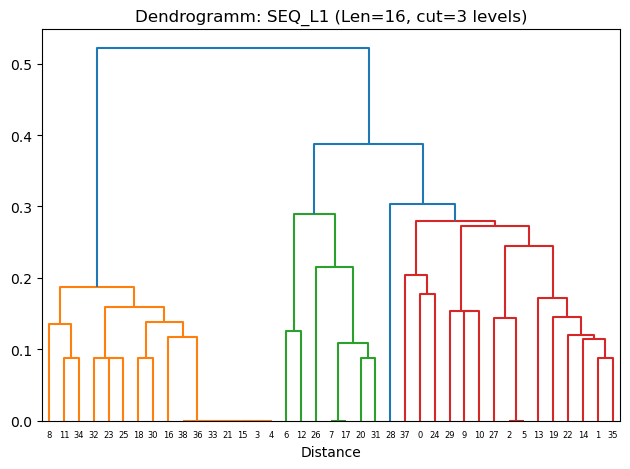


SEQ_L1, Länge 16 → 4 Subgruppen:
  Cluster 1:
    Antigen-Verteilung:
      hemagglutinin: 4x
      spike glycoprotein: 4x
      spike protein s1: 3x
      circumsporozoite protein: 1x
      envelope glycoprotein h: 1x
      spike protein: 1x
      clade a/e 93th057 hiv-1 gp120 core: 1x
      neuraminidase: 1x
    PDB_IDs:
      8tnl
      8bg1
      7rxp
      6iuv
      7e8c
      7pnm
      7t4r
      5a3i
      7wsc
      6c6z
      6oej
      7deo
      7chh
      7e9o
      8zr4
      8us0
    Sequenzen:
      NSSQSLLHSNGYAHLD
      RSSQSLLHSNGNNYLD
      RSSQSLLHSNGKNYLD
      RSSQSLLHSDGYNYLD
      RSSQSLLHSNGYLYLD
      RSSQSLLHSNGYKYLD
      RSSQSLLHTNGYNYLD
      RSSQSLLHGNGYNYLD
      RSSQSLLQSNGYNYLD
      RSSQSLLHSNGYNYLD
      RSSQSLLHSNGYNYLD
      RSSQSLLHSNGYNYLD
      RSSQSLLHSNGYNYLD
      RSSQSLLHSNGYNYLD
      RSSQSLLHSNGYNYLD
      RSSQSLLHSNGYNYLD
  Cluster 2:
    Antigen-Verteilung:
      spike glycoprotein: 3x
      reticulocyte-binding protein homolog 5: 1x


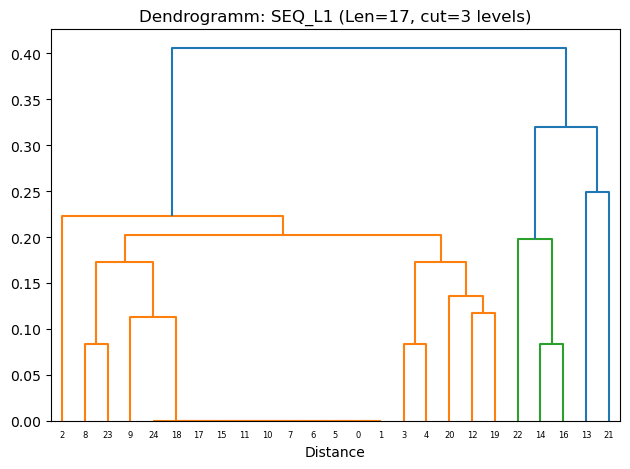


SEQ_L1, Länge 17 → 3 Subgruppen:
  Cluster 1:
    Antigen-Verteilung:
      spike glycoprotein: 8x
      spike protein s1: 5x
      surface glycoprotein: 2x
      gametocyte surface protein p230: 2x
      hemagglutinin: 2x
      spike protein s2': 1x
    PDB_IDs:
      8ekd
      8d48
      7eng
      7mzk
      7kn3
      7k9z
      7czy
      7d0d
      7ps2
      7czx
      7uvs
      7ubs
      8dnn
      8ume
      8suo
      8gf2
      8cwj
      7prz
      7fjo
      6xq4
    Sequenzen:
      KSSQSVLYAANNKNYLA
      KSSRNVLYSSNNKNYLA
      KSSQSVLYRSNNKNYLA
      KSSQSVLYSSNNKNYLG
      KSSQSVLYSSNNKNYLA
      KSSQSVLYSSNNKNYLA
      KSSQSVLYSSNNKNYLA
      KSSQSVLYSSNNKNYLA
      KSSQSVLYSSNNKNYLA
      KSSQSVLYSSNNKNYLA
      KSSQSVLYSSNNKNYLA
      KSSQSVLYSSNNKNYLA
      KSSQSVLYSSNNKNYLA
      KSSQSVLYSSNNKNYLA
      KSSQSVLYSSNNKNYLA
      KSSQSVLWSSINKNYLA
      KSSQSVLYSSINKNYLA
      KSSQSILYNSNNKTYLA
      KSSQSLLYSNNQKNYLA
      KSSQSLLYSSRNKNYLA
  Cluster 2:
    Ant

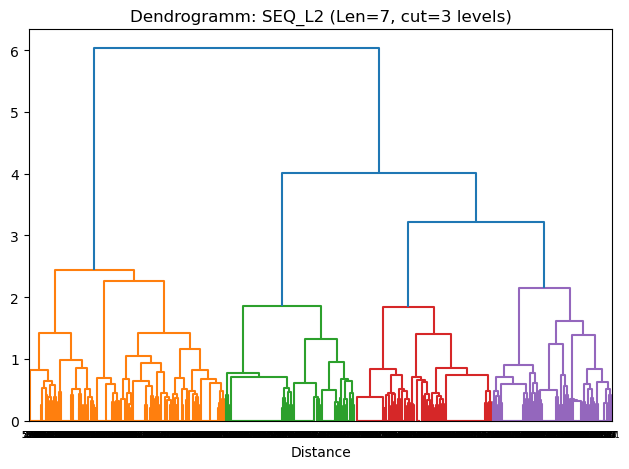


SEQ_L2, Länge 7 → 4 Subgruppen:
  Cluster 1:
    Antigen-Verteilung:
      spike glycoprotein: 70x
      spike protein s1: 59x
      hemagglutinin: 14x
      fusion glycoprotein f0: 10x
      neuraminidase: 7x
      ch848.10.17 gp120: 7x
      reticulocyte binding protein 2b: 6x
      envelope glycoprotein gp120: 6x
      envelope glycoprotein b: 5x
      surface glycoprotein: 5x
      circumsporozoite protein: 5x
      gametocyte surface protein p230: 4x
      25 kda ookinete surface antigen: 4x
      interleukin-17a: 4x
      spike glycoprotein,fibritin: 4x
      ch848.10.17.sosip gp120: 4x
      sars-cov-2 spike glycoprotein: 3x
      spike glycoprotein,fibritin,expression tag: 3x
      envelope protein: 3x
      hemagglutinin ha1 chain: 3x
      envelope glycoprotein gp160: 3x
      clade a/e 93th057 hiv-1 gp120 core: 3x
      receptor tyrosine-protein kinase erbb-2: 2x
      nucleoprotein: 2x
      reticulocyte-binding protein homolog 5: 2x
      hemagglutinin ha1: 2x
      epide

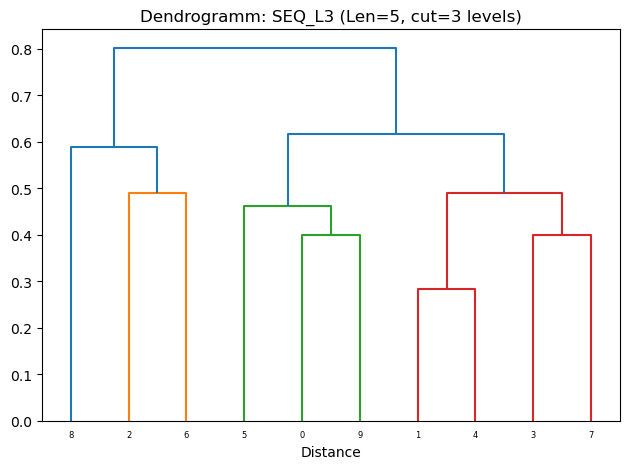


SEQ_L3, Länge 5 → 4 Subgruppen:
  Cluster 1:
    Antigen-Verteilung:
      clade a/e 93th057 hiv-1 gp120 core: 1x
    PDB_IDs:
      4jb9
    Sequenzen:
      QQFEF
  Cluster 2:
    Antigen-Verteilung:
      envelope glycoprotein gp120: 1x
      envelope glycoprotein gp160: 1x
    PDB_IDs:
      7ugq
      4ydi
    Sequenzen:
      SAFEY
      QVIES
  Cluster 3:
    Antigen-Verteilung:
      glycoprotein 120: 1x
      spike glycoprotein: 1x
      envelope glycoprotein gp160: 1x
    PDB_IDs:
      7rdw
      9cci
      4j6r
    Sequenzen:
      QHMYT
      QQYDA
      QQYET
  Cluster 4:
    Antigen-Verteilung:
      spike protein s1: 1x
      hemagglutinin: 1x
      spike glycoprotein: 1x
      clade a/e 93th057 hiv-1 gp120 core: 1x
    PDB_IDs:
      8qh0
      6e4x
      7s6j
      5te6
    Sequenzen:
      QQGVT
      QQQGT
      QQPLT
      QVLQF

--------------------------------------------------

✅ TSV geschrieben: cdr_cluster_pre_decided_HC_length_tsvs/clusters_SEQ_L3_len8.tsv


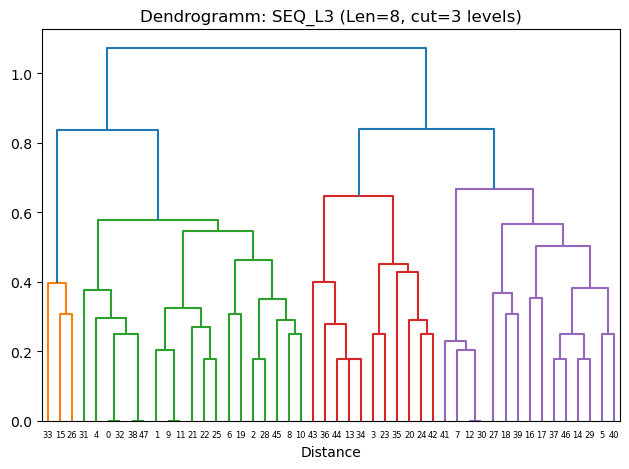


SEQ_L3, Länge 8 → 4 Subgruppen:
  Cluster 1:
    Antigen-Verteilung:
      envelope glycoprotein gp160: 1x
      fusion glycoprotein f0: 1x
      hemagglutinin ha1: 1x
    PDB_IDs:
      5t3z
      8eay
      5w08
    Sequenzen:
      YSYADGVA
      QAWDSSVV
      SSYAGSVV
  Cluster 2:
    Antigen-Verteilung:
      spike protein s1: 6x
      spike glycoprotein: 5x
      envelope glycoprotein e2: 2x
      surface glycoprotein: 1x
      envelope glycoprotein e: 1x
      spike protein s2': 1x
      reticulocyte-binding protein homolog 5: 1x
      hemagglutinin: 1x
      tumor necrosis factor receptor superfamily member 5: 1x
    PDB_IDs:
      7ljr
      8tzy
      9l6c
      6uyg
      7ps1
      7n62
      8v5q
      8suo
      8ekd
      8bbo
      7ul1
      7jmo
      8pwv
      7y6l
      8wyj
      7nx7
      5w42
      8x0y
      8yx1
    Sequenzen:
      QQYSSSRT
      QQYGGSPF
      QQYGSSPT
      QQYGSSPT
      QQYGSSPL
      QQYGSSPL
      QQSYRTLT
      QQYYSTLT
      QQYYST

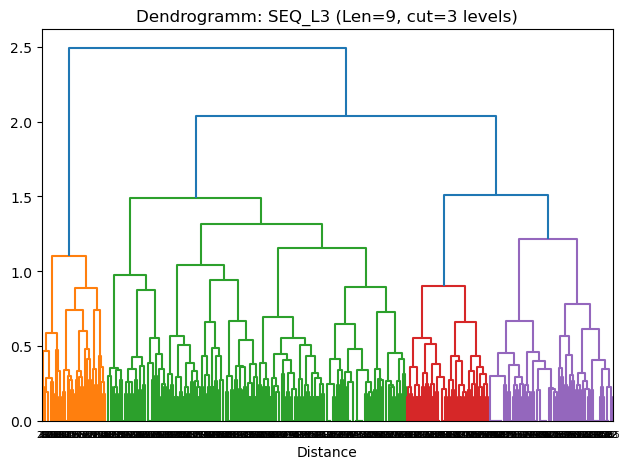


SEQ_L3, Länge 9 → 4 Subgruppen:
  Cluster 1:
    Antigen-Verteilung:
      spike glycoprotein: 17x
      spike protein s1: 7x
      hemagglutinin: 4x
      circumsporozoite protein: 3x
      spike glycoprotein,fibritin: 3x
      spike glycoprotein,fibritin,expression tag: 3x
      envelope glycoprotein b: 2x
      envelope glycoprotein e2: 2x
      genome polyprotein: 1x
      fusion glycoprotein f0: 1x
      e2 glycoprotein: 1x
      glutamate receptor ionotropic, nmda 1: 1x
      envelope glycoprotein gp160: 1x
      nucleoprotein: 1x
      erythropoietin receptor: 1x
    PDB_IDs:
      8rh0
      6urm
      8hld
      6b0s
      6kyz
      7rxl
      4xnm
      8tgv
      8dlr
      4dag
      8dwy
      8vye
      7v23
      8r1d
      7rxj
      7ttx
      7yck
      8zhe
      8eoo
      7u0x
      6ii4
      8vuj
      7jx3
      8zho
      6ii8
      8rgz
      7ycn
      7ru4
      7zr9
      8xsd
      8w0w
      8z6s
      8z6u
      8gpy
      5vn8
      8suo
      7l2c
  

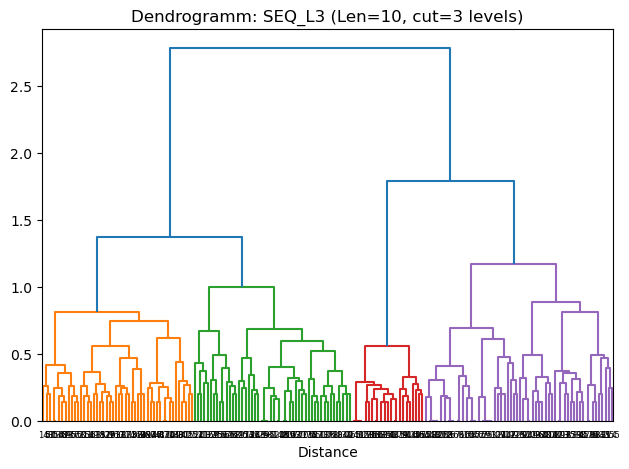


SEQ_L3, Länge 10 → 4 Subgruppen:
  Cluster 1:
    Antigen-Verteilung:
      spike glycoprotein: 11x
      spike protein s1: 9x
      neuraminidase: 7x
      gametocyte surface protein p230: 6x
      surface glycoprotein: 3x
      tyrosine-protein phosphatase non-receptor type substrate 1: 2x
      circumsporozoite protein: 2x
      leukocyte surface antigen cd47: 1x
      cadmium and zinc efflux pump fief: 1x
      25 kda ookinete surface antigen: 1x
      reticulocyte-binding protein-like protein 5: 1x
      hemagglutinin: 1x
      clade a/e 93th057 hiv-1 gp120 core: 1x
      envelope protein e: 1x
      hemagglutinin ha1: 1x
    PDB_IDs:
      8rp8
      8zr4
      7ucq
      7u9o
      7lop
      7pry
      7ui1
      7uvh
      8f6e
      7wwl
      7ua2
      7uvq
      7wnb
      7wbz
      8y4a
      8i3u
      7uow
      7neg
      8bg4
      7bz5
      6q1z
      7x91
      7b3o
      6phb
      8qkr
      6e56
      7v3l
      7czq
      8z4e
      6q20
      7qf0
      7y0w

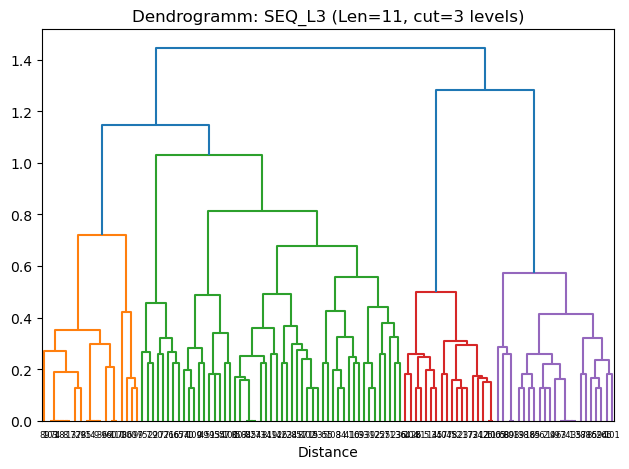


SEQ_L3, Länge 11 → 4 Subgruppen:
  Cluster 1:
    Antigen-Verteilung:
      spike glycoprotein: 10x
      spike protein s1: 6x
      hemagglutinin: 2x
      envelope glycoprotein gp120: 1x
    PDB_IDs:
      7kde
      7laa
      7m6h
      7wp0
      8y4c
      8siq
      8csj
      7m6f
      7dx4
      3whe
      8zho
      7wqv
      7cho
      6ii9
      7swp
      7wee
      7yvi
      7k8w
      7czw
    Sequenzen:
      QSYDSGLRSYI
      QSYDSSLSGWV
      QSYDSSLSGWV
      QSYDSSLSGWV
      QSYDSSLSGWV
      QSYDSSLSGWV
      QSYDSSLSGRV
      QSYDSRLSGWV
      QSYDSSLSGSV
      QSYDSSLSGSV
      QSYDSSLSGSV
      QSYDSSLSGSV
      QSCDSSLSVVV
      QSYDSSLSGVV
      QSYDSSLSGVV
      SSYTTTSTHIL
      SSYTSSSTLYV
      SSYTSSSTSVV
      SSYTSSSTLVV
  Cluster 2:
    Antigen-Verteilung:
      spike glycoprotein: 15x
      spike protein s1: 12x
      fusion glycoprotein f0: 4x
      surface glycoprotein: 2x
      envelope protein: 2x
      hemagglutinin: 2x
      glutamate recep

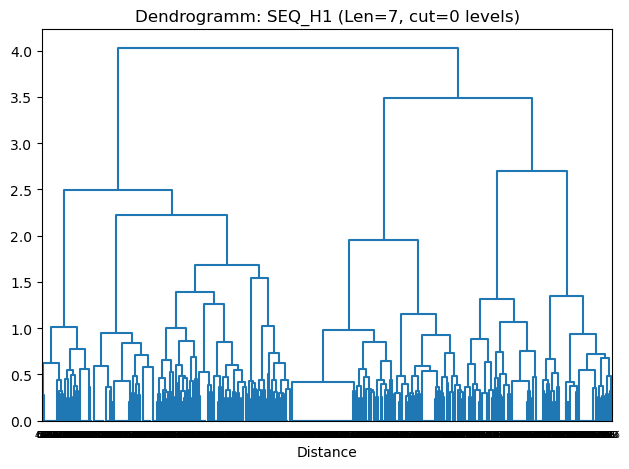


SEQ_H1, Länge 7 → 1 Subgruppen:
  Cluster 1:
    Antigen-Verteilung:
      spike glycoprotein: 192x
      spike protein s1: 166x
      hemagglutinin: 36x
      surface glycoprotein: 21x
      neuraminidase: 19x
      fusion glycoprotein f0: 15x
      gametocyte surface protein p230: 14x
      circumsporozoite protein: 12x
      envelope glycoprotein e2: 12x
      programmed cell death protein 1: 11x
      clade a/e 93th057 hiv-1 gp120 core: 10x
      envelope glycoprotein gp160: 8x
      receptor tyrosine-protein kinase erbb-2: 8x
      spike glycoprotein,fibritin: 8x
      ch848.10.17 gp120: 7x
      envelope glycoprotein gp120: 7x
      leukocyte surface antigen cd47: 7x
      envelope glycoprotein b: 7x
      interleukin-17a: 7x
      reticulocyte binding protein 2b: 7x
      reticulocyte-binding protein homolog 5: 6x
      cytotoxic t-lymphocyte protein 4: 6x
      programmed cell death 1 ligand 1: 6x
      nucleoprotein: 6x
      spike protein s2': 5x
      sars-cov-2 spike glyco

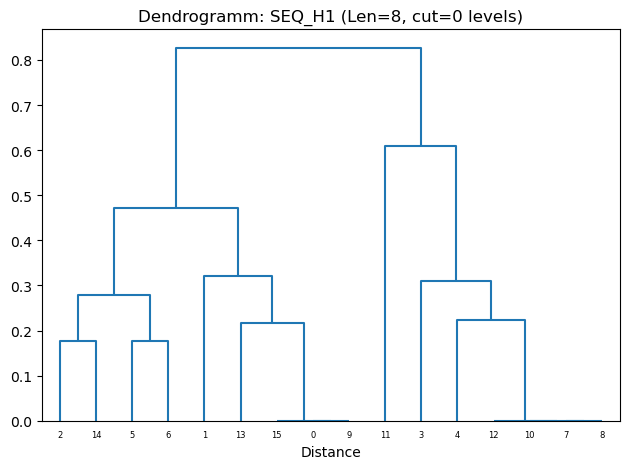


SEQ_H1, Länge 8 → 1 Subgruppen:
  Cluster 1:
    Antigen-Verteilung:
      spike protein s1: 3x
      ige fc: 3x
      25 kda ookinete surface antigen: 1x
      hemagglutinin: 1x
      hemagglutinin ha1 chain: 1x
      envelope glycoprotein gp160: 1x
      glutamate receptor ionotropic, nmda 1: 1x
      genome polyprotein: 1x
      envelope glycoprotein gp120: 1x
      spike glycoprotein: 1x
      gametocyte surface protein p230: 1x
      neuraminidase: 1x
    PDB_IDs:
      8ezk
      4xnm
      8dcc
      4m5z
      8x0y
      7wph
      6dfh
      8vuj
      5gzo
      7kde
      7xdl
      7uvq
      7shz
      6pzy
      7shy
      7si0
    Sequenzen:
      GFSISSSY
      GGSISSSY
      GYSISSGY
      GYSISSNY
      GASISSGD
      GGSISSNN
      GGSISSSN
      GGSISSSN
      GGSISSSN
      GYNIRSNN
      GYSFTSYY
      GYSITSDY
      GYSITSGY
      GYTISSGY
      GYSITSGY
      GYSITSGY

--------------------------------------------------

✅ TSV geschrieben: cdr_cluster_pre_decide

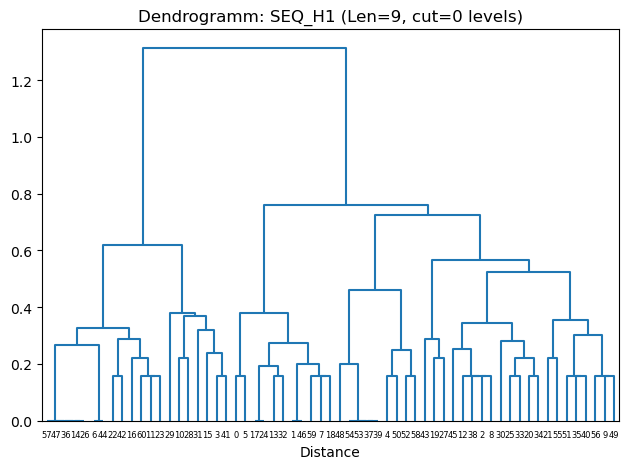


SEQ_H1, Länge 9 → 1 Subgruppen:
  Cluster 1:
    Antigen-Verteilung:
      spike glycoprotein: 18x
      spike protein s1: 10x
      hemagglutinin: 10x
      neuraminidase: 5x
      surface glycoprotein: 4x
      epidermal growth factor receptor: 3x
      fusion glycoprotein f0: 2x
      spike protein s2': 1x
      envelope glycoprotein b: 1x
      pre-glycoprotein polyprotein gp complex: 1x
      clade a/e 93th057 hiv-1 gp120 core: 1x
      tumor necrosis factor receptor superfamily member 5: 1x
      envelope protein: 1x
      spike glycoprotein,fibritin: 1x
      envelope glycoprotein e: 1x
      e2 glycoprotein: 1x
    PDB_IDs:
      7lss
      7cm4
      7d0d
      8hp9
      7xsa
      8rgz
      6urm
      7yve
      7mmo
      7ycy
      7t01
      8gdr
      7yvk
      7wrj
      8vye
      8erq
      8cw9
      8tma
      9bdf
      7wee
      8veb
      8zho
      8tp6
      8eoo
      8cbd
      7bel
      8vef
      5w1k
      5kjr
      8yx1
      8tp7
      7pry
      7

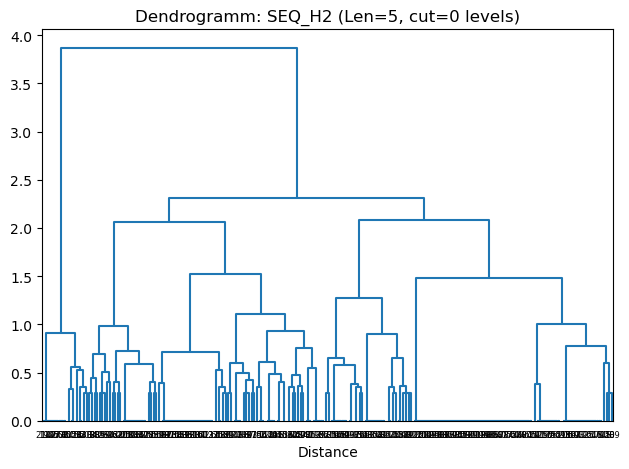


SEQ_H2, Länge 5 → 1 Subgruppen:
  Cluster 1:
    Antigen-Verteilung:
      spike protein s1: 67x
      spike glycoprotein: 58x
      hemagglutinin: 23x
      surface glycoprotein: 14x
      neuraminidase: 8x
      fusion glycoprotein f0: 5x
      spike protein s2': 4x
      epidermal growth factor receptor: 4x
      nucleoprotein: 3x
      ige fc: 3x
      spike glycoprotein,fibritin: 3x
      gametocyte surface protein p230: 2x
      25 kda ookinete surface antigen: 2x
      envelope glycoprotein e: 2x
      envelope glycoprotein e2: 2x
      reticulocyte-binding protein homolog 5: 2x
      envelope glycoprotein b: 1x
      cytotoxic t-lymphocyte protein 4: 1x
      hemagglutinin ha1: 1x
      envelope glycoprotein h: 1x
      e2 glycoprotein: 1x
      glycoprotein 120: 1x
      programmed cell death 1 ligand 1: 1x
      tumor necrosis factor receptor superfamily member 5: 1x
      envelope protein e: 1x
      programmed cell death protein 1: 1x
      pre-glycoprotein polyprotein gp 

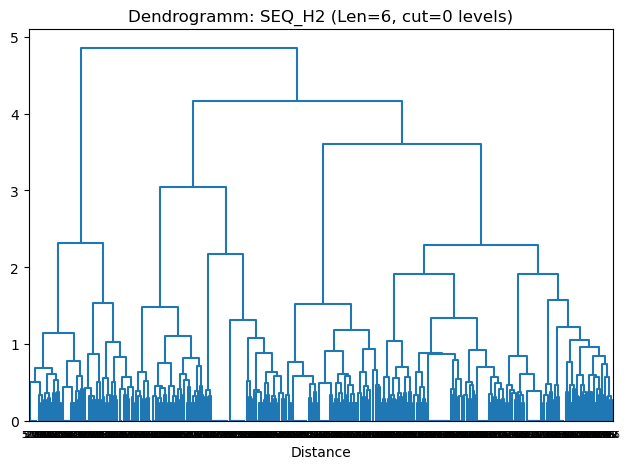


SEQ_H2, Länge 6 → 1 Subgruppen:
  Cluster 1:
    Antigen-Verteilung:
      spike glycoprotein: 145x
      spike protein s1: 109x
      hemagglutinin: 23x
      neuraminidase: 17x
      gametocyte surface protein p230: 13x
      fusion glycoprotein f0: 12x
      surface glycoprotein: 11x
      circumsporozoite protein: 11x
      envelope glycoprotein e2: 10x
      clade a/e 93th057 hiv-1 gp120 core: 10x
      programmed cell death protein 1: 10x
      envelope glycoprotein gp120: 8x
      envelope glycoprotein gp160: 8x
      receptor tyrosine-protein kinase erbb-2: 8x
      ch848.10.17 gp120: 7x
      interleukin-17a: 7x
      envelope glycoprotein b: 7x
      leukocyte surface antigen cd47: 7x
      spike glycoprotein,fibritin: 6x
      reticulocyte binding protein 2b: 6x
      envelope protein: 5x
      programmed cell death 1 ligand 1: 5x
      sars-cov-2 spike glycoprotein: 5x
      cytotoxic t-lymphocyte protein 4: 5x
      spike protein: 4x
      reticulocyte-binding protein hom

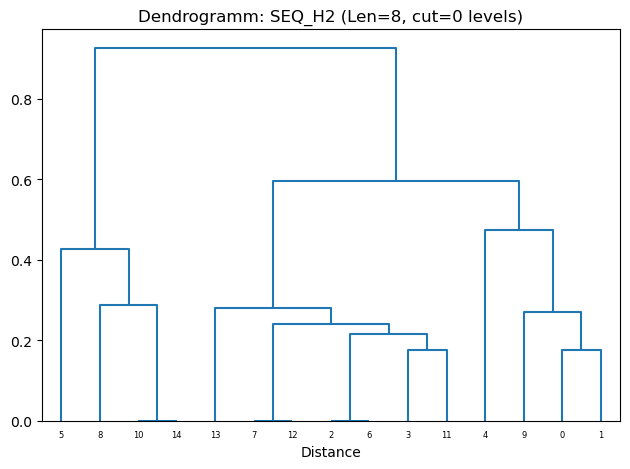


SEQ_H2, Länge 8 → 1 Subgruppen:
  Cluster 1:
    Antigen-Verteilung:
      spike glycoprotein: 8x
      spike protein s1: 3x
      envelope glycoprotein h: 1x
      spike protein s2': 1x
      circumsporozoite protein: 1x
      hemagglutinin: 1x
    PDB_IDs:
      8sdg
      7s07
      7ls9
      7kzb
      7ey5
      7x8y
      7jx3
      8suo
      8ekd
      8r8k
      7mzj
      8khc
      6o2b
      8ghk
      8jmm
    Sequenzen:
      SSNVNNDA
      RNKENSFT
      RNKANSYT
      RNKANSYT
      KSKADGQT
      KSKTDGGT
      KSKTDGGT
      KSKIDGGT
      KSKIDGGT
      KSKADGGT
      KRKSDGGT
      SSEIGGGT
      RSKANGGR
      RTKGNSYA
      RSKAYGGT

--------------------------------------------------

✅ TSV geschrieben: cdr_cluster_pre_decided_HC_length_tsvs/clusters_SEQ_L1_len10.tsv


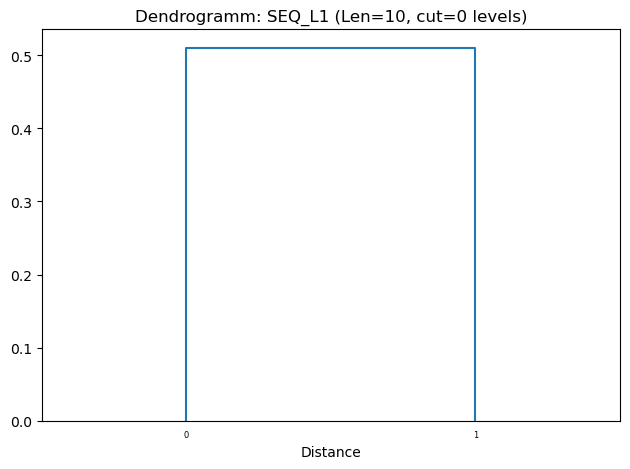


SEQ_L1, Länge 10 → 1 Subgruppen:
  Cluster 1:
    Antigen-Verteilung:
      gametocyte surface protein p230: 1x
      clade a/e 93th057 hiv-1 gp120 core: 1x
    PDB_IDs:
      7uvq
      4jb9
    Sequenzen:
      SASSSVSYMY
      RASQGGNSLN

--------------------------------------------------

✅ TSV geschrieben: cdr_cluster_pre_decided_HC_length_tsvs/clusters_SEQ_L1_len11.tsv


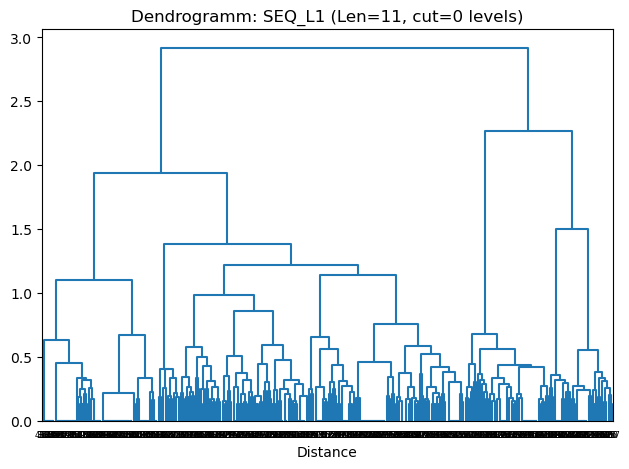


SEQ_L1, Länge 11 → 1 Subgruppen:
  Cluster 1:
    Antigen-Verteilung:
      spike glycoprotein: 107x
      spike protein s1: 94x
      hemagglutinin: 24x
      neuraminidase: 14x
      surface glycoprotein: 13x
      fusion glycoprotein f0: 12x
      programmed cell death protein 1: 9x
      circumsporozoite protein: 9x
      gametocyte surface protein p230: 9x
      envelope glycoprotein e2: 6x
      clade a/e 93th057 hiv-1 gp120 core: 6x
      envelope glycoprotein gp160: 6x
      epidermal growth factor receptor: 5x
      receptor tyrosine-protein kinase erbb-2: 5x
      reticulocyte-binding protein homolog 5: 5x
      reticulocyte binding protein 2b: 5x
      hemagglutinin ha1 chain: 5x
      histone chaperone asf1: 4x
      spike protein: 4x
      tumor necrosis factor receptor superfamily member 9: 4x
      leukocyte surface antigen cd47: 4x
      spike protein s2': 4x
      envelope glycoprotein b: 4x
      genome polyprotein: 4x
      nucleoprotein: 3x
      arginase-1: 3x
   

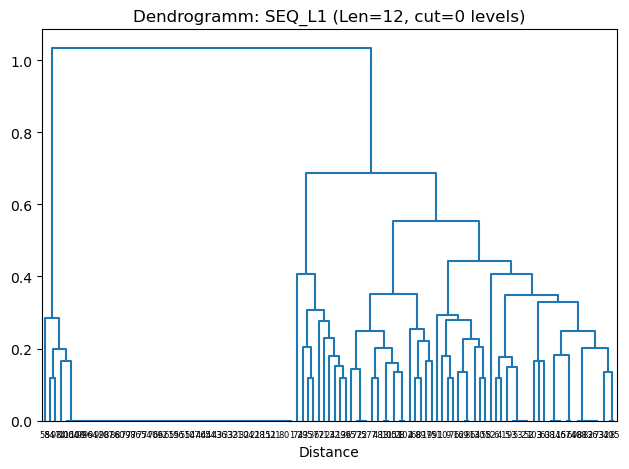


SEQ_L1, Länge 12 → 1 Subgruppen:
  Cluster 1:
    Antigen-Verteilung:
      spike glycoprotein: 32x
      spike protein s1: 29x
      surface glycoprotein: 7x
      envelope glycoprotein e2: 5x
      hemagglutinin: 3x
      spike glycoprotein,fibritin: 3x
      cytotoxic t-lymphocyte protein 4: 3x
      neuraminidase: 3x
      circumsporozoite protein: 2x
      glycoprotein 120: 2x
      t-cell immunoreceptor with ig and itim domains: 1x
      sars-cov-2 spike glycoprotein: 1x
      pre-glycoprotein polyprotein gp complex: 1x
      interleukin-17a: 1x
      nucleoprotein: 1x
      leukocyte surface antigen cd47: 1x
      hemagglutinin ha1: 1x
      vascular endothelial growth factor a: 1x
      spike protein s2': 1x
      envelope glycoprotein gp120: 1x
      envelope glycoprotein h: 1x
      transforming growth factor beta-2: 1x
      envelope glycoprotein gp160: 1x
      envelope protein: 1x
      interferon alpha-2: 1x
      clade a/e 93th057 hiv-1 gp120 core: 1x
      programmed c

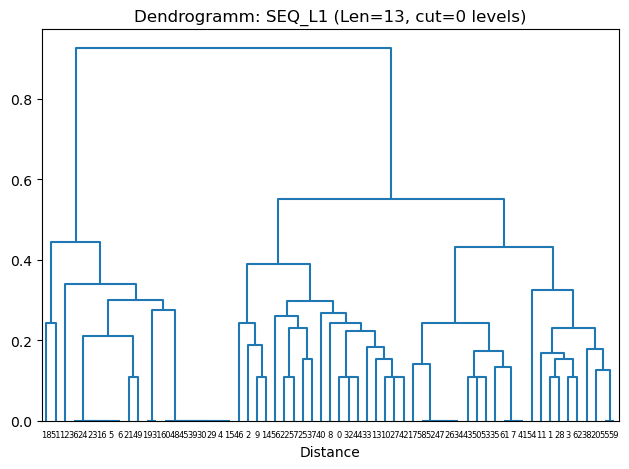


SEQ_L1, Länge 13 → 1 Subgruppen:
  Cluster 1:
    Antigen-Verteilung:
      spike glycoprotein: 22x
      spike protein s1: 13x
      hemagglutinin: 6x
      neuraminidase: 3x
      envelope glycoprotein b: 3x
      envelope glycoprotein gp120: 2x
      interleukin-17a: 2x
      envelope protein: 2x
      programmed cell death 1 ligand 1: 1x
      sars-cov-2 spike glycoprotein: 1x
      spike glycoprotein,fibritin,expression tag: 1x
      glutamate receptor ionotropic, nmda 1: 1x
      receptor tyrosine-protein kinase erbb-2: 1x
      gametocyte surface protein p230: 1x
      surface glycoprotein: 1x
      erythropoietin receptor: 1x
      25 kda ookinete surface antigen: 1x
      nucleoprotein: 1x
    PDB_IDs:
      7xsb
      7kde
      7yds
      7jva
      7ycn
      7yck
      7vzt
      8zhe
      8zho
      7u0x
      7m7b
      8dy1
      2vxs
      6ii4
      7ttx
      7jx3
      6ii8
      7wog
      7wo4
      8vuj
      8eoo
      3wsq
      9dwe
      8zby
      7yve
   

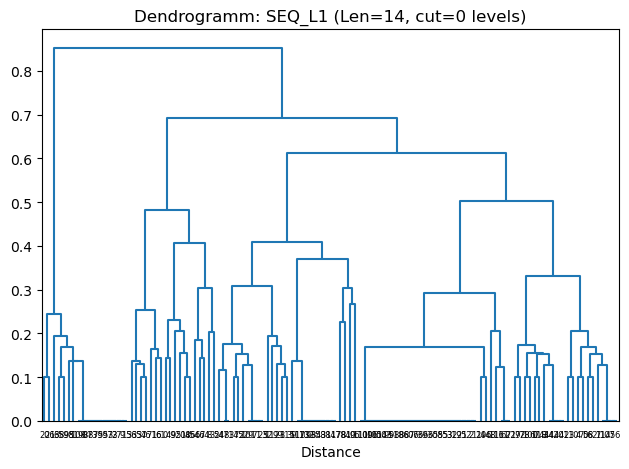


SEQ_L1, Länge 14 → 1 Subgruppen:
  Cluster 1:
    Antigen-Verteilung:
      spike protein s1: 34x
      spike glycoprotein: 31x
      ch848.10.17 gp120: 7x
      hemagglutinin: 4x
      ch848.10.17.sosip gp120: 4x
      neuraminidase: 4x
      fusion glycoprotein f0: 3x
      spike glycoprotein,fibritin: 3x
      envelope glycoprotein gp120: 3x
      reticulocyte binding protein 2b: 2x
      envelope glycoprotein e: 2x
      surface glycoprotein: 2x
      clade a/e 93th057 hiv-1 gp120 core: 2x
      spike glycoprotein,fibritin,expression tag: 2x
      sars-cov-2 spike glycoprotein: 2x
      programmed cell death 1 ligand 1: 2x
      envelope glycoprotein gp160: 2x
      erythropoietin receptor: 2x
      ig epsilon chain c region: 1x
      hemagglutinin ha1: 1x
      gametocyte surface protein p230: 1x
      e2 glycoprotein: 1x
      envelope protein: 1x
      envelope protein e: 1x
      receptor tyrosine-protein kinase erbb-2: 1x
      nucleoprotein: 1x
    PDB_IDs:
      8hrd
      

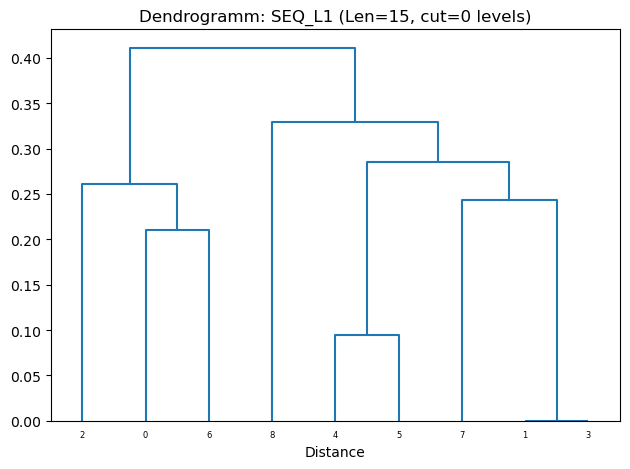


SEQ_L1, Länge 15 → 1 Subgruppen:
  Cluster 1:
    Antigen-Verteilung:
      spike glycoprotein: 3x
      ige fc: 3x
      interferon alpha-2: 1x
      programmed cell death protein 1: 1x
      25 kda ookinete surface antigen: 1x
    PDB_IDs:
      4z5r
      7mw6
      5ggs
      6phc
      7shy
      7si0
      7shz
      7mw3
      7e5s
    Sequenzen:
      RASQSVSTSSYSYMH
      RASESVEYYGTSLMQ
      RASKGVSTSGYSYLH
      RSSQSLLHNGYNYLD
      RASQSVDYDGDSYMN
      RASQSVDSDGDSYMN
      RASKPVDGEGDSYLN
      RASESVDNYGISFMN
      RASESVDNYGISFMN

--------------------------------------------------

✅ TSV geschrieben: cdr_cluster_pre_decided_HC_length_tsvs/clusters_SEQ_L1_len16.tsv


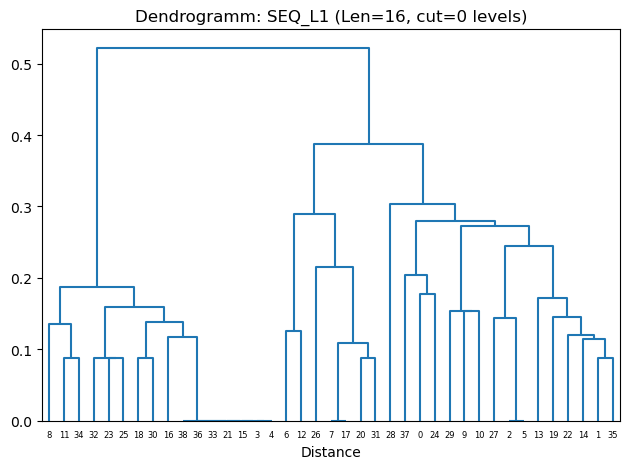


SEQ_L1, Länge 16 → 1 Subgruppen:
  Cluster 1:
    Antigen-Verteilung:
      spike glycoprotein: 8x
      hemagglutinin: 7x
      spike protein s1: 4x
      fusion glycoprotein f0: 2x
      25 kda ookinete surface antigen: 2x
      leukocyte surface antigen cd47: 2x
      circumsporozoite protein: 1x
      envelope glycoprotein h: 1x
      spike protein: 1x
      clade a/e 93th057 hiv-1 gp120 core: 1x
      neuraminidase: 1x
      reticulocyte-binding protein homolog 5: 1x
      glycoprotein 120: 1x
      epidermal growth factor receptor: 1x
      interleukin-17a: 1x
      tumor necrosis factor receptor superfamily member 5: 1x
      cytotoxic t-lymphocyte protein 4: 1x
      envelope glycoprotein b: 1x
      t-cell immunoreceptor with ig and itim domains: 1x
      envelope glycoprotein e2: 1x
    PDB_IDs:
      8tnl
      8bg1
      7rxp
      6iuv
      7e8c
      7pnm
      7t4r
      5a3i
      7wsc
      6c6z
      6oej
      7deo
      7chh
      7e9o
      8zr4
      8us0
      

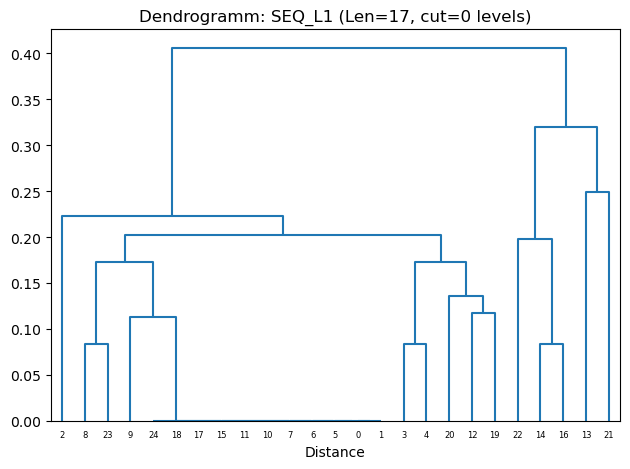


SEQ_L1, Länge 17 → 1 Subgruppen:
  Cluster 1:
    Antigen-Verteilung:
      spike glycoprotein: 8x
      spike protein s1: 5x
      hemagglutinin: 3x
      surface glycoprotein: 2x
      gametocyte surface protein p230: 2x
      tumor necrosis factor receptor superfamily member 5: 2x
      spike protein s2': 1x
      programmed cell death protein 1: 1x
      receptor tyrosine-protein kinase erbb-2: 1x
    PDB_IDs:
      8ekd
      8d48
      7eng
      7mzk
      7kn3
      7k9z
      7czy
      7d0d
      7ps2
      7czx
      7uvs
      7ubs
      8dnn
      8ume
      8suo
      8gf2
      8cwj
      7prz
      7fjo
      6xq4
      6xkr
      6pe9
      6pe8
      6att
      6xpx
    Sequenzen:
      KSSQSVLYAANNKNYLA
      KSSRNVLYSSNNKNYLA
      KSSQSVLYRSNNKNYLA
      KSSQSVLYSSNNKNYLG
      KSSQSVLYSSNNKNYLA
      KSSQSVLYSSNNKNYLA
      KSSQSVLYSSNNKNYLA
      KSSQSVLYSSNNKNYLA
      KSSQSVLYSSNNKNYLA
      KSSQSVLYSSNNKNYLA
      KSSQSVLYSSNNKNYLA
      KSSQSVLYSSNNKNYLA
   

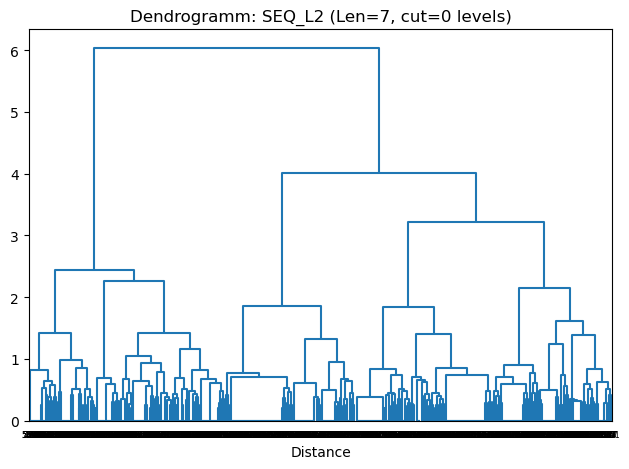


SEQ_L2, Länge 7 → 1 Subgruppen:
  Cluster 1:
    Antigen-Verteilung:
      spike glycoprotein: 211x
      spike protein s1: 179x
      hemagglutinin: 47x
      neuraminidase: 25x
      surface glycoprotein: 25x
      fusion glycoprotein f0: 17x
      gametocyte surface protein p230: 15x
      circumsporozoite protein: 12x
      envelope glycoprotein e2: 12x
      clade a/e 93th057 hiv-1 gp120 core: 11x
      programmed cell death protein 1: 11x
      spike glycoprotein,fibritin: 9x
      envelope glycoprotein gp160: 9x
      receptor tyrosine-protein kinase erbb-2: 8x
      envelope glycoprotein b: 8x
      envelope glycoprotein gp120: 8x
      reticulocyte binding protein 2b: 7x
      interleukin-17a: 7x
      ch848.10.17 gp120: 7x
      leukocyte surface antigen cd47: 7x
      25 kda ookinete surface antigen: 6x
      envelope protein: 6x
      nucleoprotein: 6x
      reticulocyte-binding protein homolog 5: 6x
      epidermal growth factor receptor: 6x
      cytotoxic t-lymphocyte p

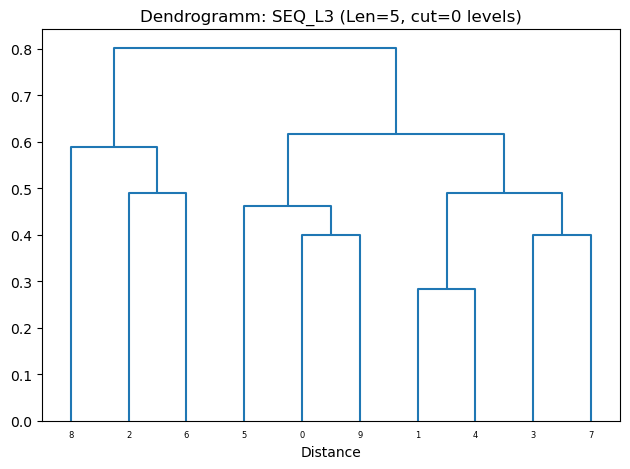


SEQ_L3, Länge 5 → 1 Subgruppen:
  Cluster 1:
    Antigen-Verteilung:
      clade a/e 93th057 hiv-1 gp120 core: 2x
      envelope glycoprotein gp160: 2x
      spike glycoprotein: 2x
      envelope glycoprotein gp120: 1x
      glycoprotein 120: 1x
      spike protein s1: 1x
      hemagglutinin: 1x
    PDB_IDs:
      4jb9
      7ugq
      4ydi
      7rdw
      9cci
      4j6r
      8qh0
      6e4x
      7s6j
      5te6
    Sequenzen:
      QQFEF
      SAFEY
      QVIES
      QHMYT
      QQYDA
      QQYET
      QQGVT
      QQQGT
      QQPLT
      QVLQF

--------------------------------------------------

✅ TSV geschrieben: cdr_cluster_pre_decided_HC_length_tsvs/clusters_SEQ_L3_len8.tsv


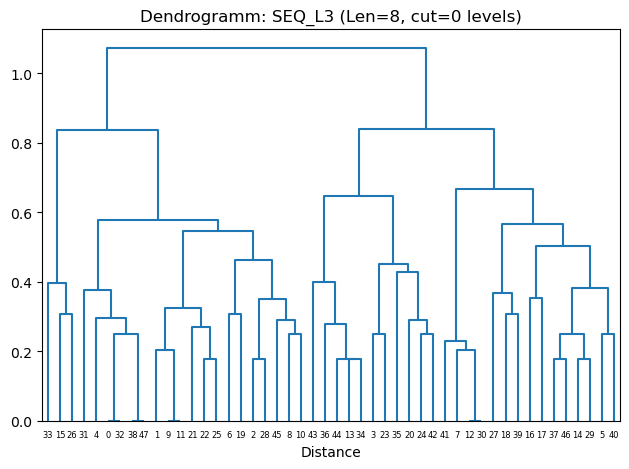


SEQ_L3, Länge 8 → 1 Subgruppen:
  Cluster 1:
    Antigen-Verteilung:
      spike protein s1: 14x
      spike glycoprotein: 10x
      envelope glycoprotein gp160: 3x
      hemagglutinin: 3x
      clade a/e 93th057 hiv-1 gp120 core: 3x
      envelope glycoprotein e2: 2x
      spike protein: 2x
      circumsporozoite protein: 2x
      fusion glycoprotein f0: 1x
      hemagglutinin ha1: 1x
      surface glycoprotein: 1x
      envelope glycoprotein e: 1x
      spike protein s2': 1x
      reticulocyte-binding protein homolog 5: 1x
      tumor necrosis factor receptor superfamily member 5: 1x
      25 kda ookinete surface antigen: 1x
      programmed cell death 1 ligand 1: 1x
    PDB_IDs:
      5t3z
      8eay
      5w08
      7ljr
      8tzy
      9l6c
      6uyg
      7ps1
      7n62
      8v5q
      8suo
      8ekd
      8bbo
      7ul1
      7jmo
      8pwv
      7y6l
      8wyj
      7nx7
      5w42
      8x0y
      8yx1
      6oej
      6phc
      6c6z
      8bg1
      6iuv
      8wyj


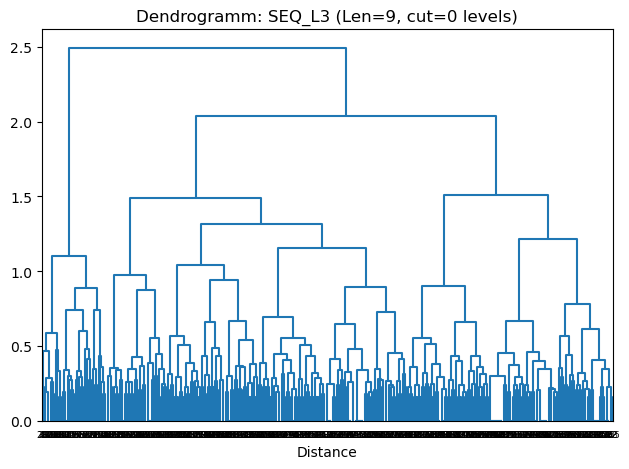


SEQ_L3, Länge 9 → 1 Subgruppen:
  Cluster 1:
    Antigen-Verteilung:
      spike glycoprotein: 122x
      spike protein s1: 85x
      hemagglutinin: 33x
      programmed cell death protein 1: 11x
      surface glycoprotein: 11x
      envelope glycoprotein e2: 10x
      fusion glycoprotein f0: 10x
      neuraminidase: 8x
      gametocyte surface protein p230: 7x
      circumsporozoite protein: 6x
      cytotoxic t-lymphocyte protein 4: 6x
      leukocyte surface antigen cd47: 6x
      receptor tyrosine-protein kinase erbb-2: 6x
      interleukin-17a: 6x
      envelope glycoprotein b: 5x
      spike glycoprotein,fibritin: 5x
      epidermal growth factor receptor: 5x
      spike protein s2': 5x
      genome polyprotein: 4x
      e2 glycoprotein: 4x
      nucleoprotein: 4x
      envelope glycoprotein h: 4x
      vascular endothelial growth factor a: 4x
      histone chaperone asf1: 4x
      reticulocyte-binding protein homolog 5: 4x
      tumor necrosis factor receptor superfamily member

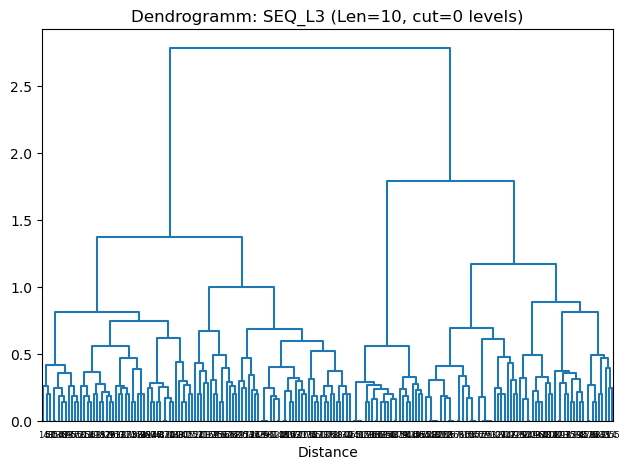


SEQ_L3, Länge 10 → 1 Subgruppen:
  Cluster 1:
    Antigen-Verteilung:
      spike protein s1: 54x
      spike glycoprotein: 38x
      neuraminidase: 14x
      surface glycoprotein: 9x
      gametocyte surface protein p230: 7x
      ch848.10.17 gp120: 7x
      hemagglutinin: 5x
      spike glycoprotein,fibritin: 4x
      ch848.10.17.sosip gp120: 4x
      circumsporozoite protein: 3x
      sars-cov-2 spike glycoprotein: 3x
      25 kda ookinete surface antigen: 2x
      tyrosine-protein phosphatase non-receptor type substrate 1: 2x
      clade a/e 93th057 hiv-1 gp120 core: 2x
      envelope protein e: 2x
      hemagglutinin ha1: 2x
      envelope glycoprotein e: 2x
      envelope glycoprotein gp120: 2x
      envelope protein: 2x
      envelope glycoprotein b: 2x
      programmed cell death 1 ligand 1: 2x
      reticulocyte binding protein 2b: 2x
      fusion glycoprotein f0: 2x
      leukocyte surface antigen cd47: 1x
      cadmium and zinc efflux pump fief: 1x
      reticulocyte-bindin

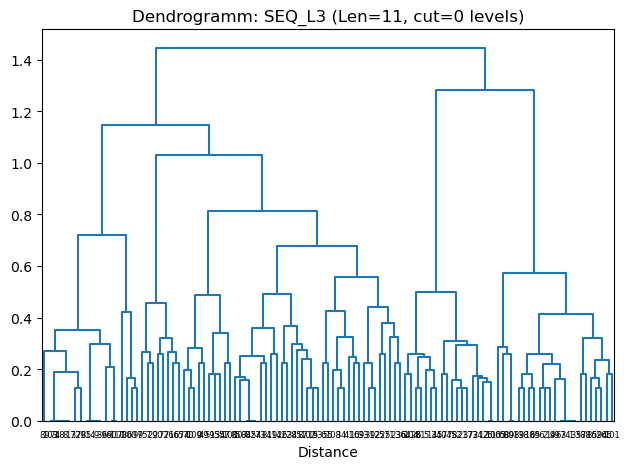


SEQ_L3, Länge 11 → 1 Subgruppen:
  Cluster 1:
    Antigen-Verteilung:
      spike glycoprotein: 39x
      spike protein s1: 25x
      hemagglutinin: 5x
      surface glycoprotein: 4x
      fusion glycoprotein f0: 4x
      envelope glycoprotein gp120: 3x
      neuraminidase: 3x
      reticulocyte binding protein 2b: 3x
      hemagglutinin ha1 chain: 3x
      erythropoietin receptor: 2x
      envelope protein: 2x
      glutamate receptor ionotropic, nmda 1: 1x
      spike protein: 1x
      ig epsilon chain c region: 1x
      tumor necrosis factor ligand superfamily member 13b: 1x
      receptor tyrosine-protein kinase erbb-2: 1x
      programmed cell death 1 ligand 1: 1x
      clade a/e 93th057 hiv-1 gp120 core: 1x
      envelope glycoprotein gp160: 1x
      envelope glycoprotein b: 1x
      tumor necrosis factor receptor superfamily member 9: 1x
      interleukin-17a: 1x
      nucleoprotein: 1x
      gametocyte surface protein p230: 1x
      25 kda ookinete surface antigen: 1x
      re

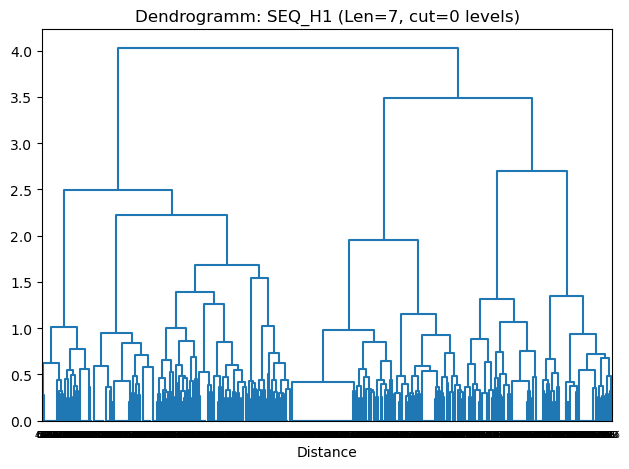


SEQ_H1, Länge 7 → 1 Subgruppen:
  Cluster 1:
    Antigen-Verteilung:
      spike glycoprotein: 192x
      spike protein s1: 166x
      hemagglutinin: 36x
      surface glycoprotein: 21x
      neuraminidase: 19x
      fusion glycoprotein f0: 15x
      gametocyte surface protein p230: 14x
      circumsporozoite protein: 12x
      envelope glycoprotein e2: 12x
      programmed cell death protein 1: 11x
      clade a/e 93th057 hiv-1 gp120 core: 10x
      envelope glycoprotein gp160: 8x
      receptor tyrosine-protein kinase erbb-2: 8x
      spike glycoprotein,fibritin: 8x
      ch848.10.17 gp120: 7x
      envelope glycoprotein gp120: 7x
      leukocyte surface antigen cd47: 7x
      envelope glycoprotein b: 7x
      interleukin-17a: 7x
      reticulocyte binding protein 2b: 7x
      reticulocyte-binding protein homolog 5: 6x
      cytotoxic t-lymphocyte protein 4: 6x
      programmed cell death 1 ligand 1: 6x
      nucleoprotein: 6x
      spike protein s2': 5x
      sars-cov-2 spike glyco

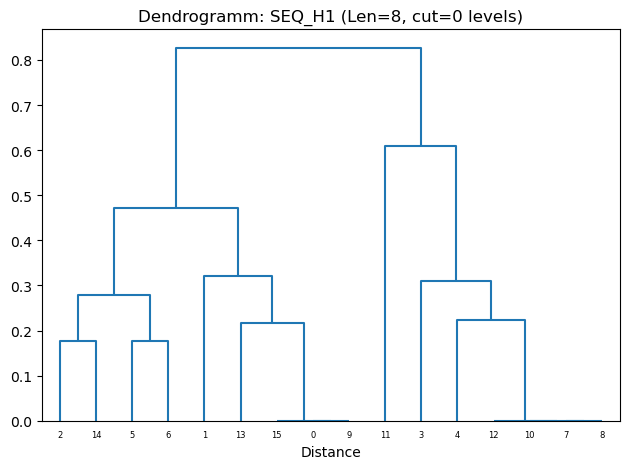


SEQ_H1, Länge 8 → 1 Subgruppen:
  Cluster 1:
    Antigen-Verteilung:
      spike protein s1: 3x
      ige fc: 3x
      25 kda ookinete surface antigen: 1x
      hemagglutinin: 1x
      hemagglutinin ha1 chain: 1x
      envelope glycoprotein gp160: 1x
      glutamate receptor ionotropic, nmda 1: 1x
      genome polyprotein: 1x
      envelope glycoprotein gp120: 1x
      spike glycoprotein: 1x
      gametocyte surface protein p230: 1x
      neuraminidase: 1x
    PDB_IDs:
      8ezk
      4xnm
      8dcc
      4m5z
      8x0y
      7wph
      6dfh
      8vuj
      5gzo
      7kde
      7xdl
      7uvq
      7shz
      6pzy
      7shy
      7si0
    Sequenzen:
      GFSISSSY
      GGSISSSY
      GYSISSGY
      GYSISSNY
      GASISSGD
      GGSISSNN
      GGSISSSN
      GGSISSSN
      GGSISSSN
      GYNIRSNN
      GYSFTSYY
      GYSITSDY
      GYSITSGY
      GYTISSGY
      GYSITSGY
      GYSITSGY

--------------------------------------------------

✅ TSV geschrieben: cdr_cluster_pre_decide

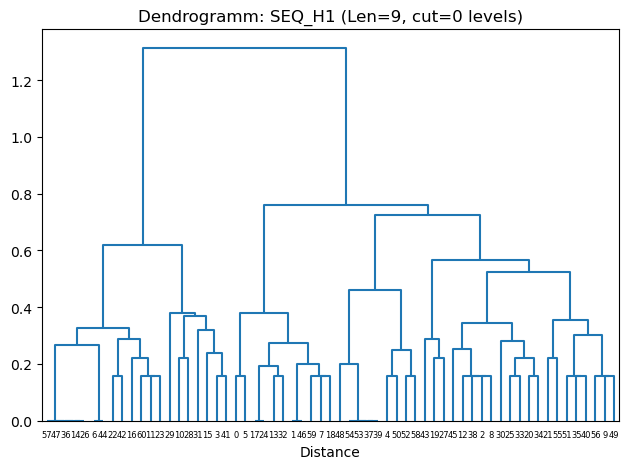


SEQ_H1, Länge 9 → 1 Subgruppen:
  Cluster 1:
    Antigen-Verteilung:
      spike glycoprotein: 18x
      spike protein s1: 10x
      hemagglutinin: 10x
      neuraminidase: 5x
      surface glycoprotein: 4x
      epidermal growth factor receptor: 3x
      fusion glycoprotein f0: 2x
      spike protein s2': 1x
      envelope glycoprotein b: 1x
      pre-glycoprotein polyprotein gp complex: 1x
      clade a/e 93th057 hiv-1 gp120 core: 1x
      tumor necrosis factor receptor superfamily member 5: 1x
      envelope protein: 1x
      spike glycoprotein,fibritin: 1x
      envelope glycoprotein e: 1x
      e2 glycoprotein: 1x
    PDB_IDs:
      7lss
      7cm4
      7d0d
      8hp9
      7xsa
      8rgz
      6urm
      7yve
      7mmo
      7ycy
      7t01
      8gdr
      7yvk
      7wrj
      8vye
      8erq
      8cw9
      8tma
      9bdf
      7wee
      8veb
      8zho
      8tp6
      8eoo
      8cbd
      7bel
      8vef
      5w1k
      5kjr
      8yx1
      8tp7
      7pry
      7

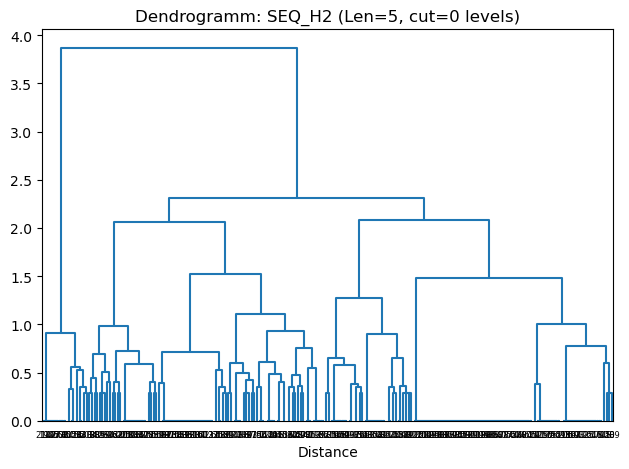


SEQ_H2, Länge 5 → 1 Subgruppen:
  Cluster 1:
    Antigen-Verteilung:
      spike protein s1: 67x
      spike glycoprotein: 58x
      hemagglutinin: 23x
      surface glycoprotein: 14x
      neuraminidase: 8x
      fusion glycoprotein f0: 5x
      spike protein s2': 4x
      epidermal growth factor receptor: 4x
      nucleoprotein: 3x
      ige fc: 3x
      spike glycoprotein,fibritin: 3x
      gametocyte surface protein p230: 2x
      25 kda ookinete surface antigen: 2x
      envelope glycoprotein e: 2x
      envelope glycoprotein e2: 2x
      reticulocyte-binding protein homolog 5: 2x
      envelope glycoprotein b: 1x
      cytotoxic t-lymphocyte protein 4: 1x
      hemagglutinin ha1: 1x
      envelope glycoprotein h: 1x
      e2 glycoprotein: 1x
      glycoprotein 120: 1x
      programmed cell death 1 ligand 1: 1x
      tumor necrosis factor receptor superfamily member 5: 1x
      envelope protein e: 1x
      programmed cell death protein 1: 1x
      pre-glycoprotein polyprotein gp 

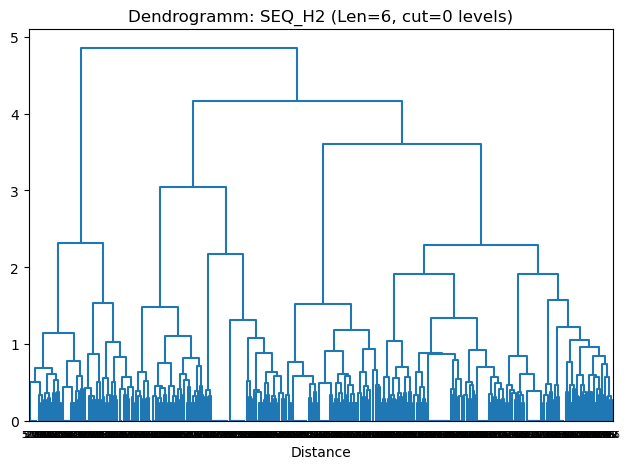


SEQ_H2, Länge 6 → 1 Subgruppen:
  Cluster 1:
    Antigen-Verteilung:
      spike glycoprotein: 145x
      spike protein s1: 109x
      hemagglutinin: 23x
      neuraminidase: 17x
      gametocyte surface protein p230: 13x
      fusion glycoprotein f0: 12x
      surface glycoprotein: 11x
      circumsporozoite protein: 11x
      envelope glycoprotein e2: 10x
      clade a/e 93th057 hiv-1 gp120 core: 10x
      programmed cell death protein 1: 10x
      envelope glycoprotein gp120: 8x
      envelope glycoprotein gp160: 8x
      receptor tyrosine-protein kinase erbb-2: 8x
      ch848.10.17 gp120: 7x
      interleukin-17a: 7x
      envelope glycoprotein b: 7x
      leukocyte surface antigen cd47: 7x
      spike glycoprotein,fibritin: 6x
      reticulocyte binding protein 2b: 6x
      envelope protein: 5x
      programmed cell death 1 ligand 1: 5x
      sars-cov-2 spike glycoprotein: 5x
      cytotoxic t-lymphocyte protein 4: 5x
      spike protein: 4x
      reticulocyte-binding protein hom

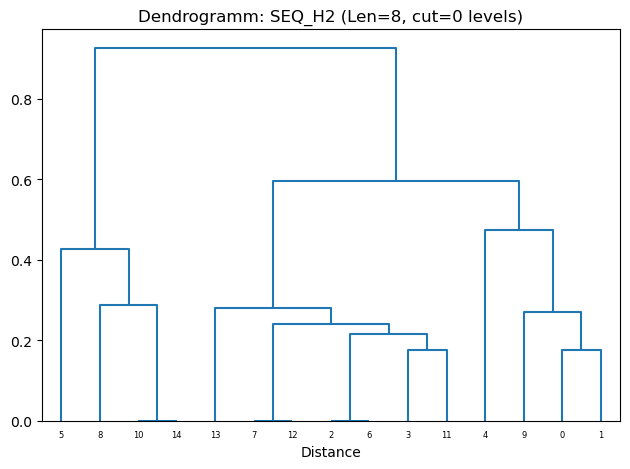


SEQ_H2, Länge 8 → 1 Subgruppen:
  Cluster 1:
    Antigen-Verteilung:
      spike glycoprotein: 8x
      spike protein s1: 3x
      envelope glycoprotein h: 1x
      spike protein s2': 1x
      circumsporozoite protein: 1x
      hemagglutinin: 1x
    PDB_IDs:
      8sdg
      7s07
      7ls9
      7kzb
      7ey5
      7x8y
      7jx3
      8suo
      8ekd
      8r8k
      7mzj
      8khc
      6o2b
      8ghk
      8jmm
    Sequenzen:
      SSNVNNDA
      RNKENSFT
      RNKANSYT
      RNKANSYT
      KSKADGQT
      KSKTDGGT
      KSKTDGGT
      KSKIDGGT
      KSKIDGGT
      KSKADGGT
      KRKSDGGT
      SSEIGGGT
      RSKANGGR
      RTKGNSYA
      RSKAYGGT

--------------------------------------------------

✅ TSV geschrieben: cdr_cluster_pre_decided_HC_length_tsvs/clusters_SEQ_L1_len10.tsv


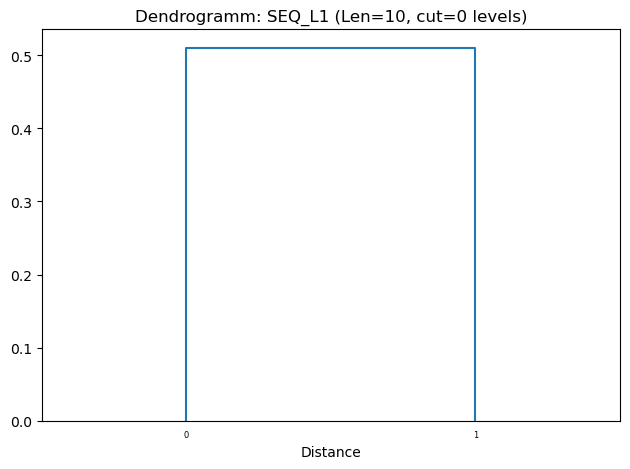


SEQ_L1, Länge 10 → 1 Subgruppen:
  Cluster 1:
    Antigen-Verteilung:
      gametocyte surface protein p230: 1x
      clade a/e 93th057 hiv-1 gp120 core: 1x
    PDB_IDs:
      7uvq
      4jb9
    Sequenzen:
      SASSSVSYMY
      RASQGGNSLN

--------------------------------------------------

✅ TSV geschrieben: cdr_cluster_pre_decided_HC_length_tsvs/clusters_SEQ_L1_len11.tsv


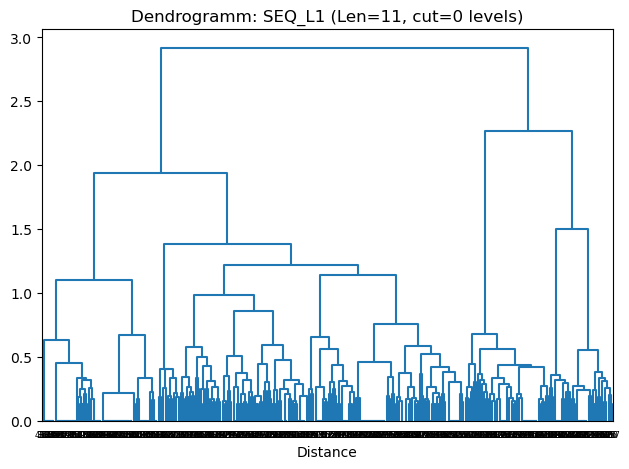


SEQ_L1, Länge 11 → 1 Subgruppen:
  Cluster 1:
    Antigen-Verteilung:
      spike glycoprotein: 107x
      spike protein s1: 94x
      hemagglutinin: 24x
      neuraminidase: 14x
      surface glycoprotein: 13x
      fusion glycoprotein f0: 12x
      programmed cell death protein 1: 9x
      circumsporozoite protein: 9x
      gametocyte surface protein p230: 9x
      envelope glycoprotein e2: 6x
      clade a/e 93th057 hiv-1 gp120 core: 6x
      envelope glycoprotein gp160: 6x
      epidermal growth factor receptor: 5x
      receptor tyrosine-protein kinase erbb-2: 5x
      reticulocyte-binding protein homolog 5: 5x
      reticulocyte binding protein 2b: 5x
      hemagglutinin ha1 chain: 5x
      histone chaperone asf1: 4x
      spike protein: 4x
      tumor necrosis factor receptor superfamily member 9: 4x
      leukocyte surface antigen cd47: 4x
      spike protein s2': 4x
      envelope glycoprotein b: 4x
      genome polyprotein: 4x
      nucleoprotein: 3x
      arginase-1: 3x
   

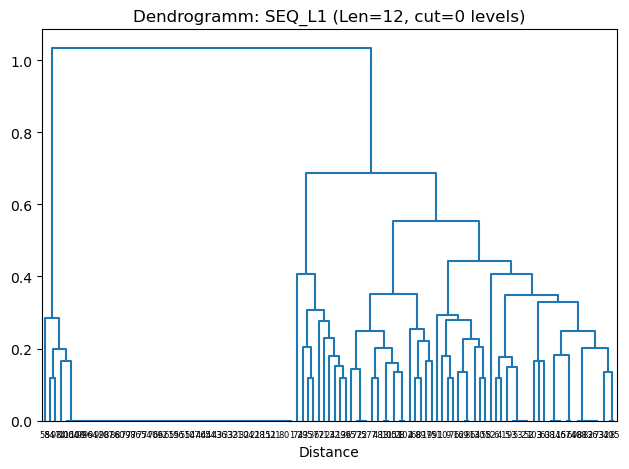


SEQ_L1, Länge 12 → 1 Subgruppen:
  Cluster 1:
    Antigen-Verteilung:
      spike glycoprotein: 32x
      spike protein s1: 29x
      surface glycoprotein: 7x
      envelope glycoprotein e2: 5x
      hemagglutinin: 3x
      spike glycoprotein,fibritin: 3x
      cytotoxic t-lymphocyte protein 4: 3x
      neuraminidase: 3x
      circumsporozoite protein: 2x
      glycoprotein 120: 2x
      t-cell immunoreceptor with ig and itim domains: 1x
      sars-cov-2 spike glycoprotein: 1x
      pre-glycoprotein polyprotein gp complex: 1x
      interleukin-17a: 1x
      nucleoprotein: 1x
      leukocyte surface antigen cd47: 1x
      hemagglutinin ha1: 1x
      vascular endothelial growth factor a: 1x
      spike protein s2': 1x
      envelope glycoprotein gp120: 1x
      envelope glycoprotein h: 1x
      transforming growth factor beta-2: 1x
      envelope glycoprotein gp160: 1x
      envelope protein: 1x
      interferon alpha-2: 1x
      clade a/e 93th057 hiv-1 gp120 core: 1x
      programmed c

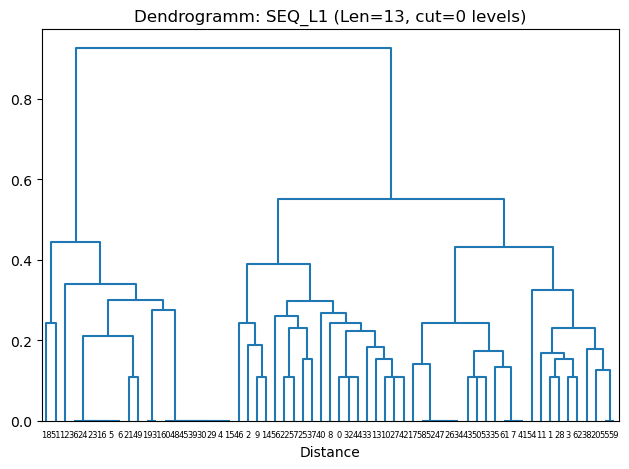


SEQ_L1, Länge 13 → 1 Subgruppen:
  Cluster 1:
    Antigen-Verteilung:
      spike glycoprotein: 22x
      spike protein s1: 13x
      hemagglutinin: 6x
      neuraminidase: 3x
      envelope glycoprotein b: 3x
      envelope glycoprotein gp120: 2x
      interleukin-17a: 2x
      envelope protein: 2x
      programmed cell death 1 ligand 1: 1x
      sars-cov-2 spike glycoprotein: 1x
      spike glycoprotein,fibritin,expression tag: 1x
      glutamate receptor ionotropic, nmda 1: 1x
      receptor tyrosine-protein kinase erbb-2: 1x
      gametocyte surface protein p230: 1x
      surface glycoprotein: 1x
      erythropoietin receptor: 1x
      25 kda ookinete surface antigen: 1x
      nucleoprotein: 1x
    PDB_IDs:
      7xsb
      7kde
      7yds
      7jva
      7ycn
      7yck
      7vzt
      8zhe
      8zho
      7u0x
      7m7b
      8dy1
      2vxs
      6ii4
      7ttx
      7jx3
      6ii8
      7wog
      7wo4
      8vuj
      8eoo
      3wsq
      9dwe
      8zby
      7yve
   

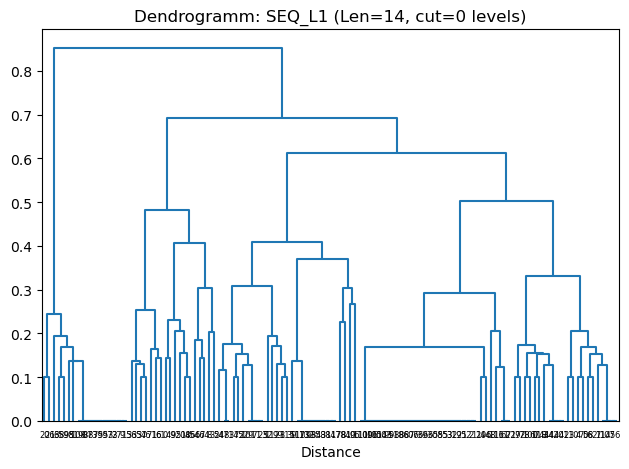


SEQ_L1, Länge 14 → 1 Subgruppen:
  Cluster 1:
    Antigen-Verteilung:
      spike protein s1: 34x
      spike glycoprotein: 31x
      ch848.10.17 gp120: 7x
      hemagglutinin: 4x
      ch848.10.17.sosip gp120: 4x
      neuraminidase: 4x
      fusion glycoprotein f0: 3x
      spike glycoprotein,fibritin: 3x
      envelope glycoprotein gp120: 3x
      reticulocyte binding protein 2b: 2x
      envelope glycoprotein e: 2x
      surface glycoprotein: 2x
      clade a/e 93th057 hiv-1 gp120 core: 2x
      spike glycoprotein,fibritin,expression tag: 2x
      sars-cov-2 spike glycoprotein: 2x
      programmed cell death 1 ligand 1: 2x
      envelope glycoprotein gp160: 2x
      erythropoietin receptor: 2x
      ig epsilon chain c region: 1x
      hemagglutinin ha1: 1x
      gametocyte surface protein p230: 1x
      e2 glycoprotein: 1x
      envelope protein: 1x
      envelope protein e: 1x
      receptor tyrosine-protein kinase erbb-2: 1x
      nucleoprotein: 1x
    PDB_IDs:
      8hrd
      

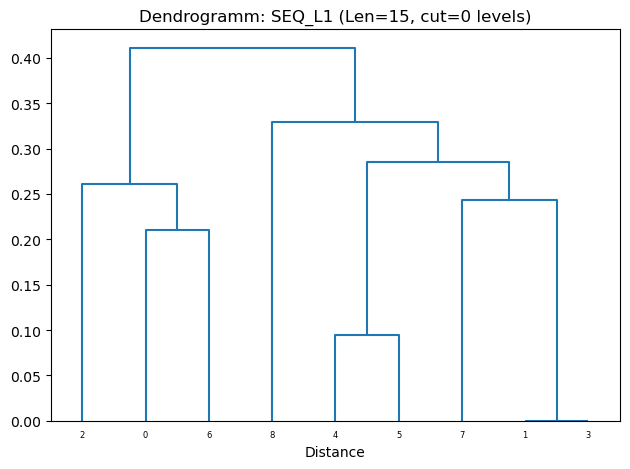


SEQ_L1, Länge 15 → 1 Subgruppen:
  Cluster 1:
    Antigen-Verteilung:
      spike glycoprotein: 3x
      ige fc: 3x
      interferon alpha-2: 1x
      programmed cell death protein 1: 1x
      25 kda ookinete surface antigen: 1x
    PDB_IDs:
      4z5r
      7mw6
      5ggs
      6phc
      7shy
      7si0
      7shz
      7mw3
      7e5s
    Sequenzen:
      RASQSVSTSSYSYMH
      RASESVEYYGTSLMQ
      RASKGVSTSGYSYLH
      RSSQSLLHNGYNYLD
      RASQSVDYDGDSYMN
      RASQSVDSDGDSYMN
      RASKPVDGEGDSYLN
      RASESVDNYGISFMN
      RASESVDNYGISFMN

--------------------------------------------------

✅ TSV geschrieben: cdr_cluster_pre_decided_HC_length_tsvs/clusters_SEQ_L1_len16.tsv


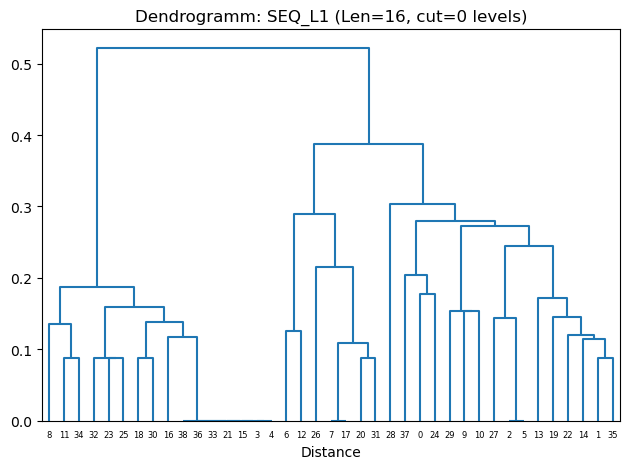


SEQ_L1, Länge 16 → 1 Subgruppen:
  Cluster 1:
    Antigen-Verteilung:
      spike glycoprotein: 8x
      hemagglutinin: 7x
      spike protein s1: 4x
      fusion glycoprotein f0: 2x
      25 kda ookinete surface antigen: 2x
      leukocyte surface antigen cd47: 2x
      circumsporozoite protein: 1x
      envelope glycoprotein h: 1x
      spike protein: 1x
      clade a/e 93th057 hiv-1 gp120 core: 1x
      neuraminidase: 1x
      reticulocyte-binding protein homolog 5: 1x
      glycoprotein 120: 1x
      epidermal growth factor receptor: 1x
      interleukin-17a: 1x
      tumor necrosis factor receptor superfamily member 5: 1x
      cytotoxic t-lymphocyte protein 4: 1x
      envelope glycoprotein b: 1x
      t-cell immunoreceptor with ig and itim domains: 1x
      envelope glycoprotein e2: 1x
    PDB_IDs:
      8tnl
      8bg1
      7rxp
      6iuv
      7e8c
      7pnm
      7t4r
      5a3i
      7wsc
      6c6z
      6oej
      7deo
      7chh
      7e9o
      8zr4
      8us0
      

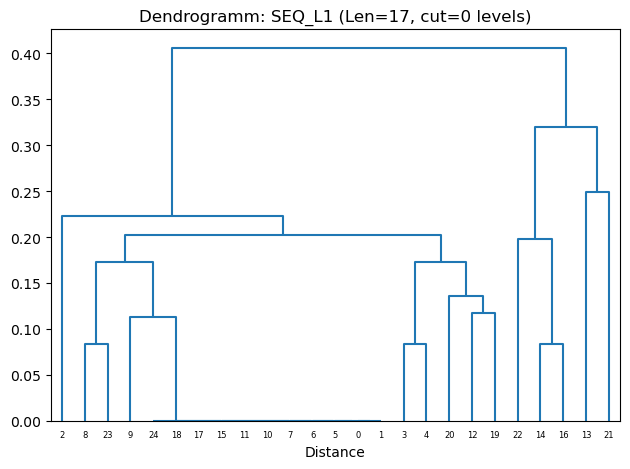


SEQ_L1, Länge 17 → 1 Subgruppen:
  Cluster 1:
    Antigen-Verteilung:
      spike glycoprotein: 8x
      spike protein s1: 5x
      hemagglutinin: 3x
      surface glycoprotein: 2x
      gametocyte surface protein p230: 2x
      tumor necrosis factor receptor superfamily member 5: 2x
      spike protein s2': 1x
      programmed cell death protein 1: 1x
      receptor tyrosine-protein kinase erbb-2: 1x
    PDB_IDs:
      8ekd
      8d48
      7eng
      7mzk
      7kn3
      7k9z
      7czy
      7d0d
      7ps2
      7czx
      7uvs
      7ubs
      8dnn
      8ume
      8suo
      8gf2
      8cwj
      7prz
      7fjo
      6xq4
      6xkr
      6pe9
      6pe8
      6att
      6xpx
    Sequenzen:
      KSSQSVLYAANNKNYLA
      KSSRNVLYSSNNKNYLA
      KSSQSVLYRSNNKNYLA
      KSSQSVLYSSNNKNYLG
      KSSQSVLYSSNNKNYLA
      KSSQSVLYSSNNKNYLA
      KSSQSVLYSSNNKNYLA
      KSSQSVLYSSNNKNYLA
      KSSQSVLYSSNNKNYLA
      KSSQSVLYSSNNKNYLA
      KSSQSVLYSSNNKNYLA
      KSSQSVLYSSNNKNYLA
   

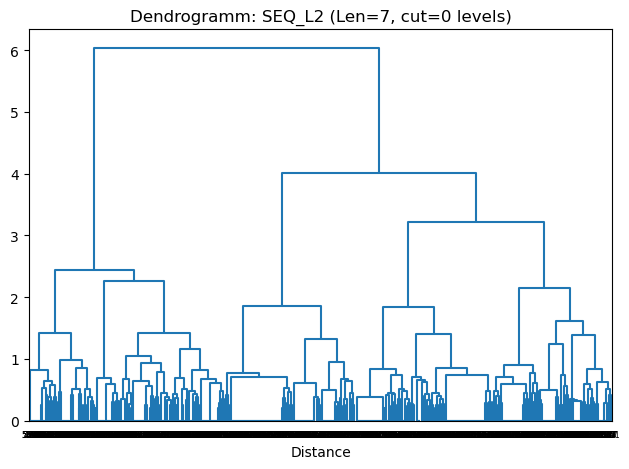


SEQ_L2, Länge 7 → 1 Subgruppen:
  Cluster 1:
    Antigen-Verteilung:
      spike glycoprotein: 211x
      spike protein s1: 179x
      hemagglutinin: 47x
      neuraminidase: 25x
      surface glycoprotein: 25x
      fusion glycoprotein f0: 17x
      gametocyte surface protein p230: 15x
      circumsporozoite protein: 12x
      envelope glycoprotein e2: 12x
      clade a/e 93th057 hiv-1 gp120 core: 11x
      programmed cell death protein 1: 11x
      spike glycoprotein,fibritin: 9x
      envelope glycoprotein gp160: 9x
      receptor tyrosine-protein kinase erbb-2: 8x
      envelope glycoprotein b: 8x
      envelope glycoprotein gp120: 8x
      reticulocyte binding protein 2b: 7x
      interleukin-17a: 7x
      ch848.10.17 gp120: 7x
      leukocyte surface antigen cd47: 7x
      25 kda ookinete surface antigen: 6x
      envelope protein: 6x
      nucleoprotein: 6x
      reticulocyte-binding protein homolog 5: 6x
      epidermal growth factor receptor: 6x
      cytotoxic t-lymphocyte p

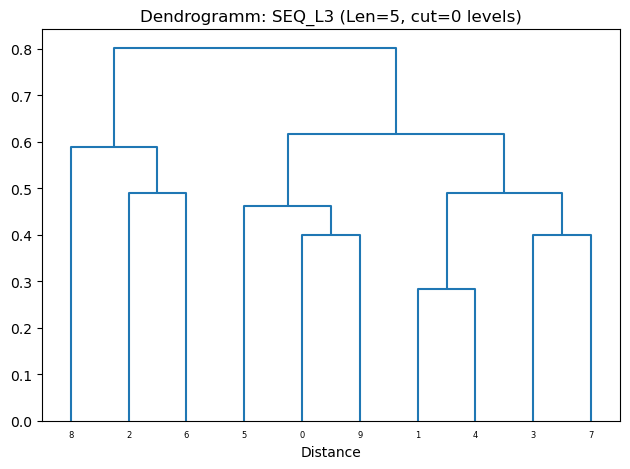


SEQ_L3, Länge 5 → 1 Subgruppen:
  Cluster 1:
    Antigen-Verteilung:
      clade a/e 93th057 hiv-1 gp120 core: 2x
      envelope glycoprotein gp160: 2x
      spike glycoprotein: 2x
      envelope glycoprotein gp120: 1x
      glycoprotein 120: 1x
      spike protein s1: 1x
      hemagglutinin: 1x
    PDB_IDs:
      4jb9
      7ugq
      4ydi
      7rdw
      9cci
      4j6r
      8qh0
      6e4x
      7s6j
      5te6
    Sequenzen:
      QQFEF
      SAFEY
      QVIES
      QHMYT
      QQYDA
      QQYET
      QQGVT
      QQQGT
      QQPLT
      QVLQF

--------------------------------------------------

✅ TSV geschrieben: cdr_cluster_pre_decided_HC_length_tsvs/clusters_SEQ_L3_len8.tsv


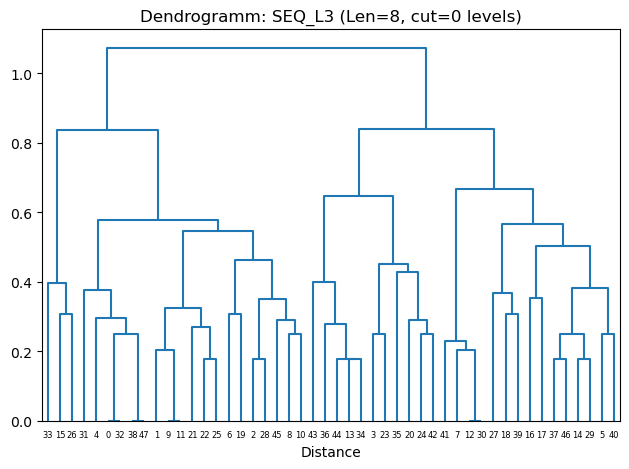


SEQ_L3, Länge 8 → 1 Subgruppen:
  Cluster 1:
    Antigen-Verteilung:
      spike protein s1: 14x
      spike glycoprotein: 10x
      envelope glycoprotein gp160: 3x
      hemagglutinin: 3x
      clade a/e 93th057 hiv-1 gp120 core: 3x
      envelope glycoprotein e2: 2x
      spike protein: 2x
      circumsporozoite protein: 2x
      fusion glycoprotein f0: 1x
      hemagglutinin ha1: 1x
      surface glycoprotein: 1x
      envelope glycoprotein e: 1x
      spike protein s2': 1x
      reticulocyte-binding protein homolog 5: 1x
      tumor necrosis factor receptor superfamily member 5: 1x
      25 kda ookinete surface antigen: 1x
      programmed cell death 1 ligand 1: 1x
    PDB_IDs:
      5t3z
      8eay
      5w08
      7ljr
      8tzy
      9l6c
      6uyg
      7ps1
      7n62
      8v5q
      8suo
      8ekd
      8bbo
      7ul1
      7jmo
      8pwv
      7y6l
      8wyj
      7nx7
      5w42
      8x0y
      8yx1
      6oej
      6phc
      6c6z
      8bg1
      6iuv
      8wyj


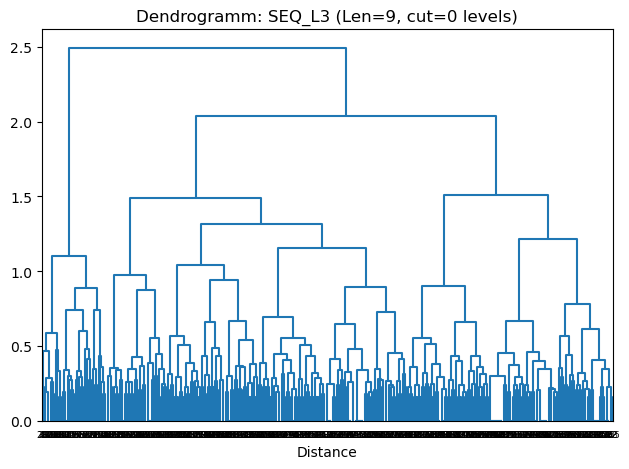


SEQ_L3, Länge 9 → 1 Subgruppen:
  Cluster 1:
    Antigen-Verteilung:
      spike glycoprotein: 122x
      spike protein s1: 85x
      hemagglutinin: 33x
      programmed cell death protein 1: 11x
      surface glycoprotein: 11x
      envelope glycoprotein e2: 10x
      fusion glycoprotein f0: 10x
      neuraminidase: 8x
      gametocyte surface protein p230: 7x
      circumsporozoite protein: 6x
      cytotoxic t-lymphocyte protein 4: 6x
      leukocyte surface antigen cd47: 6x
      receptor tyrosine-protein kinase erbb-2: 6x
      interleukin-17a: 6x
      envelope glycoprotein b: 5x
      spike glycoprotein,fibritin: 5x
      epidermal growth factor receptor: 5x
      spike protein s2': 5x
      genome polyprotein: 4x
      e2 glycoprotein: 4x
      nucleoprotein: 4x
      envelope glycoprotein h: 4x
      vascular endothelial growth factor a: 4x
      histone chaperone asf1: 4x
      reticulocyte-binding protein homolog 5: 4x
      tumor necrosis factor receptor superfamily member

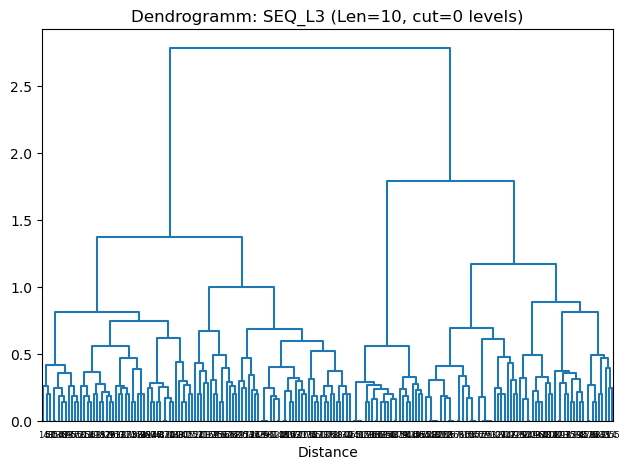


SEQ_L3, Länge 10 → 1 Subgruppen:
  Cluster 1:
    Antigen-Verteilung:
      spike protein s1: 54x
      spike glycoprotein: 38x
      neuraminidase: 14x
      surface glycoprotein: 9x
      gametocyte surface protein p230: 7x
      ch848.10.17 gp120: 7x
      hemagglutinin: 5x
      spike glycoprotein,fibritin: 4x
      ch848.10.17.sosip gp120: 4x
      circumsporozoite protein: 3x
      sars-cov-2 spike glycoprotein: 3x
      25 kda ookinete surface antigen: 2x
      tyrosine-protein phosphatase non-receptor type substrate 1: 2x
      clade a/e 93th057 hiv-1 gp120 core: 2x
      envelope protein e: 2x
      hemagglutinin ha1: 2x
      envelope glycoprotein e: 2x
      envelope glycoprotein gp120: 2x
      envelope protein: 2x
      envelope glycoprotein b: 2x
      programmed cell death 1 ligand 1: 2x
      reticulocyte binding protein 2b: 2x
      fusion glycoprotein f0: 2x
      leukocyte surface antigen cd47: 1x
      cadmium and zinc efflux pump fief: 1x
      reticulocyte-bindin

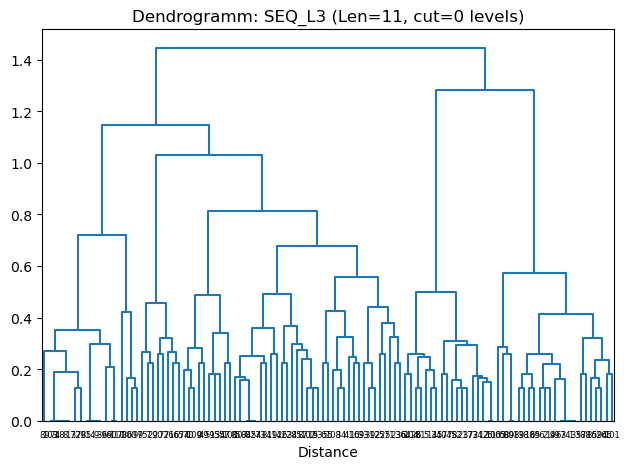


SEQ_L3, Länge 11 → 1 Subgruppen:
  Cluster 1:
    Antigen-Verteilung:
      spike glycoprotein: 39x
      spike protein s1: 25x
      hemagglutinin: 5x
      surface glycoprotein: 4x
      fusion glycoprotein f0: 4x
      envelope glycoprotein gp120: 3x
      neuraminidase: 3x
      reticulocyte binding protein 2b: 3x
      hemagglutinin ha1 chain: 3x
      erythropoietin receptor: 2x
      envelope protein: 2x
      glutamate receptor ionotropic, nmda 1: 1x
      spike protein: 1x
      ig epsilon chain c region: 1x
      tumor necrosis factor ligand superfamily member 13b: 1x
      receptor tyrosine-protein kinase erbb-2: 1x
      programmed cell death 1 ligand 1: 1x
      clade a/e 93th057 hiv-1 gp120 core: 1x
      envelope glycoprotein gp160: 1x
      envelope glycoprotein b: 1x
      tumor necrosis factor receptor superfamily member 9: 1x
      interleukin-17a: 1x
      nucleoprotein: 1x
      gametocyte surface protein p230: 1x
      25 kda ookinete surface antigen: 1x
      re

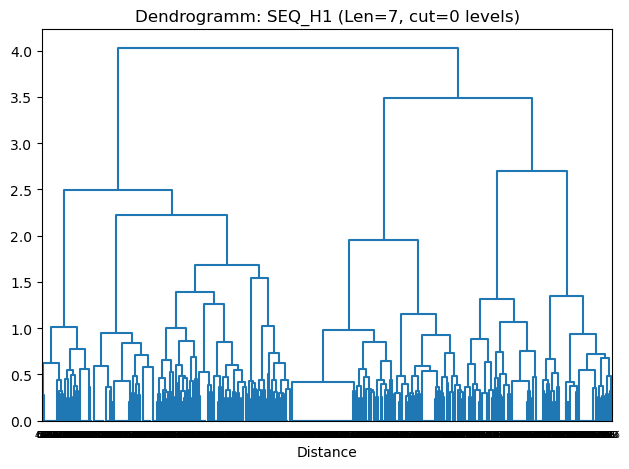


SEQ_H1, Länge 7 → 1 Subgruppen:
  Cluster 1:
    Antigen-Verteilung:
      spike glycoprotein: 192x
      spike protein s1: 166x
      hemagglutinin: 36x
      surface glycoprotein: 21x
      neuraminidase: 19x
      fusion glycoprotein f0: 15x
      gametocyte surface protein p230: 14x
      circumsporozoite protein: 12x
      envelope glycoprotein e2: 12x
      programmed cell death protein 1: 11x
      clade a/e 93th057 hiv-1 gp120 core: 10x
      envelope glycoprotein gp160: 8x
      receptor tyrosine-protein kinase erbb-2: 8x
      spike glycoprotein,fibritin: 8x
      ch848.10.17 gp120: 7x
      envelope glycoprotein gp120: 7x
      leukocyte surface antigen cd47: 7x
      envelope glycoprotein b: 7x
      interleukin-17a: 7x
      reticulocyte binding protein 2b: 7x
      reticulocyte-binding protein homolog 5: 6x
      cytotoxic t-lymphocyte protein 4: 6x
      programmed cell death 1 ligand 1: 6x
      nucleoprotein: 6x
      spike protein s2': 5x
      sars-cov-2 spike glyco

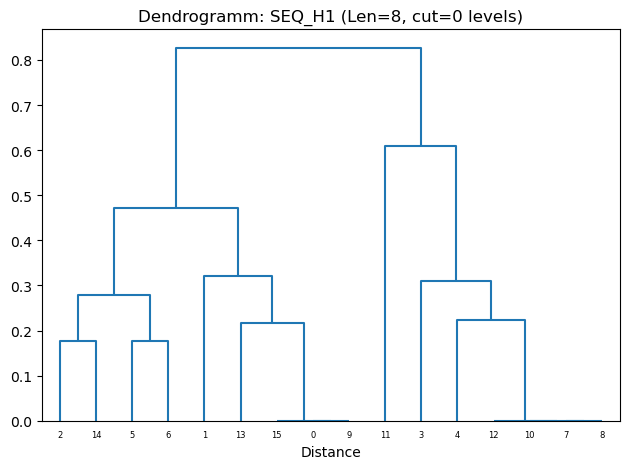


SEQ_H1, Länge 8 → 1 Subgruppen:
  Cluster 1:
    Antigen-Verteilung:
      spike protein s1: 3x
      ige fc: 3x
      25 kda ookinete surface antigen: 1x
      hemagglutinin: 1x
      hemagglutinin ha1 chain: 1x
      envelope glycoprotein gp160: 1x
      glutamate receptor ionotropic, nmda 1: 1x
      genome polyprotein: 1x
      envelope glycoprotein gp120: 1x
      spike glycoprotein: 1x
      gametocyte surface protein p230: 1x
      neuraminidase: 1x
    PDB_IDs:
      8ezk
      4xnm
      8dcc
      4m5z
      8x0y
      7wph
      6dfh
      8vuj
      5gzo
      7kde
      7xdl
      7uvq
      7shz
      6pzy
      7shy
      7si0
    Sequenzen:
      GFSISSSY
      GGSISSSY
      GYSISSGY
      GYSISSNY
      GASISSGD
      GGSISSNN
      GGSISSSN
      GGSISSSN
      GGSISSSN
      GYNIRSNN
      GYSFTSYY
      GYSITSDY
      GYSITSGY
      GYTISSGY
      GYSITSGY
      GYSITSGY

--------------------------------------------------

✅ TSV geschrieben: cdr_cluster_pre_decide

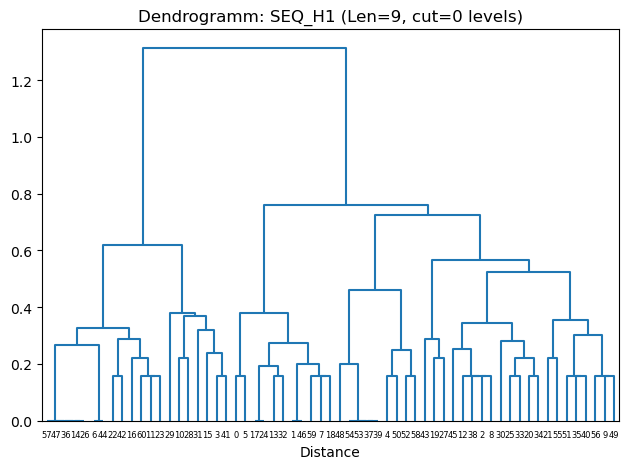


SEQ_H1, Länge 9 → 1 Subgruppen:
  Cluster 1:
    Antigen-Verteilung:
      spike glycoprotein: 18x
      spike protein s1: 10x
      hemagglutinin: 10x
      neuraminidase: 5x
      surface glycoprotein: 4x
      epidermal growth factor receptor: 3x
      fusion glycoprotein f0: 2x
      spike protein s2': 1x
      envelope glycoprotein b: 1x
      pre-glycoprotein polyprotein gp complex: 1x
      clade a/e 93th057 hiv-1 gp120 core: 1x
      tumor necrosis factor receptor superfamily member 5: 1x
      envelope protein: 1x
      spike glycoprotein,fibritin: 1x
      envelope glycoprotein e: 1x
      e2 glycoprotein: 1x
    PDB_IDs:
      7lss
      7cm4
      7d0d
      8hp9
      7xsa
      8rgz
      6urm
      7yve
      7mmo
      7ycy
      7t01
      8gdr
      7yvk
      7wrj
      8vye
      8erq
      8cw9
      8tma
      9bdf
      7wee
      8veb
      8zho
      8tp6
      8eoo
      8cbd
      7bel
      8vef
      5w1k
      5kjr
      8yx1
      8tp7
      7pry
      7

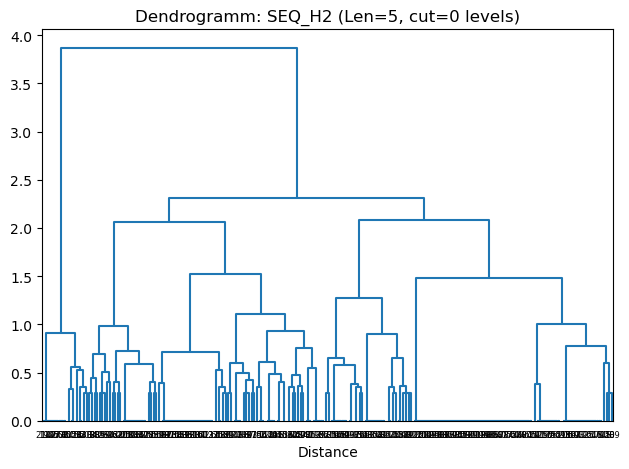


SEQ_H2, Länge 5 → 1 Subgruppen:
  Cluster 1:
    Antigen-Verteilung:
      spike protein s1: 67x
      spike glycoprotein: 58x
      hemagglutinin: 23x
      surface glycoprotein: 14x
      neuraminidase: 8x
      fusion glycoprotein f0: 5x
      spike protein s2': 4x
      epidermal growth factor receptor: 4x
      nucleoprotein: 3x
      ige fc: 3x
      spike glycoprotein,fibritin: 3x
      gametocyte surface protein p230: 2x
      25 kda ookinete surface antigen: 2x
      envelope glycoprotein e: 2x
      envelope glycoprotein e2: 2x
      reticulocyte-binding protein homolog 5: 2x
      envelope glycoprotein b: 1x
      cytotoxic t-lymphocyte protein 4: 1x
      hemagglutinin ha1: 1x
      envelope glycoprotein h: 1x
      e2 glycoprotein: 1x
      glycoprotein 120: 1x
      programmed cell death 1 ligand 1: 1x
      tumor necrosis factor receptor superfamily member 5: 1x
      envelope protein e: 1x
      programmed cell death protein 1: 1x
      pre-glycoprotein polyprotein gp 

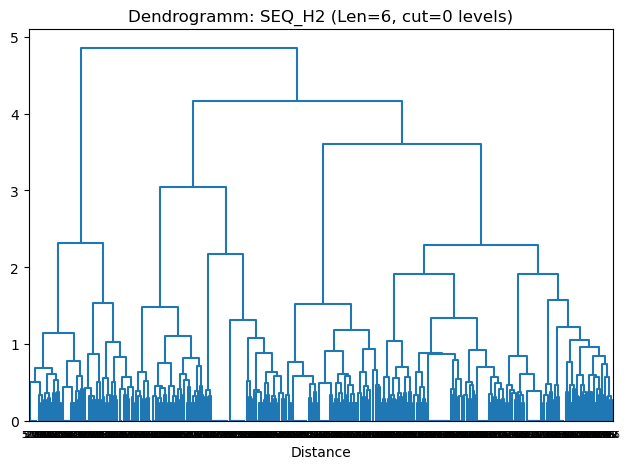


SEQ_H2, Länge 6 → 1 Subgruppen:
  Cluster 1:
    Antigen-Verteilung:
      spike glycoprotein: 145x
      spike protein s1: 109x
      hemagglutinin: 23x
      neuraminidase: 17x
      gametocyte surface protein p230: 13x
      fusion glycoprotein f0: 12x
      surface glycoprotein: 11x
      circumsporozoite protein: 11x
      envelope glycoprotein e2: 10x
      clade a/e 93th057 hiv-1 gp120 core: 10x
      programmed cell death protein 1: 10x
      envelope glycoprotein gp120: 8x
      envelope glycoprotein gp160: 8x
      receptor tyrosine-protein kinase erbb-2: 8x
      ch848.10.17 gp120: 7x
      interleukin-17a: 7x
      envelope glycoprotein b: 7x
      leukocyte surface antigen cd47: 7x
      spike glycoprotein,fibritin: 6x
      reticulocyte binding protein 2b: 6x
      envelope protein: 5x
      programmed cell death 1 ligand 1: 5x
      sars-cov-2 spike glycoprotein: 5x
      cytotoxic t-lymphocyte protein 4: 5x
      spike protein: 4x
      reticulocyte-binding protein hom

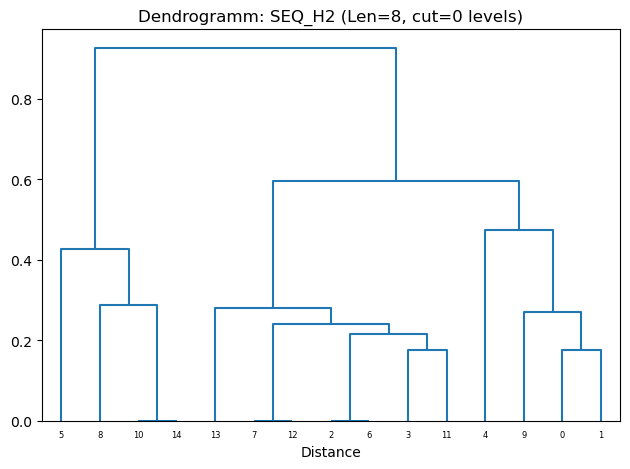


SEQ_H2, Länge 8 → 1 Subgruppen:
  Cluster 1:
    Antigen-Verteilung:
      spike glycoprotein: 8x
      spike protein s1: 3x
      envelope glycoprotein h: 1x
      spike protein s2': 1x
      circumsporozoite protein: 1x
      hemagglutinin: 1x
    PDB_IDs:
      8sdg
      7s07
      7ls9
      7kzb
      7ey5
      7x8y
      7jx3
      8suo
      8ekd
      8r8k
      7mzj
      8khc
      6o2b
      8ghk
      8jmm
    Sequenzen:
      SSNVNNDA
      RNKENSFT
      RNKANSYT
      RNKANSYT
      KSKADGQT
      KSKTDGGT
      KSKTDGGT
      KSKIDGGT
      KSKIDGGT
      KSKADGGT
      KRKSDGGT
      SSEIGGGT
      RSKANGGR
      RTKGNSYA
      RSKAYGGT

--------------------------------------------------

✅ TSV geschrieben: cdr_cluster_pre_decided_HC_length_tsvs/clusters_SEQ_L1_len10.tsv


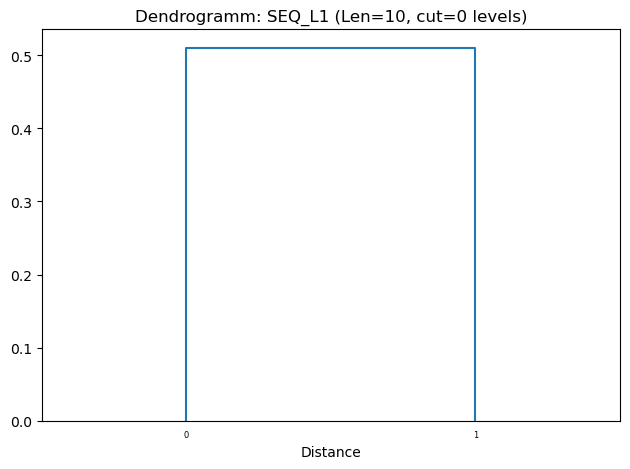


SEQ_L1, Länge 10 → 1 Subgruppen:
  Cluster 1:
    Antigen-Verteilung:
      gametocyte surface protein p230: 1x
      clade a/e 93th057 hiv-1 gp120 core: 1x
    PDB_IDs:
      7uvq
      4jb9
    Sequenzen:
      SASSSVSYMY
      RASQGGNSLN

--------------------------------------------------

✅ TSV geschrieben: cdr_cluster_pre_decided_HC_length_tsvs/clusters_SEQ_L1_len11.tsv


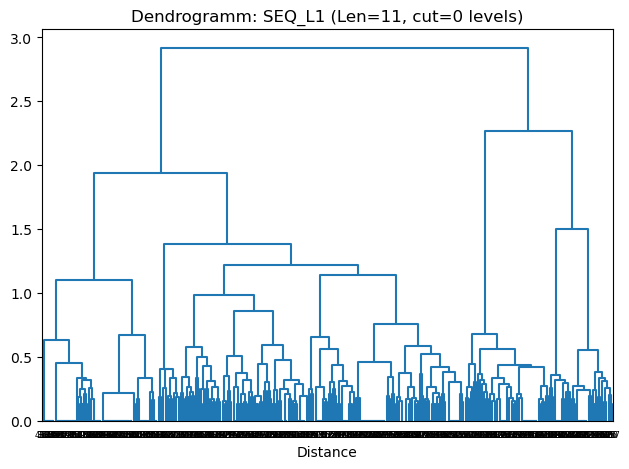


SEQ_L1, Länge 11 → 1 Subgruppen:
  Cluster 1:
    Antigen-Verteilung:
      spike glycoprotein: 107x
      spike protein s1: 94x
      hemagglutinin: 24x
      neuraminidase: 14x
      surface glycoprotein: 13x
      fusion glycoprotein f0: 12x
      programmed cell death protein 1: 9x
      circumsporozoite protein: 9x
      gametocyte surface protein p230: 9x
      envelope glycoprotein e2: 6x
      clade a/e 93th057 hiv-1 gp120 core: 6x
      envelope glycoprotein gp160: 6x
      epidermal growth factor receptor: 5x
      receptor tyrosine-protein kinase erbb-2: 5x
      reticulocyte-binding protein homolog 5: 5x
      reticulocyte binding protein 2b: 5x
      hemagglutinin ha1 chain: 5x
      histone chaperone asf1: 4x
      spike protein: 4x
      tumor necrosis factor receptor superfamily member 9: 4x
      leukocyte surface antigen cd47: 4x
      spike protein s2': 4x
      envelope glycoprotein b: 4x
      genome polyprotein: 4x
      nucleoprotein: 3x
      arginase-1: 3x
   

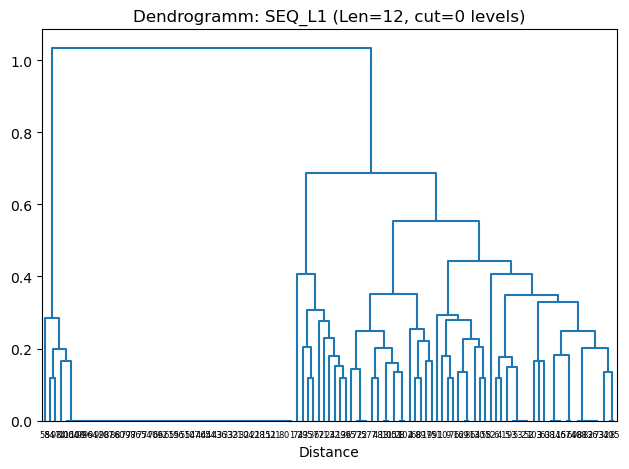


SEQ_L1, Länge 12 → 1 Subgruppen:
  Cluster 1:
    Antigen-Verteilung:
      spike glycoprotein: 32x
      spike protein s1: 29x
      surface glycoprotein: 7x
      envelope glycoprotein e2: 5x
      hemagglutinin: 3x
      spike glycoprotein,fibritin: 3x
      cytotoxic t-lymphocyte protein 4: 3x
      neuraminidase: 3x
      circumsporozoite protein: 2x
      glycoprotein 120: 2x
      t-cell immunoreceptor with ig and itim domains: 1x
      sars-cov-2 spike glycoprotein: 1x
      pre-glycoprotein polyprotein gp complex: 1x
      interleukin-17a: 1x
      nucleoprotein: 1x
      leukocyte surface antigen cd47: 1x
      hemagglutinin ha1: 1x
      vascular endothelial growth factor a: 1x
      spike protein s2': 1x
      envelope glycoprotein gp120: 1x
      envelope glycoprotein h: 1x
      transforming growth factor beta-2: 1x
      envelope glycoprotein gp160: 1x
      envelope protein: 1x
      interferon alpha-2: 1x
      clade a/e 93th057 hiv-1 gp120 core: 1x
      programmed c

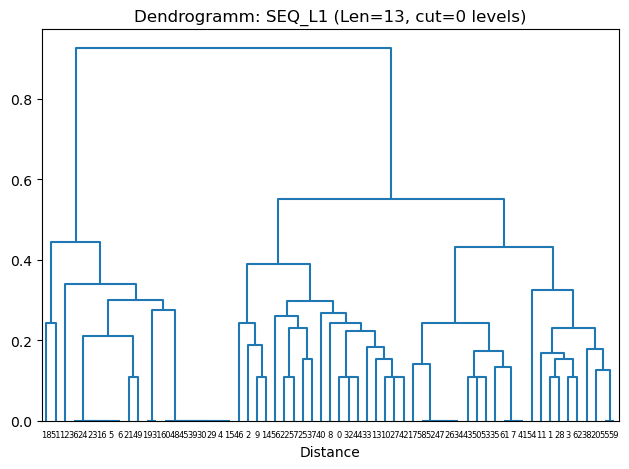


SEQ_L1, Länge 13 → 1 Subgruppen:
  Cluster 1:
    Antigen-Verteilung:
      spike glycoprotein: 22x
      spike protein s1: 13x
      hemagglutinin: 6x
      neuraminidase: 3x
      envelope glycoprotein b: 3x
      envelope glycoprotein gp120: 2x
      interleukin-17a: 2x
      envelope protein: 2x
      programmed cell death 1 ligand 1: 1x
      sars-cov-2 spike glycoprotein: 1x
      spike glycoprotein,fibritin,expression tag: 1x
      glutamate receptor ionotropic, nmda 1: 1x
      receptor tyrosine-protein kinase erbb-2: 1x
      gametocyte surface protein p230: 1x
      surface glycoprotein: 1x
      erythropoietin receptor: 1x
      25 kda ookinete surface antigen: 1x
      nucleoprotein: 1x
    PDB_IDs:
      7xsb
      7kde
      7yds
      7jva
      7ycn
      7yck
      7vzt
      8zhe
      8zho
      7u0x
      7m7b
      8dy1
      2vxs
      6ii4
      7ttx
      7jx3
      6ii8
      7wog
      7wo4
      8vuj
      8eoo
      3wsq
      9dwe
      8zby
      7yve
   

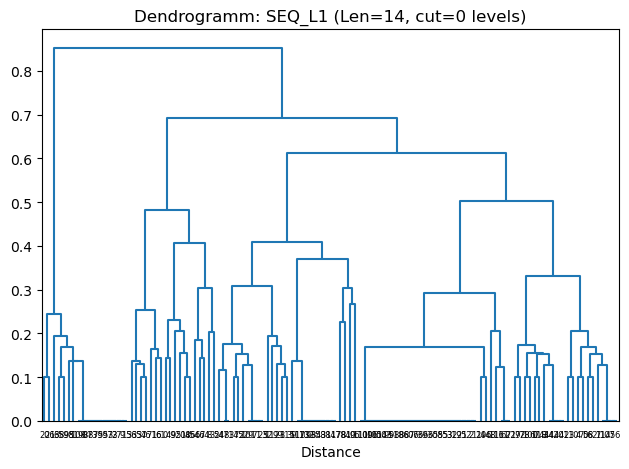


SEQ_L1, Länge 14 → 1 Subgruppen:
  Cluster 1:
    Antigen-Verteilung:
      spike protein s1: 34x
      spike glycoprotein: 31x
      ch848.10.17 gp120: 7x
      hemagglutinin: 4x
      ch848.10.17.sosip gp120: 4x
      neuraminidase: 4x
      fusion glycoprotein f0: 3x
      spike glycoprotein,fibritin: 3x
      envelope glycoprotein gp120: 3x
      reticulocyte binding protein 2b: 2x
      envelope glycoprotein e: 2x
      surface glycoprotein: 2x
      clade a/e 93th057 hiv-1 gp120 core: 2x
      spike glycoprotein,fibritin,expression tag: 2x
      sars-cov-2 spike glycoprotein: 2x
      programmed cell death 1 ligand 1: 2x
      envelope glycoprotein gp160: 2x
      erythropoietin receptor: 2x
      ig epsilon chain c region: 1x
      hemagglutinin ha1: 1x
      gametocyte surface protein p230: 1x
      e2 glycoprotein: 1x
      envelope protein: 1x
      envelope protein e: 1x
      receptor tyrosine-protein kinase erbb-2: 1x
      nucleoprotein: 1x
    PDB_IDs:
      8hrd
      

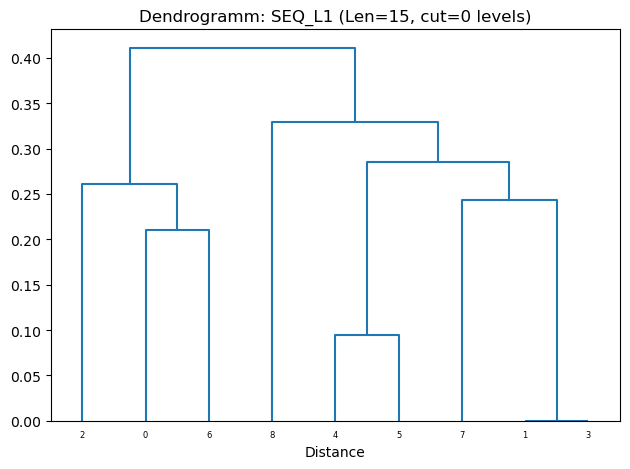


SEQ_L1, Länge 15 → 1 Subgruppen:
  Cluster 1:
    Antigen-Verteilung:
      spike glycoprotein: 3x
      ige fc: 3x
      interferon alpha-2: 1x
      programmed cell death protein 1: 1x
      25 kda ookinete surface antigen: 1x
    PDB_IDs:
      4z5r
      7mw6
      5ggs
      6phc
      7shy
      7si0
      7shz
      7mw3
      7e5s
    Sequenzen:
      RASQSVSTSSYSYMH
      RASESVEYYGTSLMQ
      RASKGVSTSGYSYLH
      RSSQSLLHNGYNYLD
      RASQSVDYDGDSYMN
      RASQSVDSDGDSYMN
      RASKPVDGEGDSYLN
      RASESVDNYGISFMN
      RASESVDNYGISFMN

--------------------------------------------------

✅ TSV geschrieben: cdr_cluster_pre_decided_HC_length_tsvs/clusters_SEQ_L1_len16.tsv


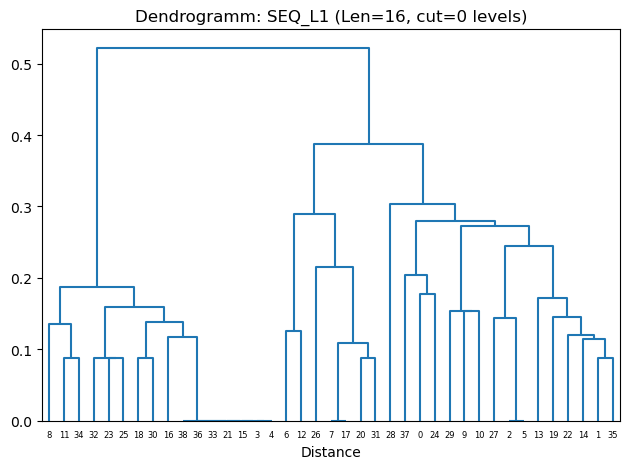


SEQ_L1, Länge 16 → 1 Subgruppen:
  Cluster 1:
    Antigen-Verteilung:
      spike glycoprotein: 8x
      hemagglutinin: 7x
      spike protein s1: 4x
      fusion glycoprotein f0: 2x
      25 kda ookinete surface antigen: 2x
      leukocyte surface antigen cd47: 2x
      circumsporozoite protein: 1x
      envelope glycoprotein h: 1x
      spike protein: 1x
      clade a/e 93th057 hiv-1 gp120 core: 1x
      neuraminidase: 1x
      reticulocyte-binding protein homolog 5: 1x
      glycoprotein 120: 1x
      epidermal growth factor receptor: 1x
      interleukin-17a: 1x
      tumor necrosis factor receptor superfamily member 5: 1x
      cytotoxic t-lymphocyte protein 4: 1x
      envelope glycoprotein b: 1x
      t-cell immunoreceptor with ig and itim domains: 1x
      envelope glycoprotein e2: 1x
    PDB_IDs:
      8tnl
      8bg1
      7rxp
      6iuv
      7e8c
      7pnm
      7t4r
      5a3i
      7wsc
      6c6z
      6oej
      7deo
      7chh
      7e9o
      8zr4
      8us0
      

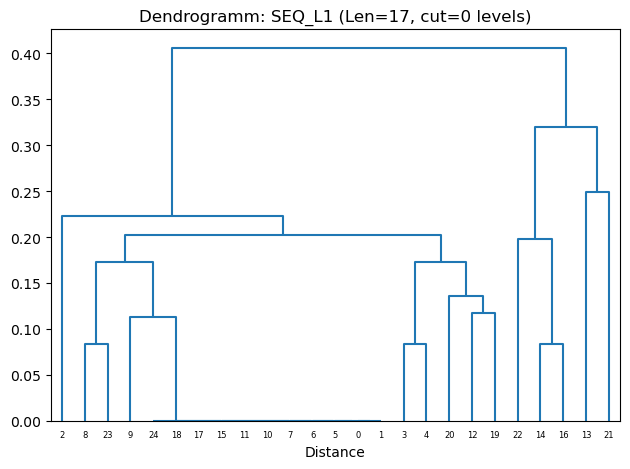


SEQ_L1, Länge 17 → 1 Subgruppen:
  Cluster 1:
    Antigen-Verteilung:
      spike glycoprotein: 8x
      spike protein s1: 5x
      hemagglutinin: 3x
      surface glycoprotein: 2x
      gametocyte surface protein p230: 2x
      tumor necrosis factor receptor superfamily member 5: 2x
      spike protein s2': 1x
      programmed cell death protein 1: 1x
      receptor tyrosine-protein kinase erbb-2: 1x
    PDB_IDs:
      8ekd
      8d48
      7eng
      7mzk
      7kn3
      7k9z
      7czy
      7d0d
      7ps2
      7czx
      7uvs
      7ubs
      8dnn
      8ume
      8suo
      8gf2
      8cwj
      7prz
      7fjo
      6xq4
      6xkr
      6pe9
      6pe8
      6att
      6xpx
    Sequenzen:
      KSSQSVLYAANNKNYLA
      KSSRNVLYSSNNKNYLA
      KSSQSVLYRSNNKNYLA
      KSSQSVLYSSNNKNYLG
      KSSQSVLYSSNNKNYLA
      KSSQSVLYSSNNKNYLA
      KSSQSVLYSSNNKNYLA
      KSSQSVLYSSNNKNYLA
      KSSQSVLYSSNNKNYLA
      KSSQSVLYSSNNKNYLA
      KSSQSVLYSSNNKNYLA
      KSSQSVLYSSNNKNYLA
   

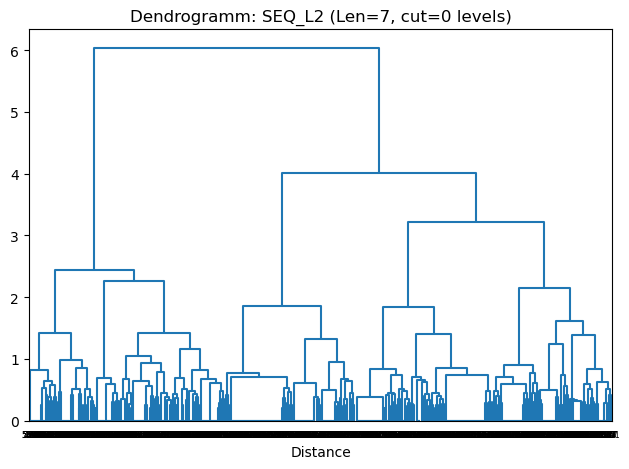


SEQ_L2, Länge 7 → 1 Subgruppen:
  Cluster 1:
    Antigen-Verteilung:
      spike glycoprotein: 211x
      spike protein s1: 179x
      hemagglutinin: 47x
      neuraminidase: 25x
      surface glycoprotein: 25x
      fusion glycoprotein f0: 17x
      gametocyte surface protein p230: 15x
      circumsporozoite protein: 12x
      envelope glycoprotein e2: 12x
      clade a/e 93th057 hiv-1 gp120 core: 11x
      programmed cell death protein 1: 11x
      spike glycoprotein,fibritin: 9x
      envelope glycoprotein gp160: 9x
      receptor tyrosine-protein kinase erbb-2: 8x
      envelope glycoprotein b: 8x
      envelope glycoprotein gp120: 8x
      reticulocyte binding protein 2b: 7x
      interleukin-17a: 7x
      ch848.10.17 gp120: 7x
      leukocyte surface antigen cd47: 7x
      25 kda ookinete surface antigen: 6x
      envelope protein: 6x
      nucleoprotein: 6x
      reticulocyte-binding protein homolog 5: 6x
      epidermal growth factor receptor: 6x
      cytotoxic t-lymphocyte p

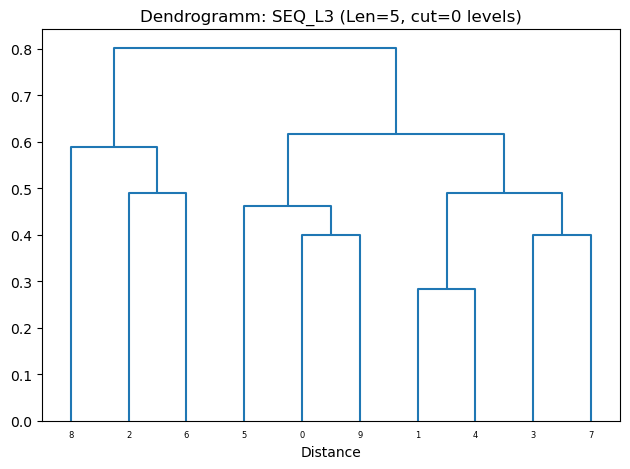


SEQ_L3, Länge 5 → 1 Subgruppen:
  Cluster 1:
    Antigen-Verteilung:
      clade a/e 93th057 hiv-1 gp120 core: 2x
      envelope glycoprotein gp160: 2x
      spike glycoprotein: 2x
      envelope glycoprotein gp120: 1x
      glycoprotein 120: 1x
      spike protein s1: 1x
      hemagglutinin: 1x
    PDB_IDs:
      4jb9
      7ugq
      4ydi
      7rdw
      9cci
      4j6r
      8qh0
      6e4x
      7s6j
      5te6
    Sequenzen:
      QQFEF
      SAFEY
      QVIES
      QHMYT
      QQYDA
      QQYET
      QQGVT
      QQQGT
      QQPLT
      QVLQF

--------------------------------------------------

✅ TSV geschrieben: cdr_cluster_pre_decided_HC_length_tsvs/clusters_SEQ_L3_len8.tsv


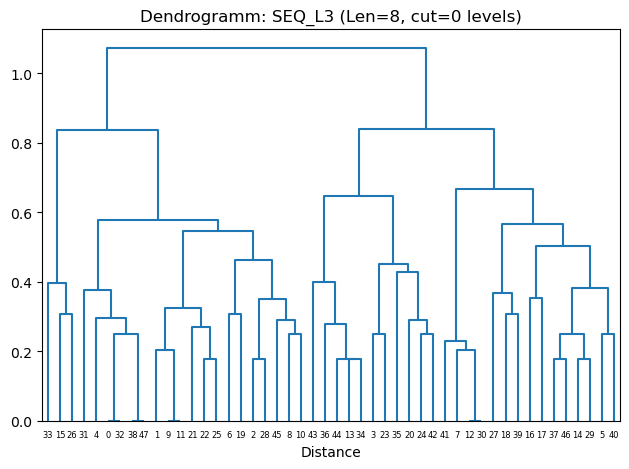


SEQ_L3, Länge 8 → 1 Subgruppen:
  Cluster 1:
    Antigen-Verteilung:
      spike protein s1: 14x
      spike glycoprotein: 10x
      envelope glycoprotein gp160: 3x
      hemagglutinin: 3x
      clade a/e 93th057 hiv-1 gp120 core: 3x
      envelope glycoprotein e2: 2x
      spike protein: 2x
      circumsporozoite protein: 2x
      fusion glycoprotein f0: 1x
      hemagglutinin ha1: 1x
      surface glycoprotein: 1x
      envelope glycoprotein e: 1x
      spike protein s2': 1x
      reticulocyte-binding protein homolog 5: 1x
      tumor necrosis factor receptor superfamily member 5: 1x
      25 kda ookinete surface antigen: 1x
      programmed cell death 1 ligand 1: 1x
    PDB_IDs:
      5t3z
      8eay
      5w08
      7ljr
      8tzy
      9l6c
      6uyg
      7ps1
      7n62
      8v5q
      8suo
      8ekd
      8bbo
      7ul1
      7jmo
      8pwv
      7y6l
      8wyj
      7nx7
      5w42
      8x0y
      8yx1
      6oej
      6phc
      6c6z
      8bg1
      6iuv
      8wyj


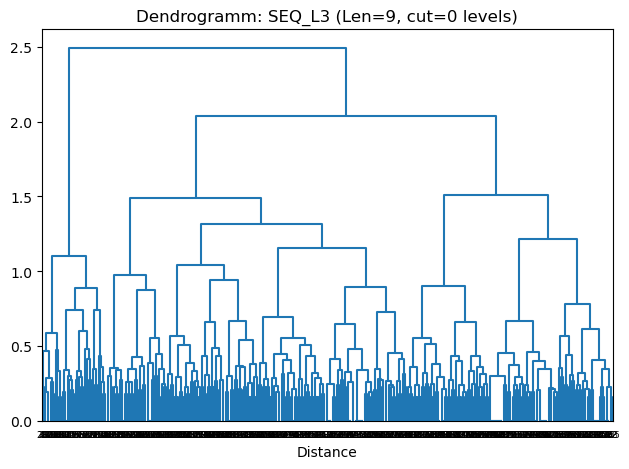


SEQ_L3, Länge 9 → 1 Subgruppen:
  Cluster 1:
    Antigen-Verteilung:
      spike glycoprotein: 122x
      spike protein s1: 85x
      hemagglutinin: 33x
      programmed cell death protein 1: 11x
      surface glycoprotein: 11x
      envelope glycoprotein e2: 10x
      fusion glycoprotein f0: 10x
      neuraminidase: 8x
      gametocyte surface protein p230: 7x
      circumsporozoite protein: 6x
      cytotoxic t-lymphocyte protein 4: 6x
      leukocyte surface antigen cd47: 6x
      receptor tyrosine-protein kinase erbb-2: 6x
      interleukin-17a: 6x
      envelope glycoprotein b: 5x
      spike glycoprotein,fibritin: 5x
      epidermal growth factor receptor: 5x
      spike protein s2': 5x
      genome polyprotein: 4x
      e2 glycoprotein: 4x
      nucleoprotein: 4x
      envelope glycoprotein h: 4x
      vascular endothelial growth factor a: 4x
      histone chaperone asf1: 4x
      reticulocyte-binding protein homolog 5: 4x
      tumor necrosis factor receptor superfamily member

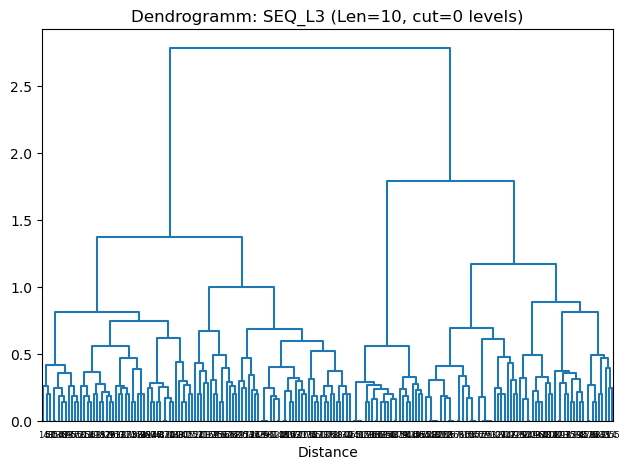


SEQ_L3, Länge 10 → 1 Subgruppen:
  Cluster 1:
    Antigen-Verteilung:
      spike protein s1: 54x
      spike glycoprotein: 38x
      neuraminidase: 14x
      surface glycoprotein: 9x
      gametocyte surface protein p230: 7x
      ch848.10.17 gp120: 7x
      hemagglutinin: 5x
      spike glycoprotein,fibritin: 4x
      ch848.10.17.sosip gp120: 4x
      circumsporozoite protein: 3x
      sars-cov-2 spike glycoprotein: 3x
      25 kda ookinete surface antigen: 2x
      tyrosine-protein phosphatase non-receptor type substrate 1: 2x
      clade a/e 93th057 hiv-1 gp120 core: 2x
      envelope protein e: 2x
      hemagglutinin ha1: 2x
      envelope glycoprotein e: 2x
      envelope glycoprotein gp120: 2x
      envelope protein: 2x
      envelope glycoprotein b: 2x
      programmed cell death 1 ligand 1: 2x
      reticulocyte binding protein 2b: 2x
      fusion glycoprotein f0: 2x
      leukocyte surface antigen cd47: 1x
      cadmium and zinc efflux pump fief: 1x
      reticulocyte-bindin

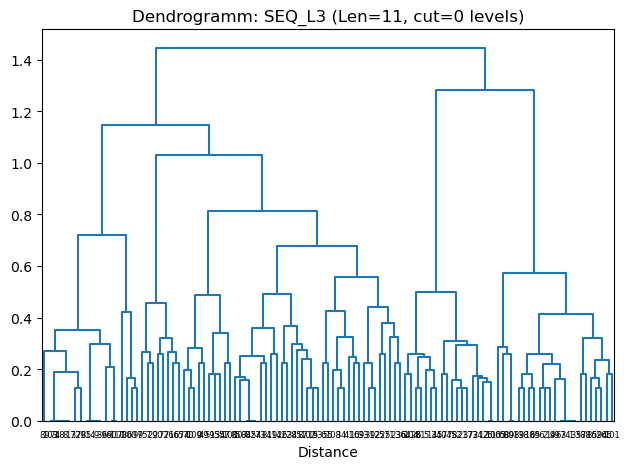


SEQ_L3, Länge 11 → 1 Subgruppen:
  Cluster 1:
    Antigen-Verteilung:
      spike glycoprotein: 39x
      spike protein s1: 25x
      hemagglutinin: 5x
      surface glycoprotein: 4x
      fusion glycoprotein f0: 4x
      envelope glycoprotein gp120: 3x
      neuraminidase: 3x
      reticulocyte binding protein 2b: 3x
      hemagglutinin ha1 chain: 3x
      erythropoietin receptor: 2x
      envelope protein: 2x
      glutamate receptor ionotropic, nmda 1: 1x
      spike protein: 1x
      ig epsilon chain c region: 1x
      tumor necrosis factor ligand superfamily member 13b: 1x
      receptor tyrosine-protein kinase erbb-2: 1x
      programmed cell death 1 ligand 1: 1x
      clade a/e 93th057 hiv-1 gp120 core: 1x
      envelope glycoprotein gp160: 1x
      envelope glycoprotein b: 1x
      tumor necrosis factor receptor superfamily member 9: 1x
      interleukin-17a: 1x
      nucleoprotein: 1x
      gametocyte surface protein p230: 1x
      25 kda ookinete surface antigen: 1x
      re

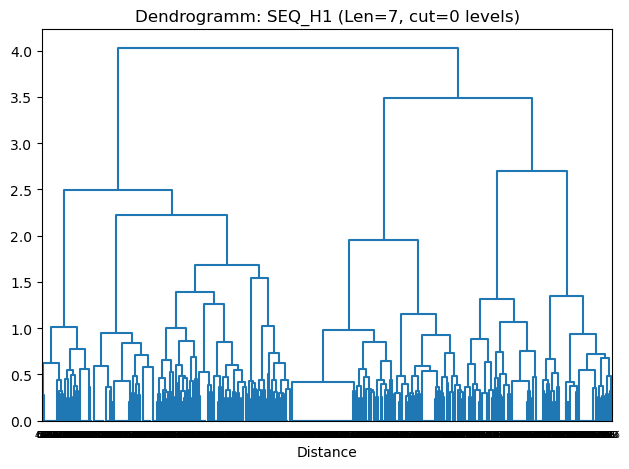


SEQ_H1, Länge 7 → 1 Subgruppen:
  Cluster 1:
    Antigen-Verteilung:
      spike glycoprotein: 192x
      spike protein s1: 166x
      hemagglutinin: 36x
      surface glycoprotein: 21x
      neuraminidase: 19x
      fusion glycoprotein f0: 15x
      gametocyte surface protein p230: 14x
      circumsporozoite protein: 12x
      envelope glycoprotein e2: 12x
      programmed cell death protein 1: 11x
      clade a/e 93th057 hiv-1 gp120 core: 10x
      envelope glycoprotein gp160: 8x
      receptor tyrosine-protein kinase erbb-2: 8x
      spike glycoprotein,fibritin: 8x
      ch848.10.17 gp120: 7x
      envelope glycoprotein gp120: 7x
      leukocyte surface antigen cd47: 7x
      envelope glycoprotein b: 7x
      interleukin-17a: 7x
      reticulocyte binding protein 2b: 7x
      reticulocyte-binding protein homolog 5: 6x
      cytotoxic t-lymphocyte protein 4: 6x
      programmed cell death 1 ligand 1: 6x
      nucleoprotein: 6x
      spike protein s2': 5x
      sars-cov-2 spike glyco

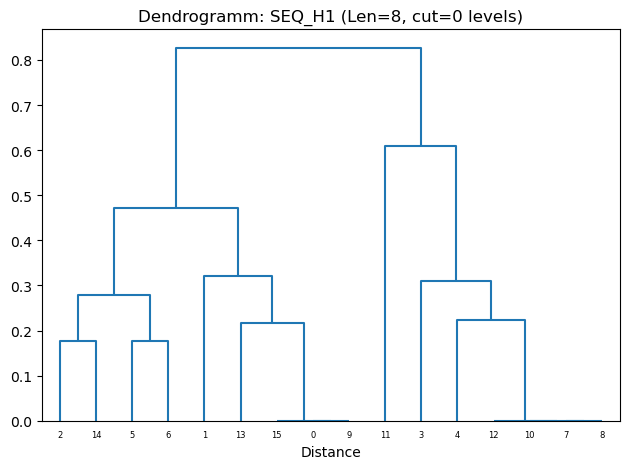


SEQ_H1, Länge 8 → 1 Subgruppen:
  Cluster 1:
    Antigen-Verteilung:
      spike protein s1: 3x
      ige fc: 3x
      25 kda ookinete surface antigen: 1x
      hemagglutinin: 1x
      hemagglutinin ha1 chain: 1x
      envelope glycoprotein gp160: 1x
      glutamate receptor ionotropic, nmda 1: 1x
      genome polyprotein: 1x
      envelope glycoprotein gp120: 1x
      spike glycoprotein: 1x
      gametocyte surface protein p230: 1x
      neuraminidase: 1x
    PDB_IDs:
      8ezk
      4xnm
      8dcc
      4m5z
      8x0y
      7wph
      6dfh
      8vuj
      5gzo
      7kde
      7xdl
      7uvq
      7shz
      6pzy
      7shy
      7si0
    Sequenzen:
      GFSISSSY
      GGSISSSY
      GYSISSGY
      GYSISSNY
      GASISSGD
      GGSISSNN
      GGSISSSN
      GGSISSSN
      GGSISSSN
      GYNIRSNN
      GYSFTSYY
      GYSITSDY
      GYSITSGY
      GYTISSGY
      GYSITSGY
      GYSITSGY

--------------------------------------------------

✅ TSV geschrieben: cdr_cluster_pre_decide

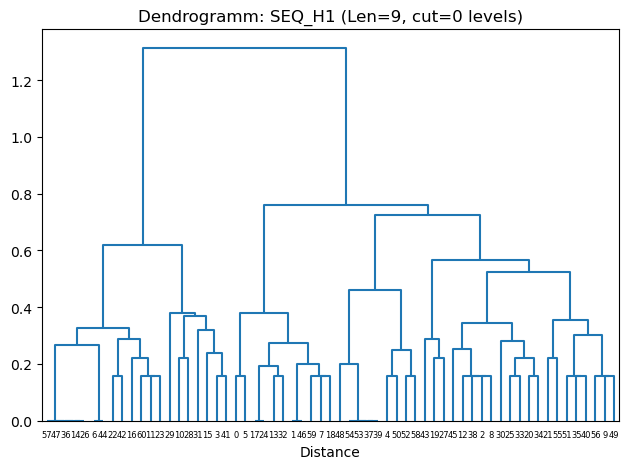


SEQ_H1, Länge 9 → 1 Subgruppen:
  Cluster 1:
    Antigen-Verteilung:
      spike glycoprotein: 18x
      spike protein s1: 10x
      hemagglutinin: 10x
      neuraminidase: 5x
      surface glycoprotein: 4x
      epidermal growth factor receptor: 3x
      fusion glycoprotein f0: 2x
      spike protein s2': 1x
      envelope glycoprotein b: 1x
      pre-glycoprotein polyprotein gp complex: 1x
      clade a/e 93th057 hiv-1 gp120 core: 1x
      tumor necrosis factor receptor superfamily member 5: 1x
      envelope protein: 1x
      spike glycoprotein,fibritin: 1x
      envelope glycoprotein e: 1x
      e2 glycoprotein: 1x
    PDB_IDs:
      7lss
      7cm4
      7d0d
      8hp9
      7xsa
      8rgz
      6urm
      7yve
      7mmo
      7ycy
      7t01
      8gdr
      7yvk
      7wrj
      8vye
      8erq
      8cw9
      8tma
      9bdf
      7wee
      8veb
      8zho
      8tp6
      8eoo
      8cbd
      7bel
      8vef
      5w1k
      5kjr
      8yx1
      8tp7
      7pry
      7

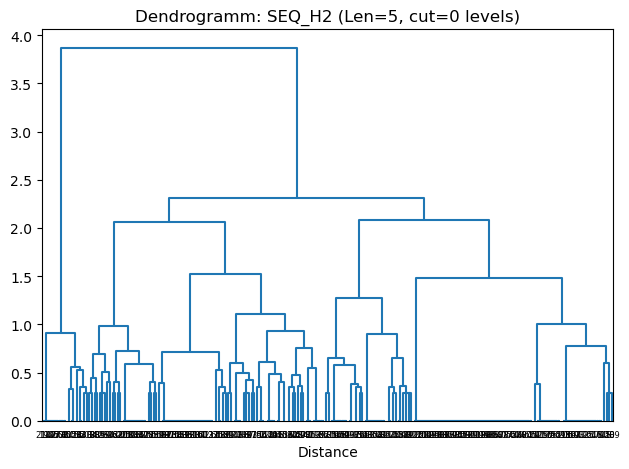


SEQ_H2, Länge 5 → 1 Subgruppen:
  Cluster 1:
    Antigen-Verteilung:
      spike protein s1: 67x
      spike glycoprotein: 58x
      hemagglutinin: 23x
      surface glycoprotein: 14x
      neuraminidase: 8x
      fusion glycoprotein f0: 5x
      spike protein s2': 4x
      epidermal growth factor receptor: 4x
      nucleoprotein: 3x
      ige fc: 3x
      spike glycoprotein,fibritin: 3x
      gametocyte surface protein p230: 2x
      25 kda ookinete surface antigen: 2x
      envelope glycoprotein e: 2x
      envelope glycoprotein e2: 2x
      reticulocyte-binding protein homolog 5: 2x
      envelope glycoprotein b: 1x
      cytotoxic t-lymphocyte protein 4: 1x
      hemagglutinin ha1: 1x
      envelope glycoprotein h: 1x
      e2 glycoprotein: 1x
      glycoprotein 120: 1x
      programmed cell death 1 ligand 1: 1x
      tumor necrosis factor receptor superfamily member 5: 1x
      envelope protein e: 1x
      programmed cell death protein 1: 1x
      pre-glycoprotein polyprotein gp 

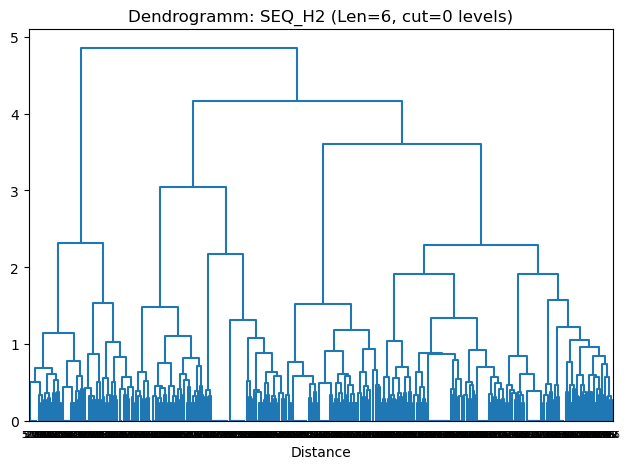


SEQ_H2, Länge 6 → 1 Subgruppen:
  Cluster 1:
    Antigen-Verteilung:
      spike glycoprotein: 145x
      spike protein s1: 109x
      hemagglutinin: 23x
      neuraminidase: 17x
      gametocyte surface protein p230: 13x
      fusion glycoprotein f0: 12x
      surface glycoprotein: 11x
      circumsporozoite protein: 11x
      envelope glycoprotein e2: 10x
      clade a/e 93th057 hiv-1 gp120 core: 10x
      programmed cell death protein 1: 10x
      envelope glycoprotein gp120: 8x
      envelope glycoprotein gp160: 8x
      receptor tyrosine-protein kinase erbb-2: 8x
      ch848.10.17 gp120: 7x
      interleukin-17a: 7x
      envelope glycoprotein b: 7x
      leukocyte surface antigen cd47: 7x
      spike glycoprotein,fibritin: 6x
      reticulocyte binding protein 2b: 6x
      envelope protein: 5x
      programmed cell death 1 ligand 1: 5x
      sars-cov-2 spike glycoprotein: 5x
      cytotoxic t-lymphocyte protein 4: 5x
      spike protein: 4x
      reticulocyte-binding protein hom

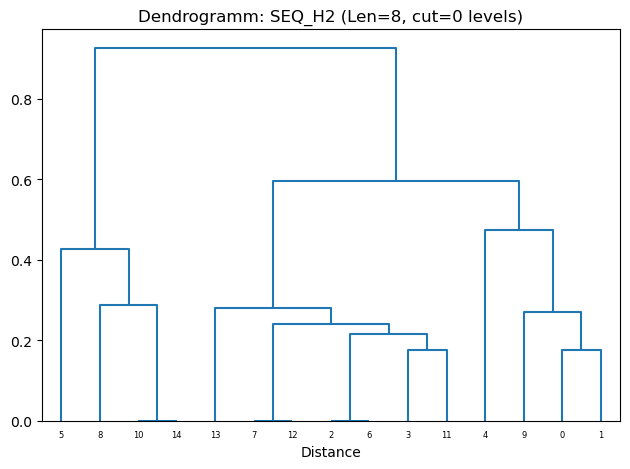


SEQ_H2, Länge 8 → 1 Subgruppen:
  Cluster 1:
    Antigen-Verteilung:
      spike glycoprotein: 8x
      spike protein s1: 3x
      envelope glycoprotein h: 1x
      spike protein s2': 1x
      circumsporozoite protein: 1x
      hemagglutinin: 1x
    PDB_IDs:
      8sdg
      7s07
      7ls9
      7kzb
      7ey5
      7x8y
      7jx3
      8suo
      8ekd
      8r8k
      7mzj
      8khc
      6o2b
      8ghk
      8jmm
    Sequenzen:
      SSNVNNDA
      RNKENSFT
      RNKANSYT
      RNKANSYT
      KSKADGQT
      KSKTDGGT
      KSKTDGGT
      KSKIDGGT
      KSKIDGGT
      KSKADGGT
      KRKSDGGT
      SSEIGGGT
      RSKANGGR
      RTKGNSYA
      RSKAYGGT

--------------------------------------------------

✅ TSV geschrieben: cdr_cluster_pre_decided_HC_length_tsvs/clusters_SEQ_L1_len10.tsv


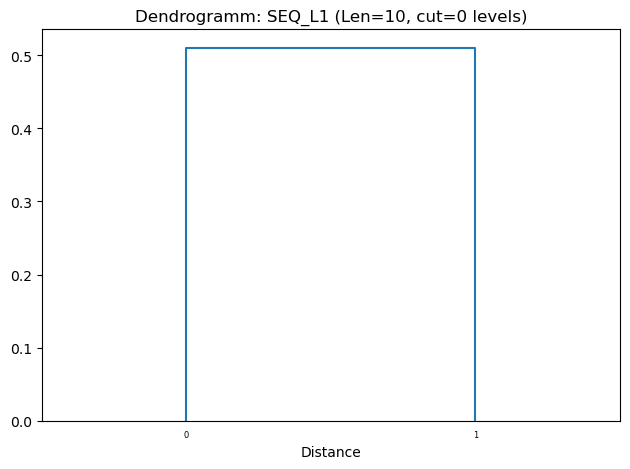


SEQ_L1, Länge 10 → 1 Subgruppen:
  Cluster 1:
    Antigen-Verteilung:
      gametocyte surface protein p230: 1x
      clade a/e 93th057 hiv-1 gp120 core: 1x
    PDB_IDs:
      7uvq
      4jb9
    Sequenzen:
      SASSSVSYMY
      RASQGGNSLN

--------------------------------------------------

✅ TSV geschrieben: cdr_cluster_pre_decided_HC_length_tsvs/clusters_SEQ_L1_len11.tsv


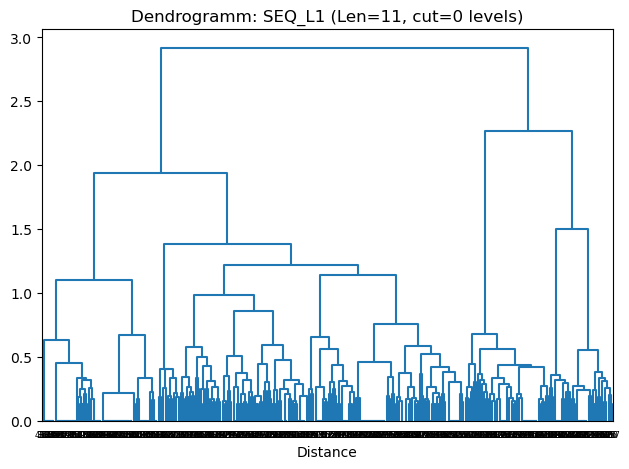


SEQ_L1, Länge 11 → 1 Subgruppen:
  Cluster 1:
    Antigen-Verteilung:
      spike glycoprotein: 107x
      spike protein s1: 94x
      hemagglutinin: 24x
      neuraminidase: 14x
      surface glycoprotein: 13x
      fusion glycoprotein f0: 12x
      programmed cell death protein 1: 9x
      circumsporozoite protein: 9x
      gametocyte surface protein p230: 9x
      envelope glycoprotein e2: 6x
      clade a/e 93th057 hiv-1 gp120 core: 6x
      envelope glycoprotein gp160: 6x
      epidermal growth factor receptor: 5x
      receptor tyrosine-protein kinase erbb-2: 5x
      reticulocyte-binding protein homolog 5: 5x
      reticulocyte binding protein 2b: 5x
      hemagglutinin ha1 chain: 5x
      histone chaperone asf1: 4x
      spike protein: 4x
      tumor necrosis factor receptor superfamily member 9: 4x
      leukocyte surface antigen cd47: 4x
      spike protein s2': 4x
      envelope glycoprotein b: 4x
      genome polyprotein: 4x
      nucleoprotein: 3x
      arginase-1: 3x
   

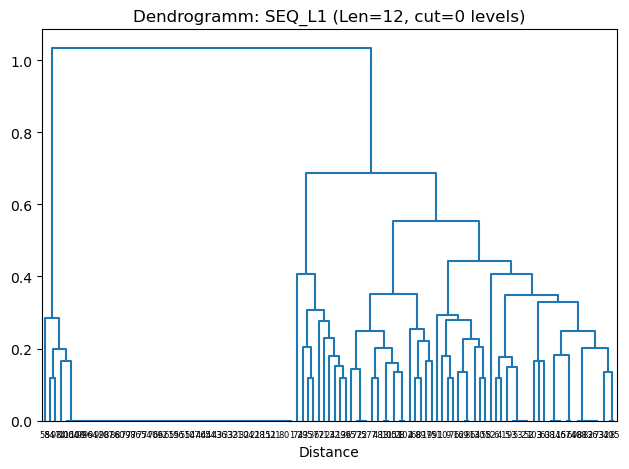


SEQ_L1, Länge 12 → 1 Subgruppen:
  Cluster 1:
    Antigen-Verteilung:
      spike glycoprotein: 32x
      spike protein s1: 29x
      surface glycoprotein: 7x
      envelope glycoprotein e2: 5x
      hemagglutinin: 3x
      spike glycoprotein,fibritin: 3x
      cytotoxic t-lymphocyte protein 4: 3x
      neuraminidase: 3x
      circumsporozoite protein: 2x
      glycoprotein 120: 2x
      t-cell immunoreceptor with ig and itim domains: 1x
      sars-cov-2 spike glycoprotein: 1x
      pre-glycoprotein polyprotein gp complex: 1x
      interleukin-17a: 1x
      nucleoprotein: 1x
      leukocyte surface antigen cd47: 1x
      hemagglutinin ha1: 1x
      vascular endothelial growth factor a: 1x
      spike protein s2': 1x
      envelope glycoprotein gp120: 1x
      envelope glycoprotein h: 1x
      transforming growth factor beta-2: 1x
      envelope glycoprotein gp160: 1x
      envelope protein: 1x
      interferon alpha-2: 1x
      clade a/e 93th057 hiv-1 gp120 core: 1x
      programmed c

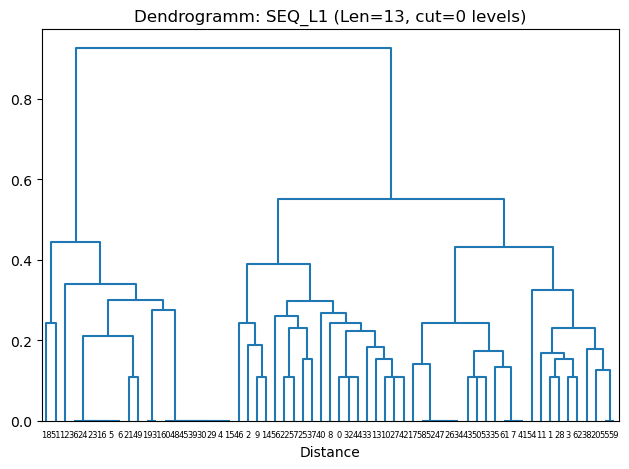


SEQ_L1, Länge 13 → 1 Subgruppen:
  Cluster 1:
    Antigen-Verteilung:
      spike glycoprotein: 22x
      spike protein s1: 13x
      hemagglutinin: 6x
      neuraminidase: 3x
      envelope glycoprotein b: 3x
      envelope glycoprotein gp120: 2x
      interleukin-17a: 2x
      envelope protein: 2x
      programmed cell death 1 ligand 1: 1x
      sars-cov-2 spike glycoprotein: 1x
      spike glycoprotein,fibritin,expression tag: 1x
      glutamate receptor ionotropic, nmda 1: 1x
      receptor tyrosine-protein kinase erbb-2: 1x
      gametocyte surface protein p230: 1x
      surface glycoprotein: 1x
      erythropoietin receptor: 1x
      25 kda ookinete surface antigen: 1x
      nucleoprotein: 1x
    PDB_IDs:
      7xsb
      7kde
      7yds
      7jva
      7ycn
      7yck
      7vzt
      8zhe
      8zho
      7u0x
      7m7b
      8dy1
      2vxs
      6ii4
      7ttx
      7jx3
      6ii8
      7wog
      7wo4
      8vuj
      8eoo
      3wsq
      9dwe
      8zby
      7yve
   

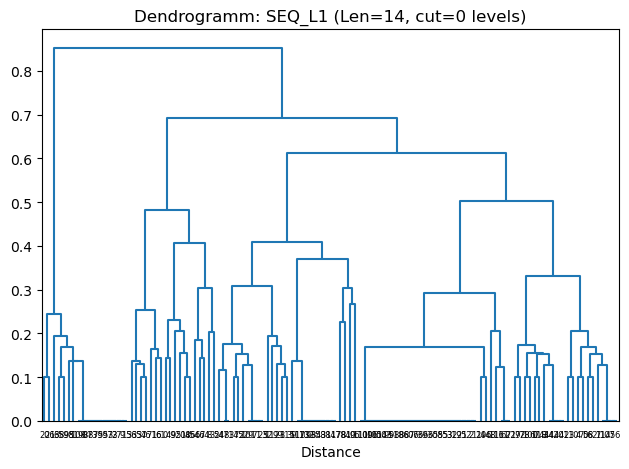


SEQ_L1, Länge 14 → 1 Subgruppen:
  Cluster 1:
    Antigen-Verteilung:
      spike protein s1: 34x
      spike glycoprotein: 31x
      ch848.10.17 gp120: 7x
      hemagglutinin: 4x
      ch848.10.17.sosip gp120: 4x
      neuraminidase: 4x
      fusion glycoprotein f0: 3x
      spike glycoprotein,fibritin: 3x
      envelope glycoprotein gp120: 3x
      reticulocyte binding protein 2b: 2x
      envelope glycoprotein e: 2x
      surface glycoprotein: 2x
      clade a/e 93th057 hiv-1 gp120 core: 2x
      spike glycoprotein,fibritin,expression tag: 2x
      sars-cov-2 spike glycoprotein: 2x
      programmed cell death 1 ligand 1: 2x
      envelope glycoprotein gp160: 2x
      erythropoietin receptor: 2x
      ig epsilon chain c region: 1x
      hemagglutinin ha1: 1x
      gametocyte surface protein p230: 1x
      e2 glycoprotein: 1x
      envelope protein: 1x
      envelope protein e: 1x
      receptor tyrosine-protein kinase erbb-2: 1x
      nucleoprotein: 1x
    PDB_IDs:
      8hrd
      

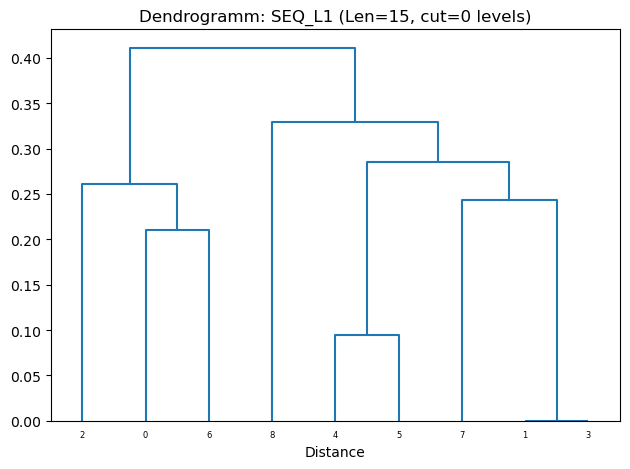


SEQ_L1, Länge 15 → 1 Subgruppen:
  Cluster 1:
    Antigen-Verteilung:
      spike glycoprotein: 3x
      ige fc: 3x
      interferon alpha-2: 1x
      programmed cell death protein 1: 1x
      25 kda ookinete surface antigen: 1x
    PDB_IDs:
      4z5r
      7mw6
      5ggs
      6phc
      7shy
      7si0
      7shz
      7mw3
      7e5s
    Sequenzen:
      RASQSVSTSSYSYMH
      RASESVEYYGTSLMQ
      RASKGVSTSGYSYLH
      RSSQSLLHNGYNYLD
      RASQSVDYDGDSYMN
      RASQSVDSDGDSYMN
      RASKPVDGEGDSYLN
      RASESVDNYGISFMN
      RASESVDNYGISFMN

--------------------------------------------------

✅ TSV geschrieben: cdr_cluster_pre_decided_HC_length_tsvs/clusters_SEQ_L1_len16.tsv


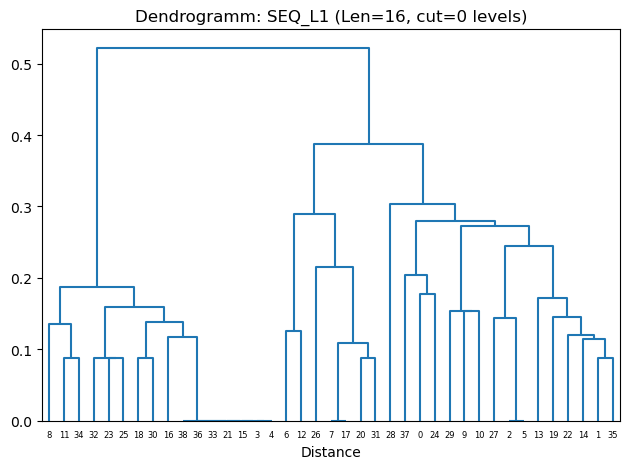


SEQ_L1, Länge 16 → 1 Subgruppen:
  Cluster 1:
    Antigen-Verteilung:
      spike glycoprotein: 8x
      hemagglutinin: 7x
      spike protein s1: 4x
      fusion glycoprotein f0: 2x
      25 kda ookinete surface antigen: 2x
      leukocyte surface antigen cd47: 2x
      circumsporozoite protein: 1x
      envelope glycoprotein h: 1x
      spike protein: 1x
      clade a/e 93th057 hiv-1 gp120 core: 1x
      neuraminidase: 1x
      reticulocyte-binding protein homolog 5: 1x
      glycoprotein 120: 1x
      epidermal growth factor receptor: 1x
      interleukin-17a: 1x
      tumor necrosis factor receptor superfamily member 5: 1x
      cytotoxic t-lymphocyte protein 4: 1x
      envelope glycoprotein b: 1x
      t-cell immunoreceptor with ig and itim domains: 1x
      envelope glycoprotein e2: 1x
    PDB_IDs:
      8tnl
      8bg1
      7rxp
      6iuv
      7e8c
      7pnm
      7t4r
      5a3i
      7wsc
      6c6z
      6oej
      7deo
      7chh
      7e9o
      8zr4
      8us0
      

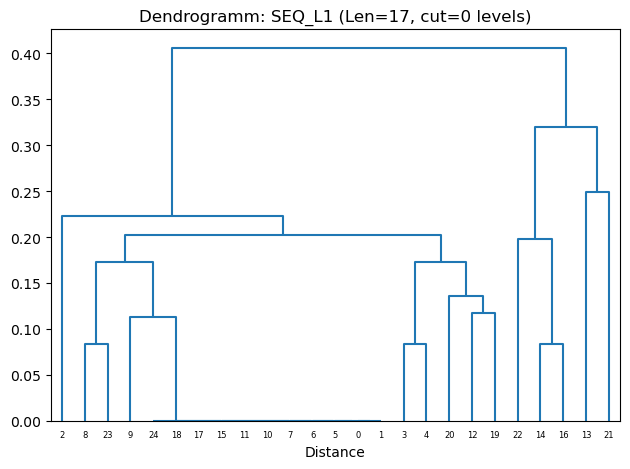


SEQ_L1, Länge 17 → 1 Subgruppen:
  Cluster 1:
    Antigen-Verteilung:
      spike glycoprotein: 8x
      spike protein s1: 5x
      hemagglutinin: 3x
      surface glycoprotein: 2x
      gametocyte surface protein p230: 2x
      tumor necrosis factor receptor superfamily member 5: 2x
      spike protein s2': 1x
      programmed cell death protein 1: 1x
      receptor tyrosine-protein kinase erbb-2: 1x
    PDB_IDs:
      8ekd
      8d48
      7eng
      7mzk
      7kn3
      7k9z
      7czy
      7d0d
      7ps2
      7czx
      7uvs
      7ubs
      8dnn
      8ume
      8suo
      8gf2
      8cwj
      7prz
      7fjo
      6xq4
      6xkr
      6pe9
      6pe8
      6att
      6xpx
    Sequenzen:
      KSSQSVLYAANNKNYLA
      KSSRNVLYSSNNKNYLA
      KSSQSVLYRSNNKNYLA
      KSSQSVLYSSNNKNYLG
      KSSQSVLYSSNNKNYLA
      KSSQSVLYSSNNKNYLA
      KSSQSVLYSSNNKNYLA
      KSSQSVLYSSNNKNYLA
      KSSQSVLYSSNNKNYLA
      KSSQSVLYSSNNKNYLA
      KSSQSVLYSSNNKNYLA
      KSSQSVLYSSNNKNYLA
   

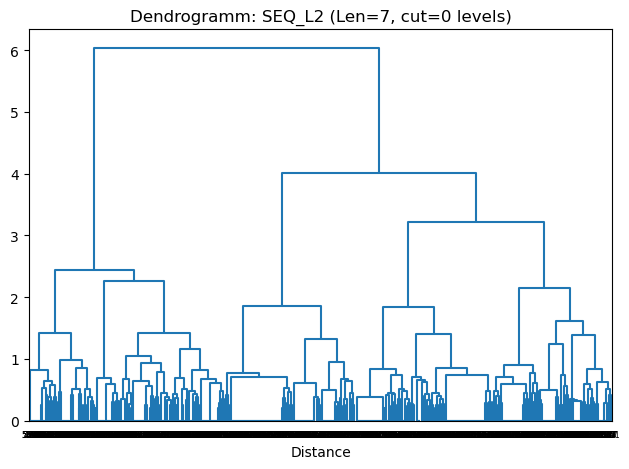


SEQ_L2, Länge 7 → 1 Subgruppen:
  Cluster 1:
    Antigen-Verteilung:
      spike glycoprotein: 211x
      spike protein s1: 179x
      hemagglutinin: 47x
      neuraminidase: 25x
      surface glycoprotein: 25x
      fusion glycoprotein f0: 17x
      gametocyte surface protein p230: 15x
      circumsporozoite protein: 12x
      envelope glycoprotein e2: 12x
      clade a/e 93th057 hiv-1 gp120 core: 11x
      programmed cell death protein 1: 11x
      spike glycoprotein,fibritin: 9x
      envelope glycoprotein gp160: 9x
      receptor tyrosine-protein kinase erbb-2: 8x
      envelope glycoprotein b: 8x
      envelope glycoprotein gp120: 8x
      reticulocyte binding protein 2b: 7x
      interleukin-17a: 7x
      ch848.10.17 gp120: 7x
      leukocyte surface antigen cd47: 7x
      25 kda ookinete surface antigen: 6x
      envelope protein: 6x
      nucleoprotein: 6x
      reticulocyte-binding protein homolog 5: 6x
      epidermal growth factor receptor: 6x
      cytotoxic t-lymphocyte p

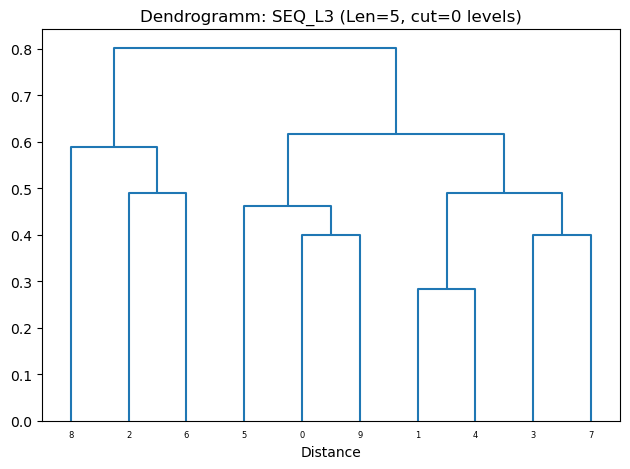


SEQ_L3, Länge 5 → 1 Subgruppen:
  Cluster 1:
    Antigen-Verteilung:
      clade a/e 93th057 hiv-1 gp120 core: 2x
      envelope glycoprotein gp160: 2x
      spike glycoprotein: 2x
      envelope glycoprotein gp120: 1x
      glycoprotein 120: 1x
      spike protein s1: 1x
      hemagglutinin: 1x
    PDB_IDs:
      4jb9
      7ugq
      4ydi
      7rdw
      9cci
      4j6r
      8qh0
      6e4x
      7s6j
      5te6
    Sequenzen:
      QQFEF
      SAFEY
      QVIES
      QHMYT
      QQYDA
      QQYET
      QQGVT
      QQQGT
      QQPLT
      QVLQF

--------------------------------------------------

✅ TSV geschrieben: cdr_cluster_pre_decided_HC_length_tsvs/clusters_SEQ_L3_len8.tsv


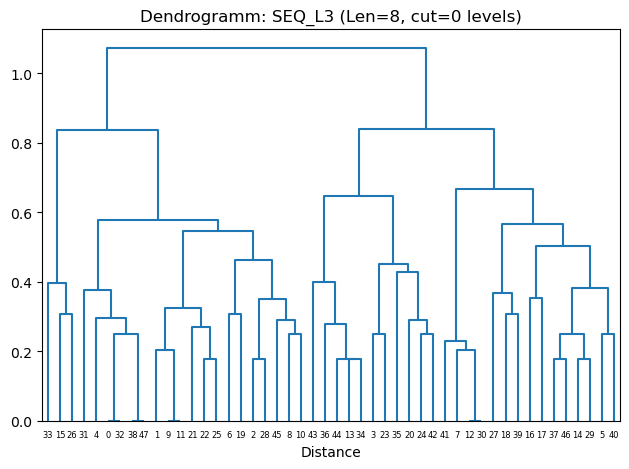


SEQ_L3, Länge 8 → 1 Subgruppen:
  Cluster 1:
    Antigen-Verteilung:
      spike protein s1: 14x
      spike glycoprotein: 10x
      envelope glycoprotein gp160: 3x
      hemagglutinin: 3x
      clade a/e 93th057 hiv-1 gp120 core: 3x
      envelope glycoprotein e2: 2x
      spike protein: 2x
      circumsporozoite protein: 2x
      fusion glycoprotein f0: 1x
      hemagglutinin ha1: 1x
      surface glycoprotein: 1x
      envelope glycoprotein e: 1x
      spike protein s2': 1x
      reticulocyte-binding protein homolog 5: 1x
      tumor necrosis factor receptor superfamily member 5: 1x
      25 kda ookinete surface antigen: 1x
      programmed cell death 1 ligand 1: 1x
    PDB_IDs:
      5t3z
      8eay
      5w08
      7ljr
      8tzy
      9l6c
      6uyg
      7ps1
      7n62
      8v5q
      8suo
      8ekd
      8bbo
      7ul1
      7jmo
      8pwv
      7y6l
      8wyj
      7nx7
      5w42
      8x0y
      8yx1
      6oej
      6phc
      6c6z
      8bg1
      6iuv
      8wyj


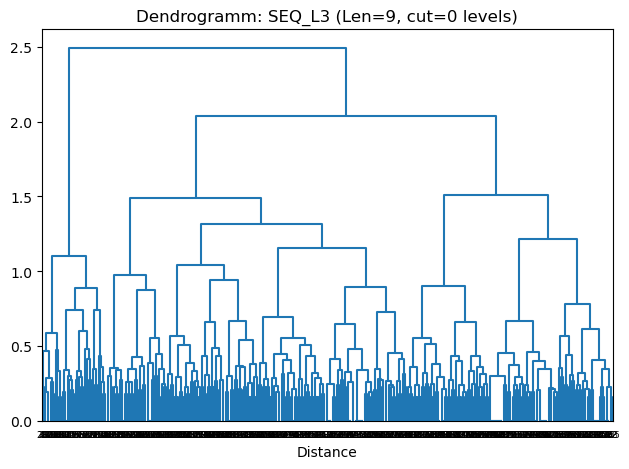


SEQ_L3, Länge 9 → 1 Subgruppen:
  Cluster 1:
    Antigen-Verteilung:
      spike glycoprotein: 122x
      spike protein s1: 85x
      hemagglutinin: 33x
      programmed cell death protein 1: 11x
      surface glycoprotein: 11x
      envelope glycoprotein e2: 10x
      fusion glycoprotein f0: 10x
      neuraminidase: 8x
      gametocyte surface protein p230: 7x
      circumsporozoite protein: 6x
      cytotoxic t-lymphocyte protein 4: 6x
      leukocyte surface antigen cd47: 6x
      receptor tyrosine-protein kinase erbb-2: 6x
      interleukin-17a: 6x
      envelope glycoprotein b: 5x
      spike glycoprotein,fibritin: 5x
      epidermal growth factor receptor: 5x
      spike protein s2': 5x
      genome polyprotein: 4x
      e2 glycoprotein: 4x
      nucleoprotein: 4x
      envelope glycoprotein h: 4x
      vascular endothelial growth factor a: 4x
      histone chaperone asf1: 4x
      reticulocyte-binding protein homolog 5: 4x
      tumor necrosis factor receptor superfamily member

FileNotFoundError: [Errno 2] No such file or directory: 'cdr_cluster_pre_decided_HC_length_tsvs/clusters_SEQ_L3_len10.tsv'

In [46]:
import csv
# Ausgabe-Ordner erstellen
os.makedirs("cdr_cluster_pre_decided_HC_length_tsvs", exist_ok=True)
# Anzahl Cluster pro (Region, Länge) aus SubDab
cluster_counts = {
    ("SEQ_H1", 7): 4, ("SEQ_H1", 8): 2, ("SEQ_H1", 9): 1,
    ("SEQ_H2", 5): 1, ("SEQ_H2", 6): 5, ("SEQ_H2", 8): 1,
    ("SEQ_L1",10): 1, ("SEQ_L1",11): 2, ("SEQ_L1",12): 2,
    ("SEQ_L1",13): 3, ("SEQ_L1",14): 3, ("SEQ_L1",15): 1,
    ("SEQ_L1",16): 1, ("SEQ_L1",17): 1,
    ("SEQ_L2", 7): 1,
    ("SEQ_L3", 5): 1, ("SEQ_L3", 8): 1, ("SEQ_L3", 9): 1,
    ("SEQ_L3",10): 2, ("SEQ_L3",11): 1,
}
for region in regions:
    lengths = sorted(df[region].str.len().dropna().unique())
    for L in lengths:
# Parameter für Dendrogramm-Cut
        levels_down = cluster_counts.get((region, L), 1)-1  # Anzahl der Ebenen für den Cut; etwa 2 = 3 Teilbäume
        print(levels_down)
# Liste der 20 Standard-Aminosäuren
        AA_LIST = list("ACDEFGHIKLMNPQRSTVWY")

        def aa_freq_vector(seq: str) -> np.ndarray:
            """Berechnet den normierten Häufigkeitsvektor der 20 Standard-Aminosäuren."""
            counts = np.array([seq.count(aa) for aa in AA_LIST], dtype=float)
            return counts / len(seq)


        # Hauptschleife: je Region und je Sequenzlänge separate Subgruppen

        for region in regions:
            # Ermittle alle eindeutigen Sequenzlängen in dieser Region
            lengths = sorted(df[region].str.len().dropna().unique())

            for L in lengths:
                # Subset für die aktuelle Länge
                sub_df = df[df[region].str.len() == L].reset_index(drop=True)
                seqs = sub_df[region].tolist()
                X = np.vstack([aa_freq_vector(s) for s in seqs])

                # Hierarchisches Clustering
                Z = linkage(X, method="ward", metric="euclidean")
                threshold = Z[-levels_down, 2] if levels_down <= Z.shape[0] else 0.0

                # Dendrogrammdaten ohne Plot für Farbzuordnung
                ddata = dendrogram(
                    Z,
                    labels=[str(i) for i in range(len(seqs))],
                    color_threshold=threshold,
                    no_plot=True
                )

                # Blatt-Farben extrahieren
                leaves = ddata['leaves']
                leaf_colors = ddata['leaves_color_list']
                leaf_color_map = dict(zip(leaves, leaf_colors))

                # Eindeutige Farben in Erscheinungsreihenfolge sammeln
                unique_colors = []
                for col in leaf_colors:
                    if col not in unique_colors:
                        unique_colors.append(col)
                color_cluster_map = {col: idx+1 for idx, col in enumerate(unique_colors)}

                # TSV-Einträge sammeln
                entries = []
                for col in unique_colors:
                    cid = color_cluster_map[col]
                    leaves_in_cluster = [leaf for leaf, c in leaf_color_map.items() if c == col]
                    for leaf_idx in leaves_in_cluster:
                        pdb_id = sub_df.iloc[leaf_idx]['PDB_ID']
                        entries.append((pdb_id, region, L, cid))

                # Schreibe TSV für Region und Länge
                tsv_file = f"cdr_cluster_pre_decided_HC_length_tsvs/clusters_{region}_len{L}.tsv"
                with open(tsv_file, 'w', newline='') as f:
                    writer = csv.writer(f, delimiter='\t')
                    writer.writerow(["PDB_ID", "CDR", "Length", "Cluster_Label"])
                    writer.writerows(entries)
                print(f"✅ TSV geschrieben: {tsv_file}")

                # Plot Dendrogramm        plt.figure(figsize=(8, 6))
                dendrogram(
                    Z,
                    labels=[str(i) for i in range(len(seqs))],
                    color_threshold=threshold,
                    leaf_rotation=0,
                    leaf_font_size=6
                )
                plt.title(f"Dendrogramm: {region} (Len={L}, cut={levels_down} levels)")
                plt.xlabel("Distance")
                plt.tight_layout()
                plt.show()

                # Konsolenausgabe der Cluster-Inhalte
                print(f"\n{region}, Länge {L} → {len(unique_colors)} Subgruppen:")
                for col in unique_colors:
                    cid = color_cluster_map[col]
                    leaves_in_cluster = [leaf for leaf, c in leaf_color_map.items() if c == col]
                    antigens = sub_df.loc[leaves_in_cluster, 'antigen_name']
                    pdbs = sub_df.loc[leaves_in_cluster, 'PDB_ID']
                    seq_list = sub_df.loc[leaves_in_cluster, region]

                    counts = Counter(antigens)
                    print(f"  Cluster {cid}:")
                    print("    Antigen-Verteilung:")
                    for ag, cnt in counts.most_common():
                        print(f"      {ag}: {cnt}x")
                    print("    PDB_IDs:")
                    for p in pdbs:
                        print(f"      {p}")
                    print("    Sequenzen:")
                    for s in seq_list:
                        print(f"      {s}")
                print("\n" + "-"*50 + "\n")

✅ TSV geschrieben: cdr_cluster_HC_pre_defined_length_tsvs/clusters_SEQ_H1_len7.tsv

SEQ_H1 Länge 7: 1 Cluster → {1: 700}


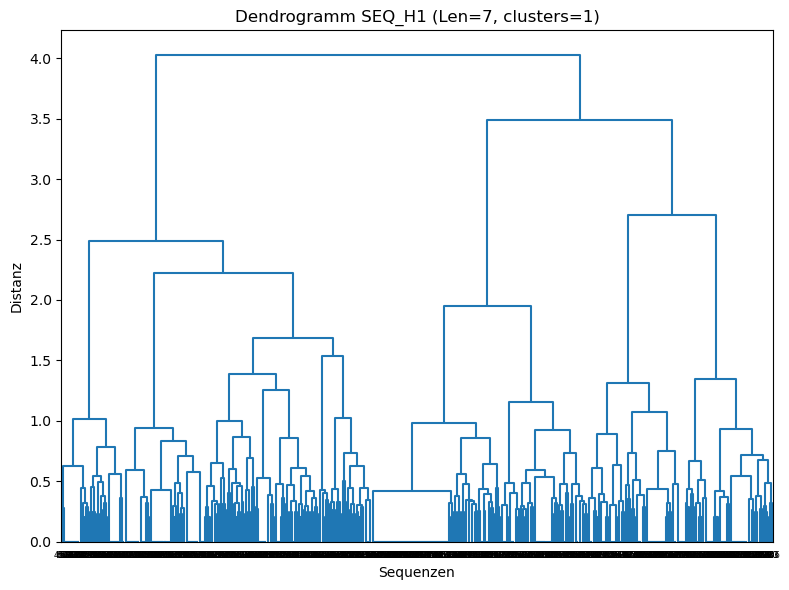

✅ TSV geschrieben: cdr_cluster_HC_pre_defined_length_tsvs/clusters_SEQ_H1_len8.tsv

SEQ_H1 Länge 8: 1 Cluster → {1: 16}


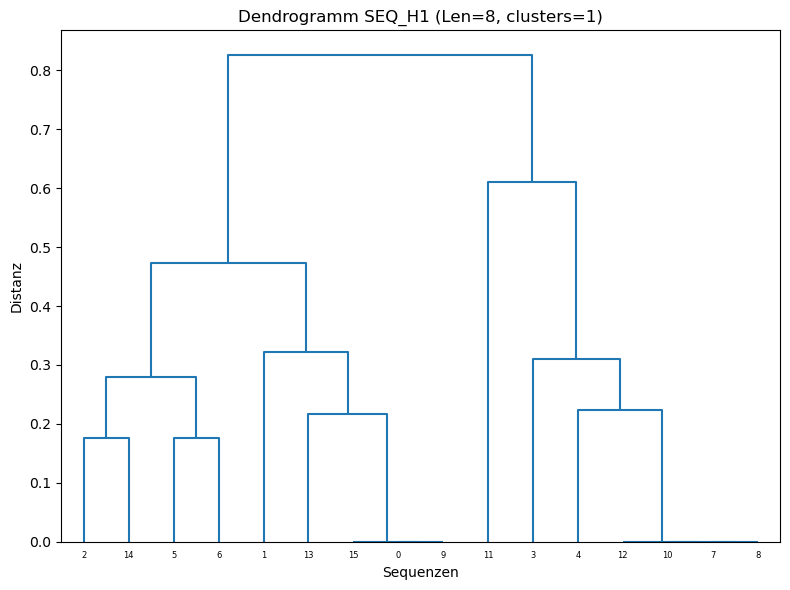

✅ TSV geschrieben: cdr_cluster_HC_pre_defined_length_tsvs/clusters_SEQ_H1_len9.tsv

SEQ_H1 Länge 9: 1 Cluster → {1: 61}


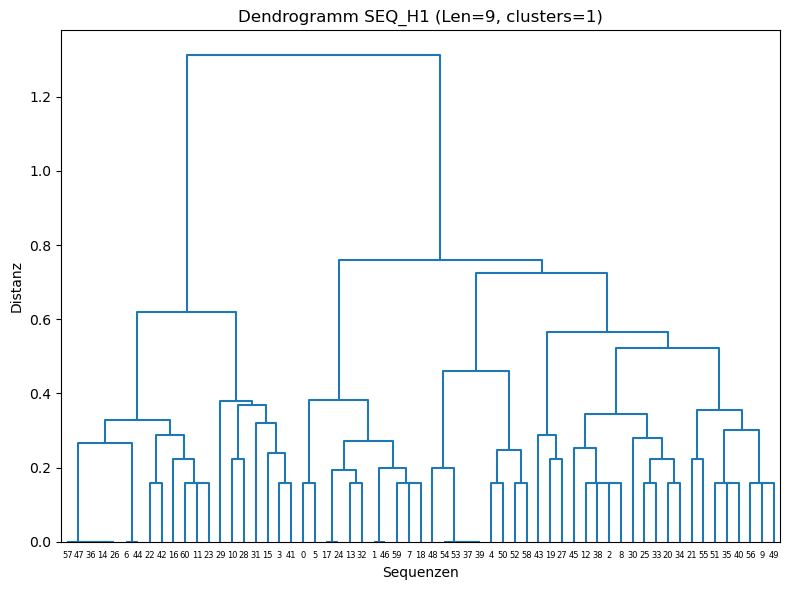

✅ TSV geschrieben: cdr_cluster_HC_pre_defined_length_tsvs/clusters_SEQ_H2_len5.tsv

SEQ_H2 Länge 5: 1 Cluster → {1: 222}


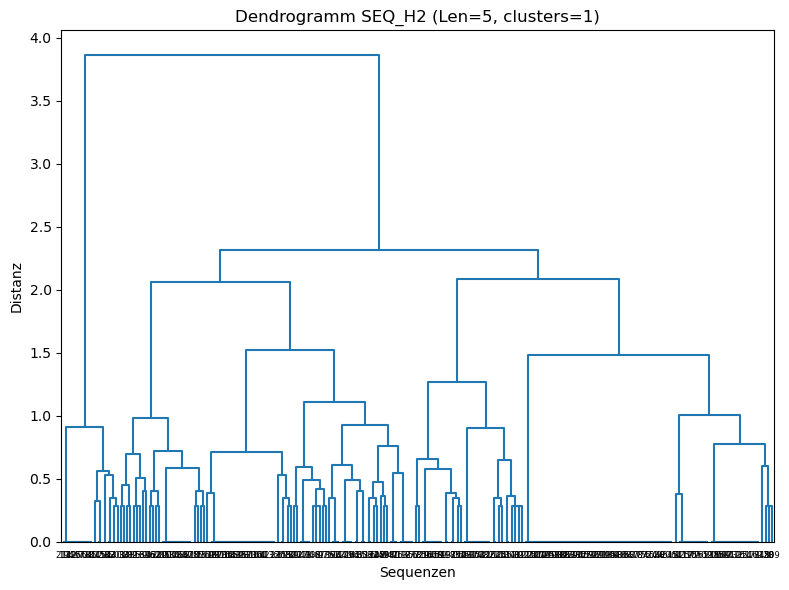

✅ TSV geschrieben: cdr_cluster_HC_pre_defined_length_tsvs/clusters_SEQ_H2_len6.tsv

SEQ_H2 Länge 6: 1 Cluster → {1: 540}


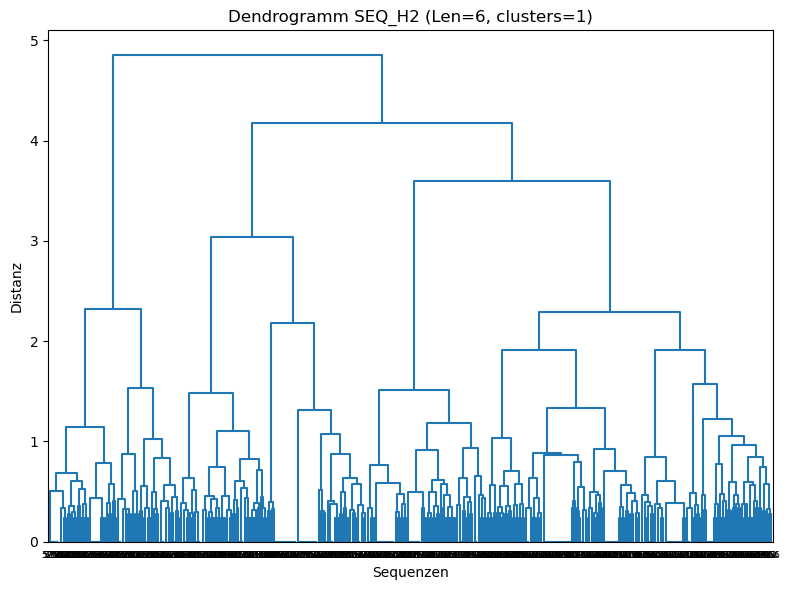

✅ TSV geschrieben: cdr_cluster_HC_pre_defined_length_tsvs/clusters_SEQ_H2_len8.tsv

SEQ_H2 Länge 8: 1 Cluster → {1: 15}


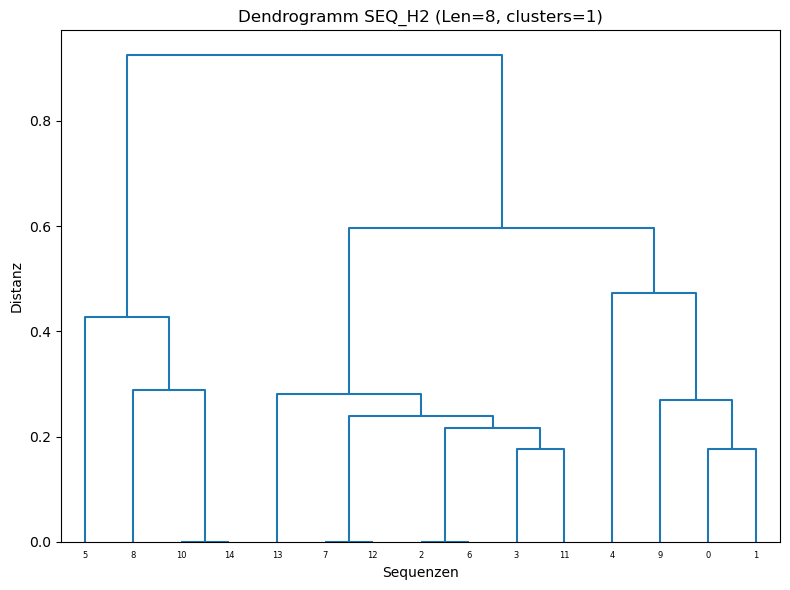

✅ TSV geschrieben: cdr_cluster_HC_pre_defined_length_tsvs/clusters_SEQ_L1_len10.tsv

SEQ_L1 Länge 10: 1 Cluster → {1: 2}


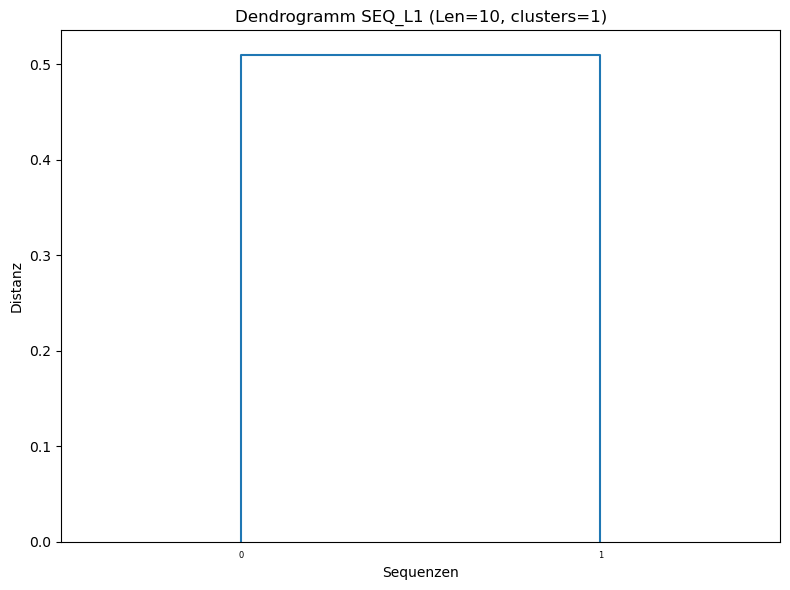

✅ TSV geschrieben: cdr_cluster_HC_pre_defined_length_tsvs/clusters_SEQ_L1_len11.tsv

SEQ_L1 Länge 11: 1 Cluster → {1: 413}


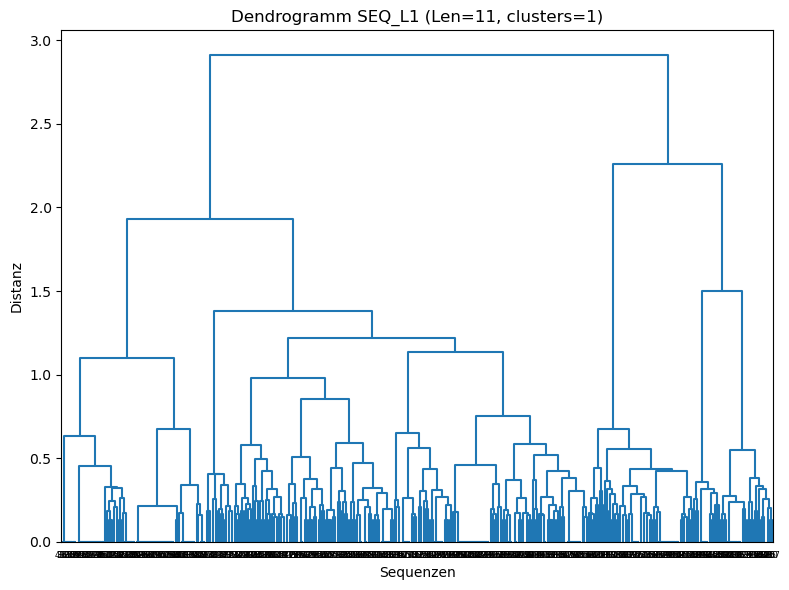

✅ TSV geschrieben: cdr_cluster_HC_pre_defined_length_tsvs/clusters_SEQ_L1_len12.tsv

SEQ_L1 Länge 12: 1 Cluster → {1: 107}


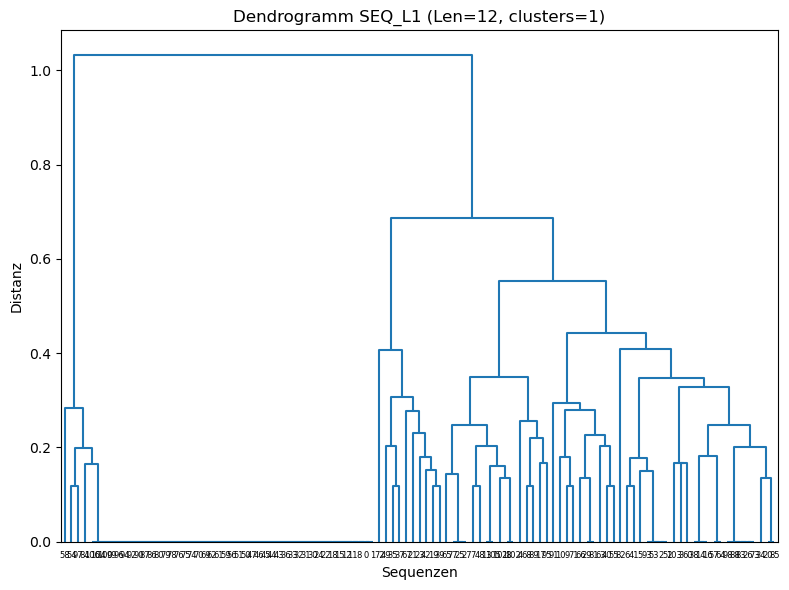

✅ TSV geschrieben: cdr_cluster_HC_pre_defined_length_tsvs/clusters_SEQ_L1_len13.tsv

SEQ_L1 Länge 13: 1 Cluster → {1: 63}


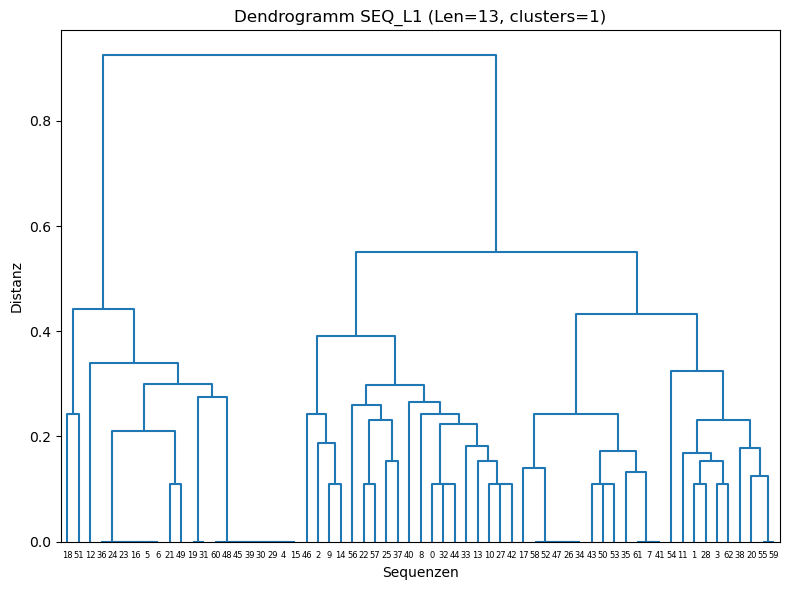

✅ TSV geschrieben: cdr_cluster_HC_pre_defined_length_tsvs/clusters_SEQ_L1_len14.tsv

SEQ_L1 Länge 14: 1 Cluster → {1: 119}


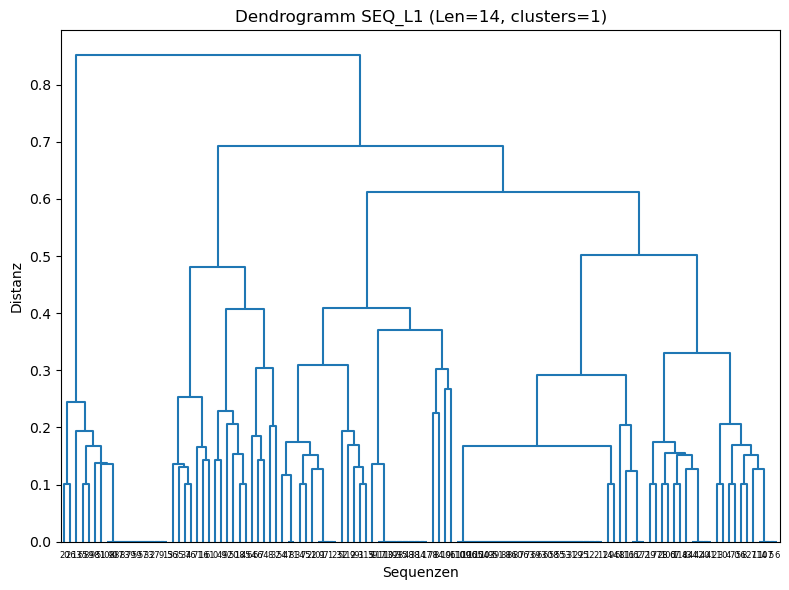

✅ TSV geschrieben: cdr_cluster_HC_pre_defined_length_tsvs/clusters_SEQ_L1_len15.tsv

SEQ_L1 Länge 15: 1 Cluster → {1: 9}


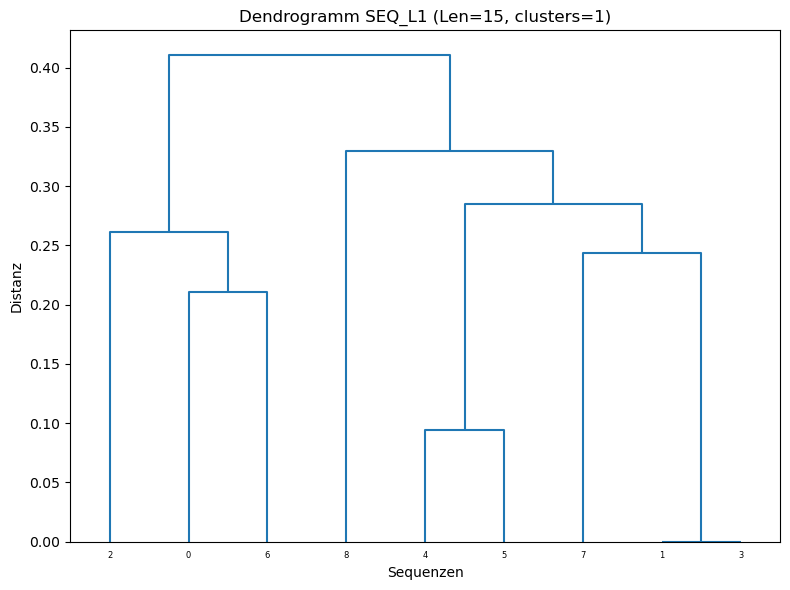

✅ TSV geschrieben: cdr_cluster_HC_pre_defined_length_tsvs/clusters_SEQ_L1_len16.tsv

SEQ_L1 Länge 16: 1 Cluster → {1: 39}


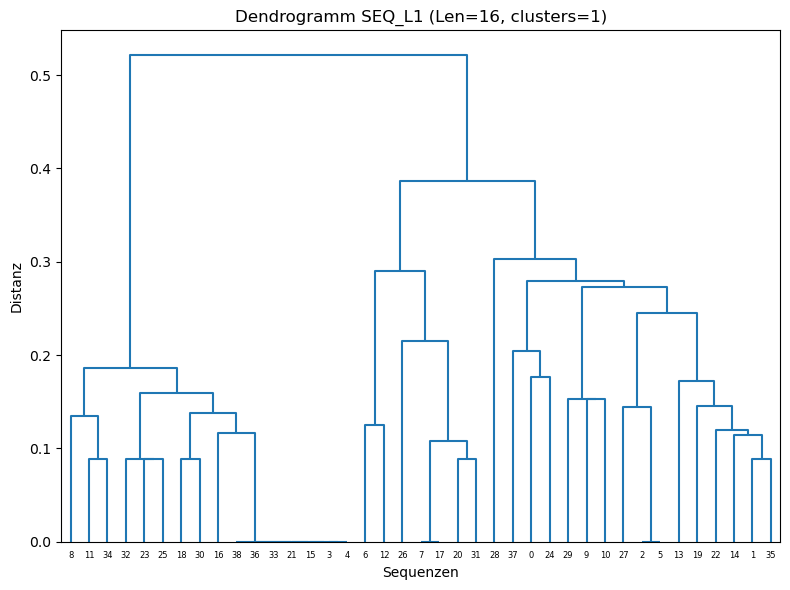

✅ TSV geschrieben: cdr_cluster_HC_pre_defined_length_tsvs/clusters_SEQ_L1_len17.tsv

SEQ_L1 Länge 17: 1 Cluster → {1: 25}


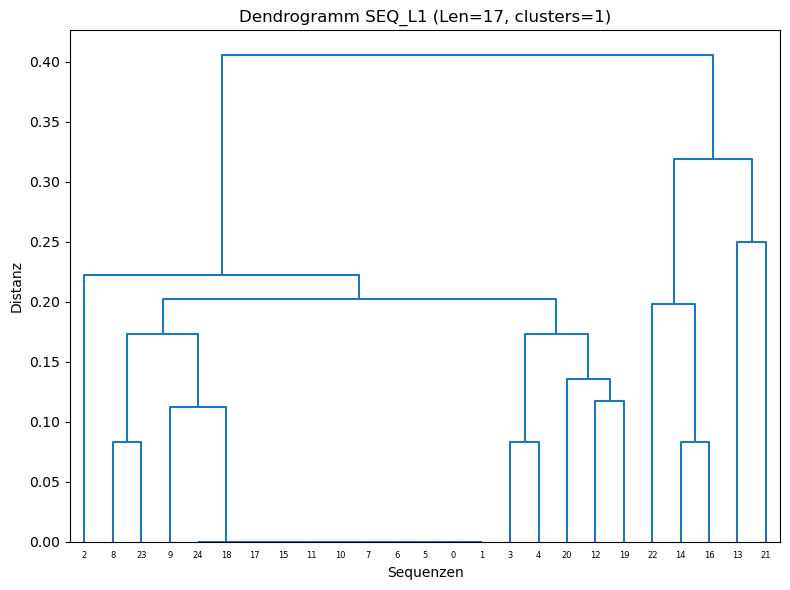

✅ TSV geschrieben: cdr_cluster_HC_pre_defined_length_tsvs/clusters_SEQ_L2_len7.tsv

SEQ_L2 Länge 7: 1 Cluster → {1: 777}


KeyboardInterrupt: 

In [32]:
import csv
import os
import numpy as np
from collections import Counter
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster
import pandas as pd
import matplotlib.pyplot as plt

# Ausgabeverzeichnis
os.makedirs("cdr_cluster_HC_pre_defined_length_tsvs", exist_ok=True)

# Parameter
AA_LIST = list("ACDEFGHIKLMNPQRSTVWY")

# Anzahl Cluster pro (Region, Länge) aus SubDab
cluster_counts = {
    ("H1", 7): 4, ("H1", 8): 2, ("H1", 9): 1,
    ("H2", 5): 1, ("H2", 6): 5, ("H2", 8): 1,
    ("L1",10): 1, ("L1",11): 2, ("L1",12): 2,
    ("L1",13): 3, ("L1",14): 3, ("L1",15): 1,
    ("L1",16): 1, ("L1",17): 1,
    ("L2", 7): 1,
    ("L3", 5): 1, ("L3", 8): 1, ("L3", 9): 1,
    ("L3",10): 2, ("L3",11): 1,
}

# Data laden
df = pd.read_csv("naiver_ansatz/ab_ag_canonical_forms.csv")
regions = ['SEQ_H1', 'SEQ_H2', 'SEQ_L1', 'SEQ_L2', 'SEQ_L3']

# Frequenzvektor
def aa_freq_vector(seq: str) -> np.ndarray:
    counts = np.array([seq.count(aa) for aa in AA_LIST], dtype=float)
    return counts / len(seq)

# Hauptloop
for region in regions:
    lengths = sorted(df[region].str.len().dropna().unique())
    for L in lengths:
        sub_df = df[df[region].str.len() == L].reset_index(drop=True)
        if sub_df.empty:
            continue
        seqs = sub_df[region].tolist()
        X = np.vstack([aa_freq_vector(s) for s in seqs])

        # Hierarchisches Clustering
        Z = linkage(X, method="ward", metric="euclidean")

        # Anzahl Cluster bestimmen
        n_clusters = cluster_counts.get((region, L), 1)

        # fcluster für gewünschte Clusterzahl
        cluster_labels = fcluster(Z, n_clusters, criterion='maxclust')

        # Dendrogramm für Farben
        plt.figure(figsize=(8, 6))
        ddata = dendrogram(
            Z,
            labels=[str(i) for i in range(len(seqs))],
            color_threshold=0,
            no_plot=True
        )

        # Blätter & Farben
        leaves = ddata['leaves']
        leaf_colors = ddata['leaves_color_list']
        leaf_color_map = dict(zip(leaves, leaf_colors))

        # Farben zu Cluster mapping
        unique_colors = []
        for col in leaf_colors:
            if col not in unique_colors:
                unique_colors.append(col)
        color_cluster_map = {col: idx+1 for idx, col in enumerate(unique_colors)}

        # Ergebnisse sammeln
        entries = []
        for idx, cid in enumerate(cluster_labels):
            pdb_id = sub_df.iloc[idx]["PDB_ID"]
            color_cluster_id = color_cluster_map.get(leaf_color_map.get(idx), cid)
            entries.append((pdb_id, region, L, color_cluster_id))

        # In TSV schreiben
        tsv_file = f"cdr_cluster_HC_pre_defined_length_tsvs/clusters_{region}_len{L}.tsv"
        with open(tsv_file, 'w', newline='') as f:
            writer = csv.writer(f, delimiter='\t')
            writer.writerow(["PDB_ID", "CDR", "Length", "Cluster_Label"])
            writer.writerows(entries)
        print(f"✅ TSV geschrieben: {tsv_file}")

        # Konsolenausgabe
        counts = Counter([cid for _, _, _, cid in entries])
        print(f"\n{region} Länge {L}: {len(counts)} Cluster → {dict(counts)}")

        # Optional Plot
        plt.title(f"Dendrogramm {region} (Len={L}, clusters={n_clusters})")
        plt.xlabel("Sequenzen")
        plt.ylabel("Distanz")
        dendrogram(
            Z,
            labels=[str(i) for i in range(len(seqs))],
            color_threshold=0,
            leaf_rotation=0,
            leaf_font_size=6
        )
        plt.tight_layout()
        plt.show()

print("🎉 Fertig! Alle Cluster mit Anzahl aus SubDab rekonstruiert und gespeichert.")
